# Paper Plots

## Imports

In [27]:
import time
_notebook_start = time.time()

import numpy as np
import emcee

import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, ListedColormap, BoundaryNorm, Normalize
import matplotlib.ticker as ticker
from matplotlib.ticker import LogFormatterSciNotation, FormatStrFormatter
from mpl_toolkits.axes_grid1 import ImageGrid

from matplotlib.lines import Line2D
from matplotlib.cm import ScalarMappable
import corner

from astropy import units as u
from astropy import constants
from astropy.units import Quantity

import scipy
from scipy import signal
from scipy.fft import fft, fftshift

import sys

import cmcrameri.cm as cmc
import corner
from tqdm import tqdm

import hera_sim
from pyuvdata import UVData
from uvtools.dspec import gen_window
from uvtools.plot import waterfall
from uvtools.utils import FFT, fourier_freqs
from plotting_functions import plot_waterfalls, plot_waterfalls_from_dlfr
from plotting_codes.functions import covariance_from_pspec, fourier_operator, data_dly_fr

sys.path.append('../hydra-pspec-systematic/')
from hydra_pspec.sys_solver import sys_modes
from hydra_pspec.utils import form_pseudo_stokes_vis

## Configuration

Set all user-facing parameters here.

In [34]:
# ── Paths ─────────────────────────────────────────────────────────────────────
result_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/paper_plots/sim_data/'  # results for all cases
parent_dir  = '/nvme2/scratch/sohini/hydra-pspec-systematic/'                        # repo root
fig_dir     = '/nvme2/scratch/sohini/Systematics-in-hydra-pspec/Figures'             # output directory

# ── Test cases ────────────────────────────────────────────────────────────────
run_version_arr = ['low_dl_fr_0', 'high_dl_fr_0', 'low_dl_fr_20', ]  # sub-folder names under result_dir

nm_list_arr = [
    [(3, 0),  (4, 0),  (5, 0),  (6, 0)],   # Case I
    [(10, 0), (11, 0), (12, 0), (13, 0)],  # Case II
    [(3, 20), (4, 20), (5, 20), (6, 20)],  # Case III
]

dl_inds = [[3, 4, 5, 6], [10, 11, 12, 13], [3, 3, 3, 3]]  # delay indices per case (for DPS plots)

# ── Single-case selection (for Figures 5, 6, 7, 8, 9) ────────────────────────
case_idx = 2  # 0 = Case I, 1 = Case II, 2 = Case III

# --------- Case labels (for legends) ---------
case_labels = ['Case I', 'Case II', 'Case III']

# ── Data dimensions ───────────────────────────────────────────────────────────
Ntimes   = 80   # number of LST samples
Nfreqs   = 60   # number of frequency channels
Nfgmodes = 10   # number of foreground modes

# ── Run parameters ────────────────────────────────────────────────────────────
Niter         = 100000  # number of Gibbs iterations
conf_interval = 95      # confidence interval for DPS plots (%)
Nburn         = 10      # burn-in (%)

# ── True systematic amplitudes ────────────────────────────────────────────────
sys_amps_true = np.array([1. + 4j, 2 + 3j, 3. + 2j, 4. + 1j])

# ── Noise ─────────────────────────────────────────────────────────────────────
noise_ps_val = 0.0004  # noise power spectrum rms

## Derived parameters

In [35]:
# freqs = np.linspace(100., 120., 120)[:Nfreqs]  # MHz
# lsts  = np.linspace(0., 1., Ntimes)            # hours

freqs = np.load(parent_dir+'res/npy_data/freqs_full.npy')[:Nfreqs] * 1e-6
lsts = np.load(parent_dir+'res/npy_data/lsts_full.npy')[:Ntimes]

df     = (freqs[1] - freqs[0]) * u.MHz
delays = np.fft.fftshift(np.fft.fftfreq(Nfreqs, d=df.to('1/ns')))  # ns

fourier_op    = fourier_operator(freqs.size, unitary=True)
noise_ps_true = noise_ps_val * np.ones(Nfreqs)
N_true = covariance_from_pspec(noise_ps_true, fourier_op)
Ninv   = np.diag(1. / np.diag(N_true))
n      = np.sqrt(N_true) @ (np.random.randn(freqs.size, Ntimes)
                            + 1.j * np.random.randn(freqs.size, Ntimes)) / np.sqrt(2.)

# ── Convenience helpers (defined once, reused throughout) ────────────────────
lsts_sec  = lsts * 24. / (2. * np.pi) * 3600.                               # LST → seconds
dlfr      = lambda x: data_dly_fr(x, freqs * 1e6, lsts, windows='blackman-harris')
dlfr_ones = dlfr(np.ones((Ntimes, Nfreqs), dtype='complex'))                 # DLFR(1); linearity: DLFR(1+x) = dlfr_ones + DLFR(x)

# Systematics operator for the selected case
sys_modes_operator = sys_modes(
    freqs_Hz   = freqs * 1e6,
    times_sec  = lsts_sec,
    modes      = nm_list_arr[case_idx],
)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
times_jd = np.unique(uvd.time_array)   # shape (Ntimes,), Julian Date

3 20
4 20
5 20
6 20


## Helper functions

In [36]:
def calc_ps(s):
    """Delay power spectrum. Uses inverse FFT for correct normalisation."""
    axes = (1,)
    sk = np.fft.ifftshift(s, axes=axes)
    sk = np.fft.fftn(sk, axes=axes)
    sk = np.fft.fftshift(sk, axes=axes)
    Nobs, Nfreqs_ = sk.shape
    return np.mean(sk * sk.conj(), axis=0).real / Nfreqs_


def corner_plot(
    samples, 
    labels=None, 
    truths=None, 
    burn=10, 
    thin=1, 
    fig=None,
    truths_label="Truth",
    extra_truths=None, 
    extra_color="tab:green", 
    extra_truths_label="Truth B",
    title=None, 
    legend_loc="best",
    nsigma=3,
    color = "C0",
    case_label = None,
):
    S = samples[burn::thin]
    ndim = S.shape[1]
    levels = [1 - np.exp(-0.5 * n**2) for n in range(1, nsigma + 1)]
    if nsigma == 3:
        quantiles = [0.00135, 0.50, 0.99865]
    elif nsigma == 2:
        quantiles = [0.02275, 0.50, 0.97725]
    elif nsigma == 1:
        quantiles = [0.15865, 0.50, 0.84135]
    else:
        raise ValueError("nsigma must be 1, 2, or 3.")
    fig = corner.corner(
        S, 
        labels=labels, 
        truths=truths,
        truth_color="tab:red",
        quantiles=[],
        levels=levels,
        fig=fig,
        show_titles=True, 
        title_fmt=".3g",
        bins=100, 
        smooth=2.0, 
        color=color,
    )
    if extra_truths is not None:
        corner.overplot_lines(fig, extra_truths, color=extra_color, linewidth=1.6)
        corner.overplot_points(fig, [extra_truths], color=extra_color, marker="s", ms=5)
    axes = np.array(fig.axes).reshape(ndim, ndim)
    ax0 = axes[0, -1]
    ax0.yaxis.set_major_formatter(FormatStrFormatter('%.2f'))
    # Get handles from any previous call
    existing_handles = []
    if ax0.get_legend() is not None:
        existing_handles = list(ax0.get_legend().legend_handles)

    # Now build new handles and combine
    new_handles = []
    if truths is not None:
        new_handles.append(Line2D([0], [0], color="tab:red", lw=1.6, label=truths_label))
    if extra_truths is not None:
        new_handles.append(Line2D([0], [0], color=extra_color, lw=1.6, label=extra_truths_label))
    if case_label is not None:
        new_handles.append(Line2D([0], [0], color=color, lw=1.6, label=case_label))

    all_handles = existing_handles + new_handles
    if all_handles:
        ax0.legend(handles=all_handles, loc=legend_loc, frameon=False)
    
    # Set the super-title and adjust layout
    if title:
        fig.suptitle(title, y=0.98)
        fig.tight_layout(rect=(0, 0, 1, 0.96))
    else:
        fig.tight_layout()
    return fig


def plot_crosscor_pearson(data1, data2):
    d1 = data1.reshape(data1.shape[0], -1)
    d2 = data2.reshape(data2.shape[0], -1)
    d1 = d1 - d1.mean(axis=0)
    d2 = d2 - d2.mean(axis=0)
    numerator   = np.sum(d1 * d2, axis=0)
    denominator = np.sqrt(np.sum(d1**2, axis=0) * np.sum(d2**2, axis=0))
    return (numerator / denominator).reshape(data1.shape[1:])

def cov_to_corr(cov):
    """
    Convert a covariance matrix to a correlation matrix.

    Parameters
    ----------
    cov : np.ndarray, shape (N, N)
        Covariance matrix, e.g. from np.cov().

    Returns
    -------
    corr : np.ndarray, shape (N, N)
        Correlation matrix with entries corr[i,j] = cov[i,j] / (sigma[i] * sigma[j]).
    """
    sigma = np.sqrt(np.diag(cov))           # (N,) standard deviations
    corr = cov / np.outer(sigma, sigma)     # broadcast: corr[i,j] = cov[i,j] / (sigma[i]*sigma[j])
    return corr

## Plot specifications

In [37]:
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family']      = 'STIXGeneral'
plt.rcParams.update({'font.size': 34})

paper_map = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.012, 0.114, 0.267)),
    (0.250, (0.553, 0.663, 0.769)),
    (0.500, (0.933, 0.957, 0.929)),
    (0.750, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_pink = LinearSegmentedColormap.from_list('my_gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.737, 0.486, 0.584)),
    (1.000, (0.537, 0.016, 0.239))))

paper_map_blue = LinearSegmentedColormap.from_list('my gradient', (
    (0.000, (0.933, 0.957, 0.929)),
    (0.500, (0.553, 0.663, 0.769)),
    (1.000, (0.012, 0.114, 0.267))))

colors = ['#1d3557', '#ca6702', '#81babc', '#e63946', "#ff8fba"]
dynamic_range = 5
bbox     = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.5)
bbox_res = dict(boxstyle='round', fc='blanchedalmond', ec='orange', alpha=0.8)

# --- Axis dimensions ---
# x-axis: frequency / delay     (Nfreqs = 120 pixels)
# y-axis: time / fringe-rate    (Ntimes = 203 pixels)

freqs_mhz    = freqs * u.MHz
lsts_hours   = lsts * 12 / np.pi                                  # (203,) hours
fringe_rates = fourier_freqs(times_jd[:Ntimes] * u.day.to('s')) * 1e3          # (203,) mHz
delays_ns    = delays.value                                        # (120,) ns

# --- Delay ticks: find pixel indices nearest to target delays ---
target_delays_ns = [-2800, -1200, 0, 1200, 2800]
xticklocs_dl     = [np.argmin(np.abs(delays_ns - t)) for t in target_delays_ns]
xticks_dl       = delays[xticklocs_dl]
xticklabels_dl   = [str(int(t)) for t in target_delays_ns]

# --- Fringe-rate ticks: evenly spaced across y-axis (203 pixels) ---
target_fr_mHz = [-10, -5, 0, 5, 10]
yticklocs_fr     = [np.argmin(np.abs(fringe_rates - t)) for t in target_fr_mHz]
yticks_fr       = fringe_rates[yticklocs_fr]
yticklabels_fr  = [f'{val:.2f}' for val in yticks_fr]

# --- Frequency ticks: whole number MHz values ---
target_freqs_mhz = np.arange(
    int(np.ceil(freqs_mhz[0].value)),
    int(np.floor(freqs_mhz[-1].value)) + 1,
    step=4,                                                        # every 4 MHz
)
xticklocs_freq    = [np.argmin(np.abs(freqs_mhz.value - f)) for f in target_freqs_mhz]
xticks_freqs      = freqs_mhz[xticklocs_freq]
xticklabels_freqs = [str(int(round(f.value))) for f in xticks_freqs]

# --- LST ticks: evenly spaced across y-axis (203 pixels) ---
yticklocs_time    = np.linspace(0, len(lsts_hours) - 1, 7, dtype=int)
yticks_times      = Quantity(lsts_hours[yticklocs_time], unit='h')
yticklabels_times = [f'{val.value:.2f}' for val in yticks_times]


In [38]:
uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_eor = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_eor = np.unique(uvd.lst_array)

uvd = UVData()
uvd.read(parent_dir + 'res/test_data/vis-eor-ptsrc-gsm.uvh5')
uvd = form_pseudo_stokes_vis(uvd)
vis_sky = uvd.get_data(uvd.get_antpairpols()[0], force_copy=True)
lst_sky = np.unique(uvd.lst_array)

eor_true = np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs]
fg_true  = np.load(parent_dir + 'res/npy_data/fg_true.npy')[:Ntimes, :Nfreqs]
data_true_full      = eor_true + fg_true
data_true_dlfr_full = dlfr(data_true_full)

---
# Single-case analysis (case_idx = `case_idx`)

The cells below load and process data for the single case selected by `case_idx`.

In [39]:
run_version = run_version_arr[case_idx]

fg_true        = np.load(result_dir + run_version + '/fg_true.npy')[:Ntimes, :Nfreqs]
fgmodes        = np.load(result_dir + run_version + '/fgmodes.npy')
fg_amps_gcr    = np.load(result_dir + run_version + '/fg-amps.npy')
eor_true       = np.load(result_dir + run_version + '/eor_true.npy')[:Ntimes, :Nfreqs]
eor_gcr        = np.load(result_dir + run_version + '/gcr-eor.npy')
ps_sample      = np.load(result_dir + run_version + '/dps-eor.npy')
ln_post        = np.load(result_dir + run_version + '/ln-post.npy')
b_sys_gcr      = np.load(result_dir + run_version + '/b-sys.npy')
sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')
data_true      = np.load(result_dir + run_version + '/data_true.npy')

delta_g_true = (sys_modes_operator @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
sky_true     = eor_true + fg_true

# ── Static DLFR quantities ────────────────────────────────────────────────────
eor_true_dlfr       = dlfr(eor_true)
fg_true_dlfr        = dlfr(fg_true)
sky_true_dlfr       = dlfr(sky_true)
sys_model_true_dlfr = dlfr(sys_model_true)
delta_g_dlfr_true   = dlfr(delta_g_true)
data_true_dlfr      = dlfr(data_true)

# ── Allocate per-iteration arrays (only those needed after the loop) ──────────
ps_fg    = np.empty(ps_sample.shape)
ps_sys   = np.empty(ps_sample.shape)
ps_del_g = np.empty(ps_sample.shape)
ps_data  = np.empty(ps_sample.shape)
ps_sky  = np.empty(ps_sample.shape)

sky_dlfr_arr     = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 5 std
fg_dlfr_arr      = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 11 Pearson
delta_g_dlfr_arr = np.empty([Niter, Ntimes, Nfreqs], dtype='complex')  # Fig 6 stats + Fig 11 Pearson

# ── Single-pass Gibbs sample processing ──────────────────────────────────────
print('Processing samples (single case)...')
for i in tqdm(range(Niter)):
    fg_vis = (fgmodes @ fg_amps_gcr[i].T).T
    dg     = (sys_modes_operator @ b_sys_gcr[i]).reshape([Nfreqs, Ntimes]).T
    dg_d   = dlfr(dg)

    ps_fg[i]    = calc_ps((fgmodes[:, :Nfgmodes] @ fg_amps_gcr[i].T).T)
    ps_sky[i]  = calc_ps(eor_gcr[i] + (fgmodes[:, :Nfgmodes] @ fg_amps_gcr[i].T).T)
    ps_sys[i]   = calc_ps(1 + dg)
    ps_del_g[i] = calc_ps(dg)
    ps_data[i]  = calc_ps((1 + dg) * (eor_gcr[i] + fg_vis))

    sky_dlfr_arr[i]     = dlfr(eor_gcr[i]+fg_vis)
    fg_dlfr_arr[i]      = dlfr(fg_vis)
    delta_g_dlfr_arr[i] = dg_d

# ── Power spectrum statistics ─────────────────────────────────────────────────
eor_pspec_avg   = np.mean(ps_sample, axis=0)
fg_pspec_avg    = np.mean(ps_fg, axis=0)
sky_pspec_avg   = np.mean(ps_sky, axis=0)
sys_pspec_avg   = np.mean(ps_sys, axis=0)
data_pspec_avg  = np.mean(ps_data, axis=0)
delg_pspec_avg  = np.mean(ps_del_g, axis=0)

eor_pspec_true  = calc_ps(eor_true)
fg_pspec_true   = calc_ps(fg_true)
sys_pspec_true  = calc_ps(sys_model_true)
n_pspec         = calc_ps(n.T)
data_pspec_true = calc_ps(data_true)
b_sys_mean      = np.mean(b_sys_gcr, axis=0)

# ── DLFR statistics ───────────────────────────────────────────────────────────
delta_g_dlfr_mean   = delta_g_dlfr_arr.mean(axis=0)
delta_g_dlfr_std    = np.std(delta_g_dlfr_arr, axis=0)
sys_model_dlfr_mean = dlfr_ones + delta_g_dlfr_mean   # linearity: DLFR(1+dg) = dlfr_ones + DLFR(dg)
mean_sky_dlfr       = sky_dlfr_arr.mean(axis=0)

Processing samples (single case)...


100%|██████████| 100000/100000 [02:08<00:00, 777.80it/s]


## All-cases data (Figures 4, 5–6 v2, 11)

Computes all per-case DLFR statistics and Pearson correlation maps needed for
Figures 4, 5 v2, 6 v2, and 11.

- For `case_idx`, stored arrays from the single-case cell are reused directly.
- For the other cases, a **single merged loop** computes statistics online
  (Welford mean/variance, sum-of-products Pearson), avoiding large
  `[Niter, Ntimes, Nfreqs]` sample arrays.

In [40]:
data_true_dlfr_all    = [None] * 3
sky_true_dlfr_all     = [None] * 3
mean_sky_dlfr_all     = [None] * 3
std_sky_dlfr_all      = [None] * 3
res_sky_dlfr_all      = [None] * 3
delta_g_dlfr_true_all = [None] * 3
delta_g_dlfr_mean_all = [None] * 3
delta_g_dlfr_std_all  = [None] * 3
res_sys_dlfr_all      = [None] * 3
corr_maps             = [None] * 3   # Pearson r maps for Figure 11

for case_i, run_ver in enumerate(run_version_arr):
    print(f'\n=== Case {case_i + 1} ({run_ver}) ===')
    op_i = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[case_i])

    # ── Static (true) quantities ──────────────────────────────────────────────
    eor_true_i       = np.load(result_dir + run_ver + '/eor_true.npy')[:Ntimes, :Nfreqs]
    fg_true_i        = np.load(result_dir + run_ver + '/fg_true.npy')[:Ntimes, :Nfreqs]
    sys_model_true_i = np.load(result_dir + run_ver + '/gain_true.npy')
    # data_true_i      = np.load(result_dir + run_ver + '/data_true.npy')
    data_true_i = sys_model_true_i * (eor_true_i + fg_true_i)  # apply true gain to sky model to get noiseless data
    sky_true_i            = eor_true_i + fg_true_i
    delta_g_true_i        = (op_i @ sys_amps_true).reshape([Nfreqs, Ntimes]).T
    # sky_true_dlfr_i       = dlfr(sky_true_i)
    sky_true_dlfr_i       = dlfr(eor_true_i + fg_true_i)
    delta_g_dlfr_true_i   = dlfr(delta_g_true_i)
    sys_model_true_dlfr_i = dlfr(sys_model_true_i)
    data_true_dlfr_i      = dlfr(data_true_i)

    # if case_i == case_idx:
    #     # ── Reuse single-case results ─────────────────────────────────────────
    #     mean_sky_i     = mean_sky_dlfr
    #     std_sky_i      = np.std(sky_dlfr_arr, axis=0)
    #     mean_dg_dlfr_i = delta_g_dlfr_mean
    #     std_dg_dlfr_i  = delta_g_dlfr_std
    #     # Pearson: fg_dlfr_arr and delta_g_dlfr_arr already stored
    #     corr_maps[case_i] = plot_crosscor_pearson(
    #         fg_dlfr_arr, dlfr_ones[np.newaxis] + delta_g_dlfr_arr,
    #     )
    # else:
    # ── Load sample arrays ────────────────────────────────────────────────
    fgmodes_i = np.load(result_dir + run_ver + '/fgmodes.npy')
    fg_amps_i = np.load(result_dir + run_ver + '/fg-amps.npy')
    eor_gcr_i = np.load(result_dir + run_ver + '/gcr-eor.npy')
    b_sys_i   = np.load(result_dir + run_ver + '/b-sys.npy')

    # ── Online accumulators (no large [Niter, Ntimes, Nfreqs] arrays) ─────
    # Welford mean + variance for sky DLFR and delta_g DLFR
    n_s    = 0
    sky_mu = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sky_M2 = np.zeros((Ntimes, Nfreqs))           # sum of squared deviations (real)
    dg_mu  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    dg_M2  = np.zeros((Ntimes, Nfreqs))

    # Sum-of-products accumulators for Pearson r (fg vs sys_model)
    fg_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sm_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    fg2_s = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sm2_s = np.zeros((Ntimes, Nfreqs), dtype='complex')
    cr_s  = np.zeros((Ntimes, Nfreqs), dtype='complex')
    sky_d_arr = np.empty((Niter, Ntimes, Nfreqs), dtype='complex')  # for debugging: store sky DLFRs to verify Welford results
    dg_d_arr  = np.empty((Niter, Ntimes, Nfreqs), dtype='complex')  # for debugging: store delta_g DLFRs to verify Welford results
    print('  Computing samples...')
    for j in tqdm(range(Niter)):
        fg_vis  = (fgmodes_i @ fg_amps_i[j].T).T
        dg      = (op_i @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
        dg_d_arr[j,:,:]    = dlfr(dg)
        sky_d_arr[j,:,:]   = dlfr(eor_gcr_i[j] + fg_vis)
        fg_d    = dlfr(fg_vis)
        sm_d    = dlfr_ones + dg_d    # DLFR(1+dg) by linearity

        # # Welford update: sky
        # n_s += 1
        # sky_delta = sky_d - sky_mu
        # sky_mu   += sky_delta / n_s
        # sky_M2   += (sky_delta.real * (sky_d - sky_mu).real
        #              + sky_delta.imag * (sky_d - sky_mu).imag)

        # # Welford update: delta_g
        # dg_delta = dg_d - dg_mu
        # dg_mu   += dg_delta / n_s
        # dg_M2   += (dg_delta.real * (dg_d - dg_mu).real
        #             + dg_delta.imag * (dg_d - dg_mu).imag)

        # Pearson sums
        fg_s += fg_d;   sm_s  += sm_d
        fg2_s += fg_d**2; sm2_s += sm_d**2
        cr_s  += fg_d * sm_d

    mean_sky_i     = sky_d_arr.mean(axis=0)
    std_sky_i      = np.std(sky_d_arr, axis=0)
    mean_dg_dlfr_i = dg_d_arr.mean(axis=0)
    std_dg_dlfr_i  = np.std(dg_d_arr, axis=0)

    fg_mu_i  = fg_s / Niter;  sm_mu_i = sm_s / Niter
    corr_maps[case_i] = (cr_s - Niter * fg_mu_i * sm_mu_i) / np.sqrt(
        (fg2_s - Niter * fg_mu_i**2) * (sm2_s - Niter * sm_mu_i**2)
    )

    # ── Store per-case outputs ────────────────────────────────────────────────
    data_true_dlfr_all[case_i]    = data_true_dlfr_i
    sky_true_dlfr_all[case_i]     = sky_true_dlfr_i
    mean_sky_dlfr_all[case_i]     = mean_sky_i
    std_sky_dlfr_all[case_i]      = std_sky_i
    res_sky_dlfr_all[case_i]      = sky_true_dlfr_i - mean_sky_i
    delta_g_dlfr_true_all[case_i] = delta_g_dlfr_true_i
    delta_g_dlfr_mean_all[case_i] = mean_dg_dlfr_i
    delta_g_dlfr_std_all[case_i]  = std_dg_dlfr_i
    res_sys_dlfr_all[case_i]      = sys_model_true_dlfr_i - (dlfr_ones + mean_dg_dlfr_i)

print('\nDone.')


=== Case 1 (low_dl_fr_0) ===
3 0
4 0
5 0
6 0
  Computing samples...


100%|██████████| 100000/100000 [01:11<00:00, 1398.43it/s]



=== Case 2 (high_dl_fr_0) ===
10 0
11 0
12 0
13 0
  Computing samples...


100%|██████████| 100000/100000 [01:10<00:00, 1413.41it/s]



=== Case 3 (low_dl_fr_20) ===
3 20
4 20
5 20
6 20
  Computing samples...


100%|██████████| 100000/100000 [01:16<00:00, 1302.11it/s]



Done.


---
# Figure 1: Data componenets

In [104]:
xticklabels_dl, eor_true_dlfr.shape

(['-2800', '-1200', '0', '1200', '2800'], (80, 60))

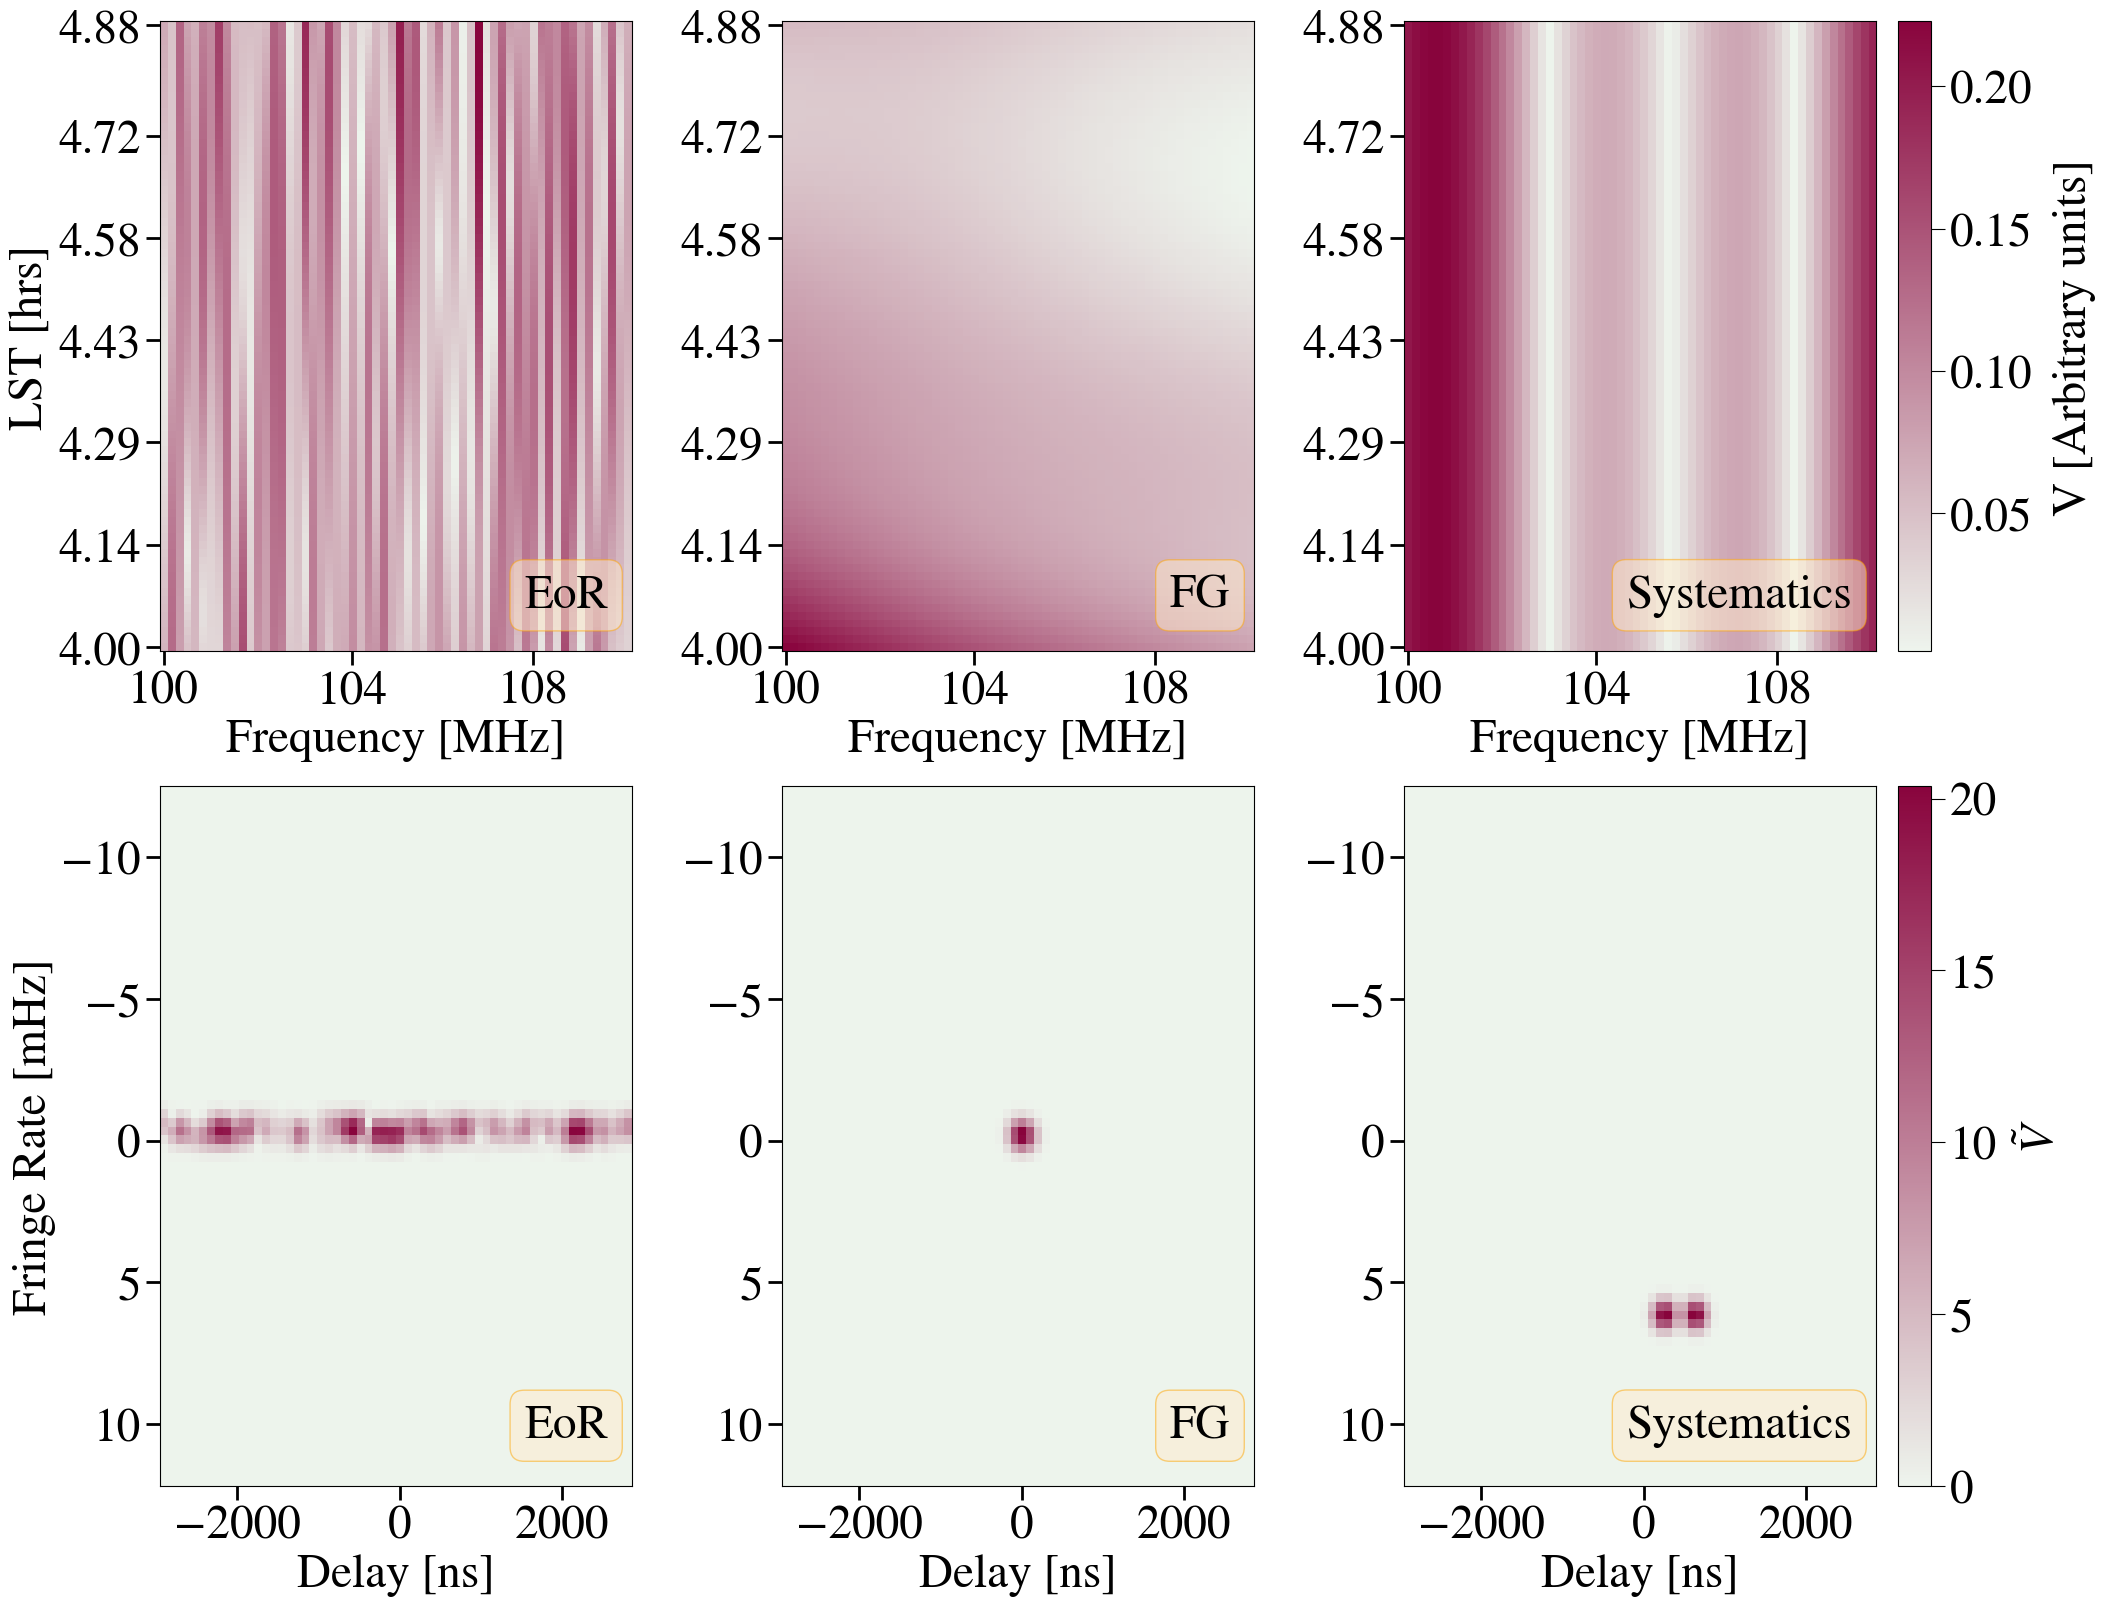

In [119]:
fig = plt.figure(figsize=(22., 25.))

grid_kwargs = dict(
    nrows_ncols   = (1, 3),
    axes_pad      = 1.5,
    cbar_mode     = None,     
    label_mode    = 'all',
    aspect        = False,
)

axs_top = ImageGrid(fig, rect=(0.06, 0.38, 0.78, 0.28), **grid_kwargs)
axs_bot = ImageGrid(fig, rect=(0.06, 0.06, 0.78, 0.28), **grid_kwargs)

# --- Plot top row ---
data_top = [eor_true.T, fg_true.T, delta_g_true.T]
for ax, data in zip(axs_top, data_top):
    im_top = ax.imshow(np.abs(data).T, cmap=paper_map_pink, origin='lower')
    ax.tick_params(direction='out', length=6, width=2, colors='black', size=10)

# --- Plot bottom row ---
data_bot = [eor_true_dlfr, fg_true_dlfr, delta_g_dlfr_true]
for ax, data in zip(axs_bot, data_bot):
    im_bot = plot_waterfalls_from_dlfr(
        data_dlfr     = data,
        freqs         = freqs[:Nfreqs] * 1e6,
        times         = times_jd[:Ntimes],
        fig           = fig,
        ax            = ax,
        colorbar_flag = False,
        cmap          = paper_map_pink,
        mode          = 'abs',
        ylab_flag = False,
    )
    ax.tick_params(direction='out', length=6, width=2, colors='black', size=10)

# --- Draw first so positions are finalised ---
fig.canvas.draw()

# --- Get the right edge of the rightmost axes in each row ---
top_right = axs_top[-1].get_position()
bot_right = axs_bot[-1].get_position()

cbar_width = 0.015

# Manual colorbar axes — left edge just right of the plot area
cax_top = fig.add_axes([top_right.x1 + 0.01, top_right.y0,
                         cbar_width, top_right.height])
cax_bot = fig.add_axes([bot_right.x1 + 0.01, bot_right.y0,
                         cbar_width, bot_right.height])

cbar_top = fig.colorbar(im_top, cax=cax_top)
cbar_top.set_label(r'V [Arbitrary units]', fontsize=34, labelpad=15)
cbar_top.ax.tick_params(which='both', color='black', labelcolor='black', size=10)

cbar_bot = fig.colorbar(im_bot, cax=cax_bot)
cbar_bot.set_label(r'$\tilde{V}$', fontsize=34, labelpad=15)
cbar_bot.ax.tick_params(which='both', color='black', labelcolor='black', size=10)

# --- Ticks top---
for ax in axs_top:
    ax.set_xticks(xticklocs_freq, labels=xticklabels_freqs)
    ax.set_yticks(yticklocs_time, labels=yticklabels_times)
    ax.set_xlabel("Frequency [MHz]")
    ax.tick_params(axis='x')
    
# --- Ticks Bottom ---
# for ax in axs_bot:
#     ax.set_xticks([2,18,30,42,58], labels=['-2800', '-1200', '0', '1200', '2800'])
#     ax.set_yticks([0,18,40,62,79], labels=['1.93', '1.09', '0.00', '-1.09', '-1.98'])
#     ax.tick_params(axis='x')

axs_top[0].set_ylabel("LST [hrs]")
axs_bot[0].set_ylabel("Fringe Rate [mHz]")


bbox_labels = ['EoR','FG','Systematics']
for ax, label in zip(axs_top, bbox_labels):
    ax.text(0.95, 0.07, label, bbox=bbox, transform=ax.transAxes, horizontalalignment='right')

for ax, label in zip(axs_bot, bbox_labels):
    ax.text(0.95, 0.07, label, bbox=bbox, transform=ax.transAxes, horizontalalignment='right')

plt.savefig(fig_dir + '/data_components.pdf', bbox_inches='tight', dpi=300)

---
# Figure 3: Test cases in delay–fringe-rate space

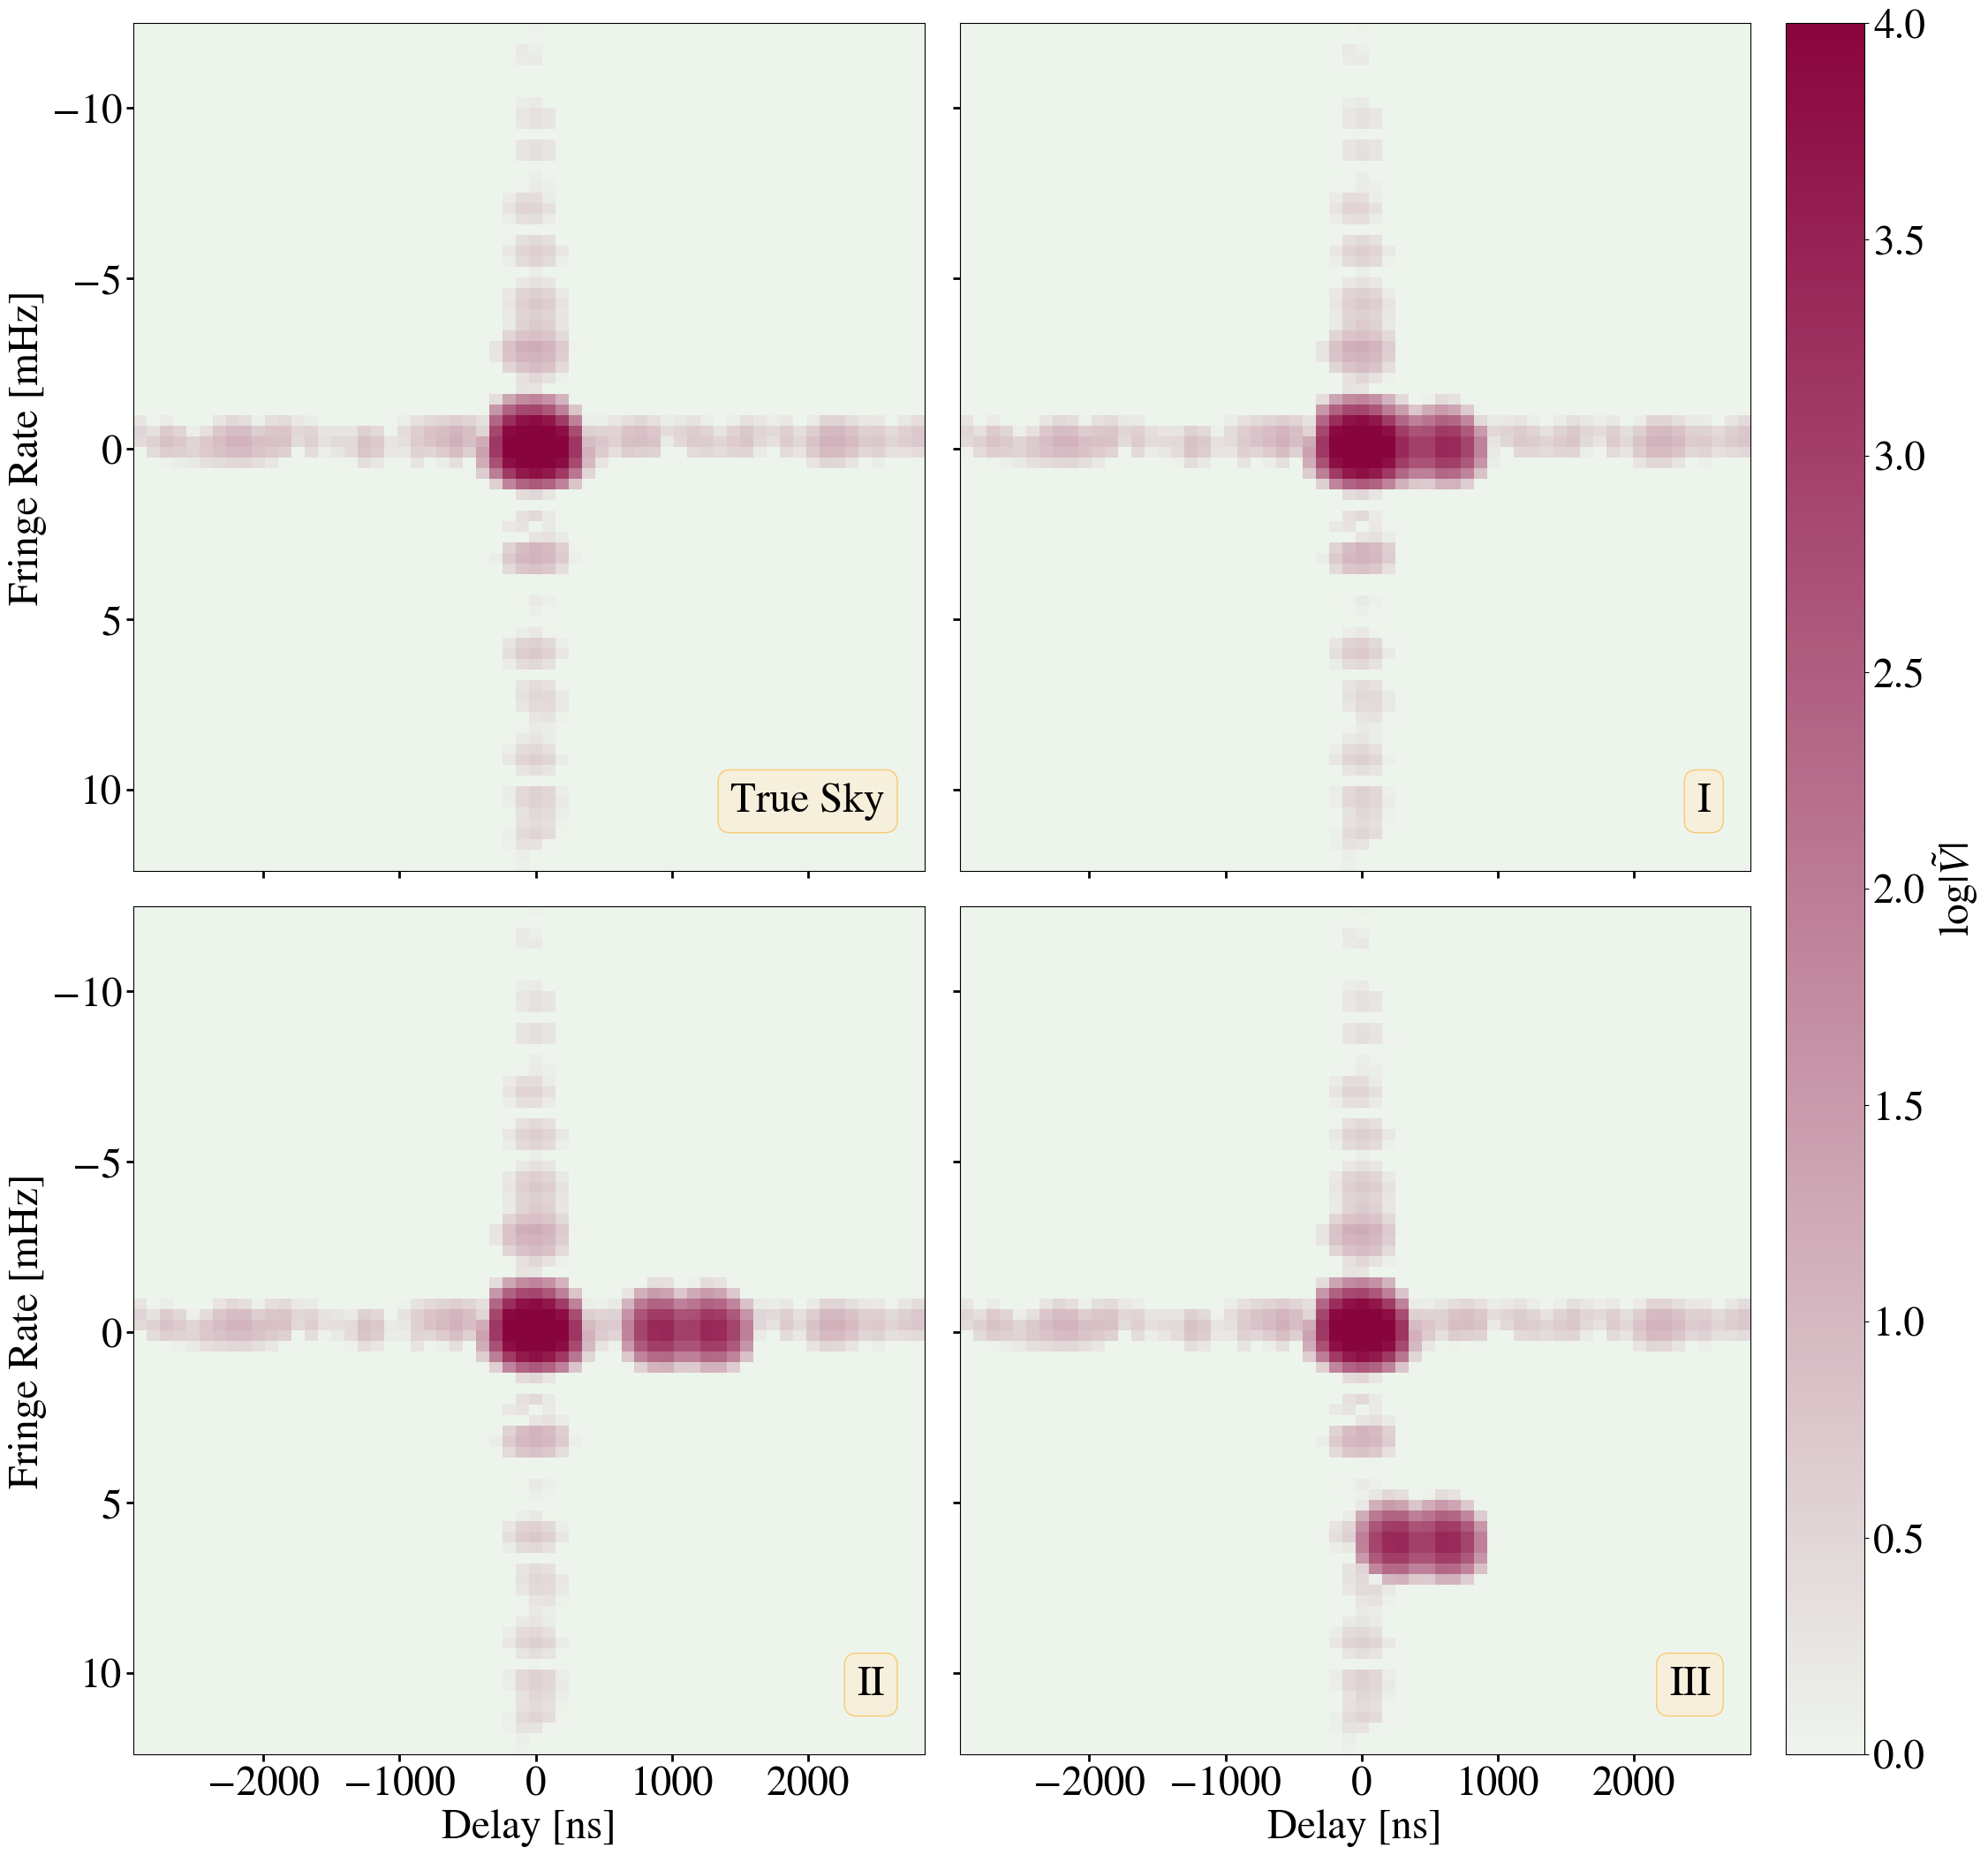

In [118]:
fig = plt.figure(figsize=(20., 20.))
axs = ImageGrid(
    fig,
    rect=(0.06, 0.06, 0.98, 0.98),
    nrows_ncols=(2, 2),
    axes_pad=0.4,
    cbar_mode='single',
    cbar_location='right',
    cbar_pad=0.4,
    label_mode='L',
    aspect=False,
)

_ = plot_waterfalls_from_dlfr(
    sky_true_dlfr, freqs * 1e6, times_jd, fig=fig, ax=axs[0], mode='log',
    vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all',
    baseline=None, horizon_color='magenta', colorbar_flag=False,
)
axs[0].text(0.95, 0.07, 'True Sky', bbox=bbox, transform=axs[0].transAxes, horizontalalignment='right')

fig_labels = ['I', 'II', 'III']
for i, run_version in enumerate(run_version_arr):
    sys_model_true = np.load(result_dir + run_version + '/gain_true.npy')
    # op = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts_sec, modes=nm_list_arr[i])
    # sys_model_true = (1 + op @ sys_amps_true).reshape((Nfreqs, Ntimes)).T
    total_data_dlfr = dlfr(sys_model_true * (eor_true+fg_true))
    plot_op = plot_waterfalls_from_dlfr(
        total_data_dlfr, freqs * 1e6, times_jd, fig=fig, ax=axs[i + 1], mode='log',
        vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=False,
        baseline=None, horizon_color='magenta',
    )
    axs[i + 1].text(0.95, 0.07, fig_labels[i], bbox=bbox, transform=axs[i + 1].transAxes, horizontalalignment='right')

axs.cbar_axes[0].colorbar(plot_op, label=r'$\log|\tilde{V}|$')
plt.savefig(fig_dir + '/test_cases_in_dlfr.pdf', bbox_inches='tight', dpi=300)

---
# Figure 4: Data vs sky (all cases)

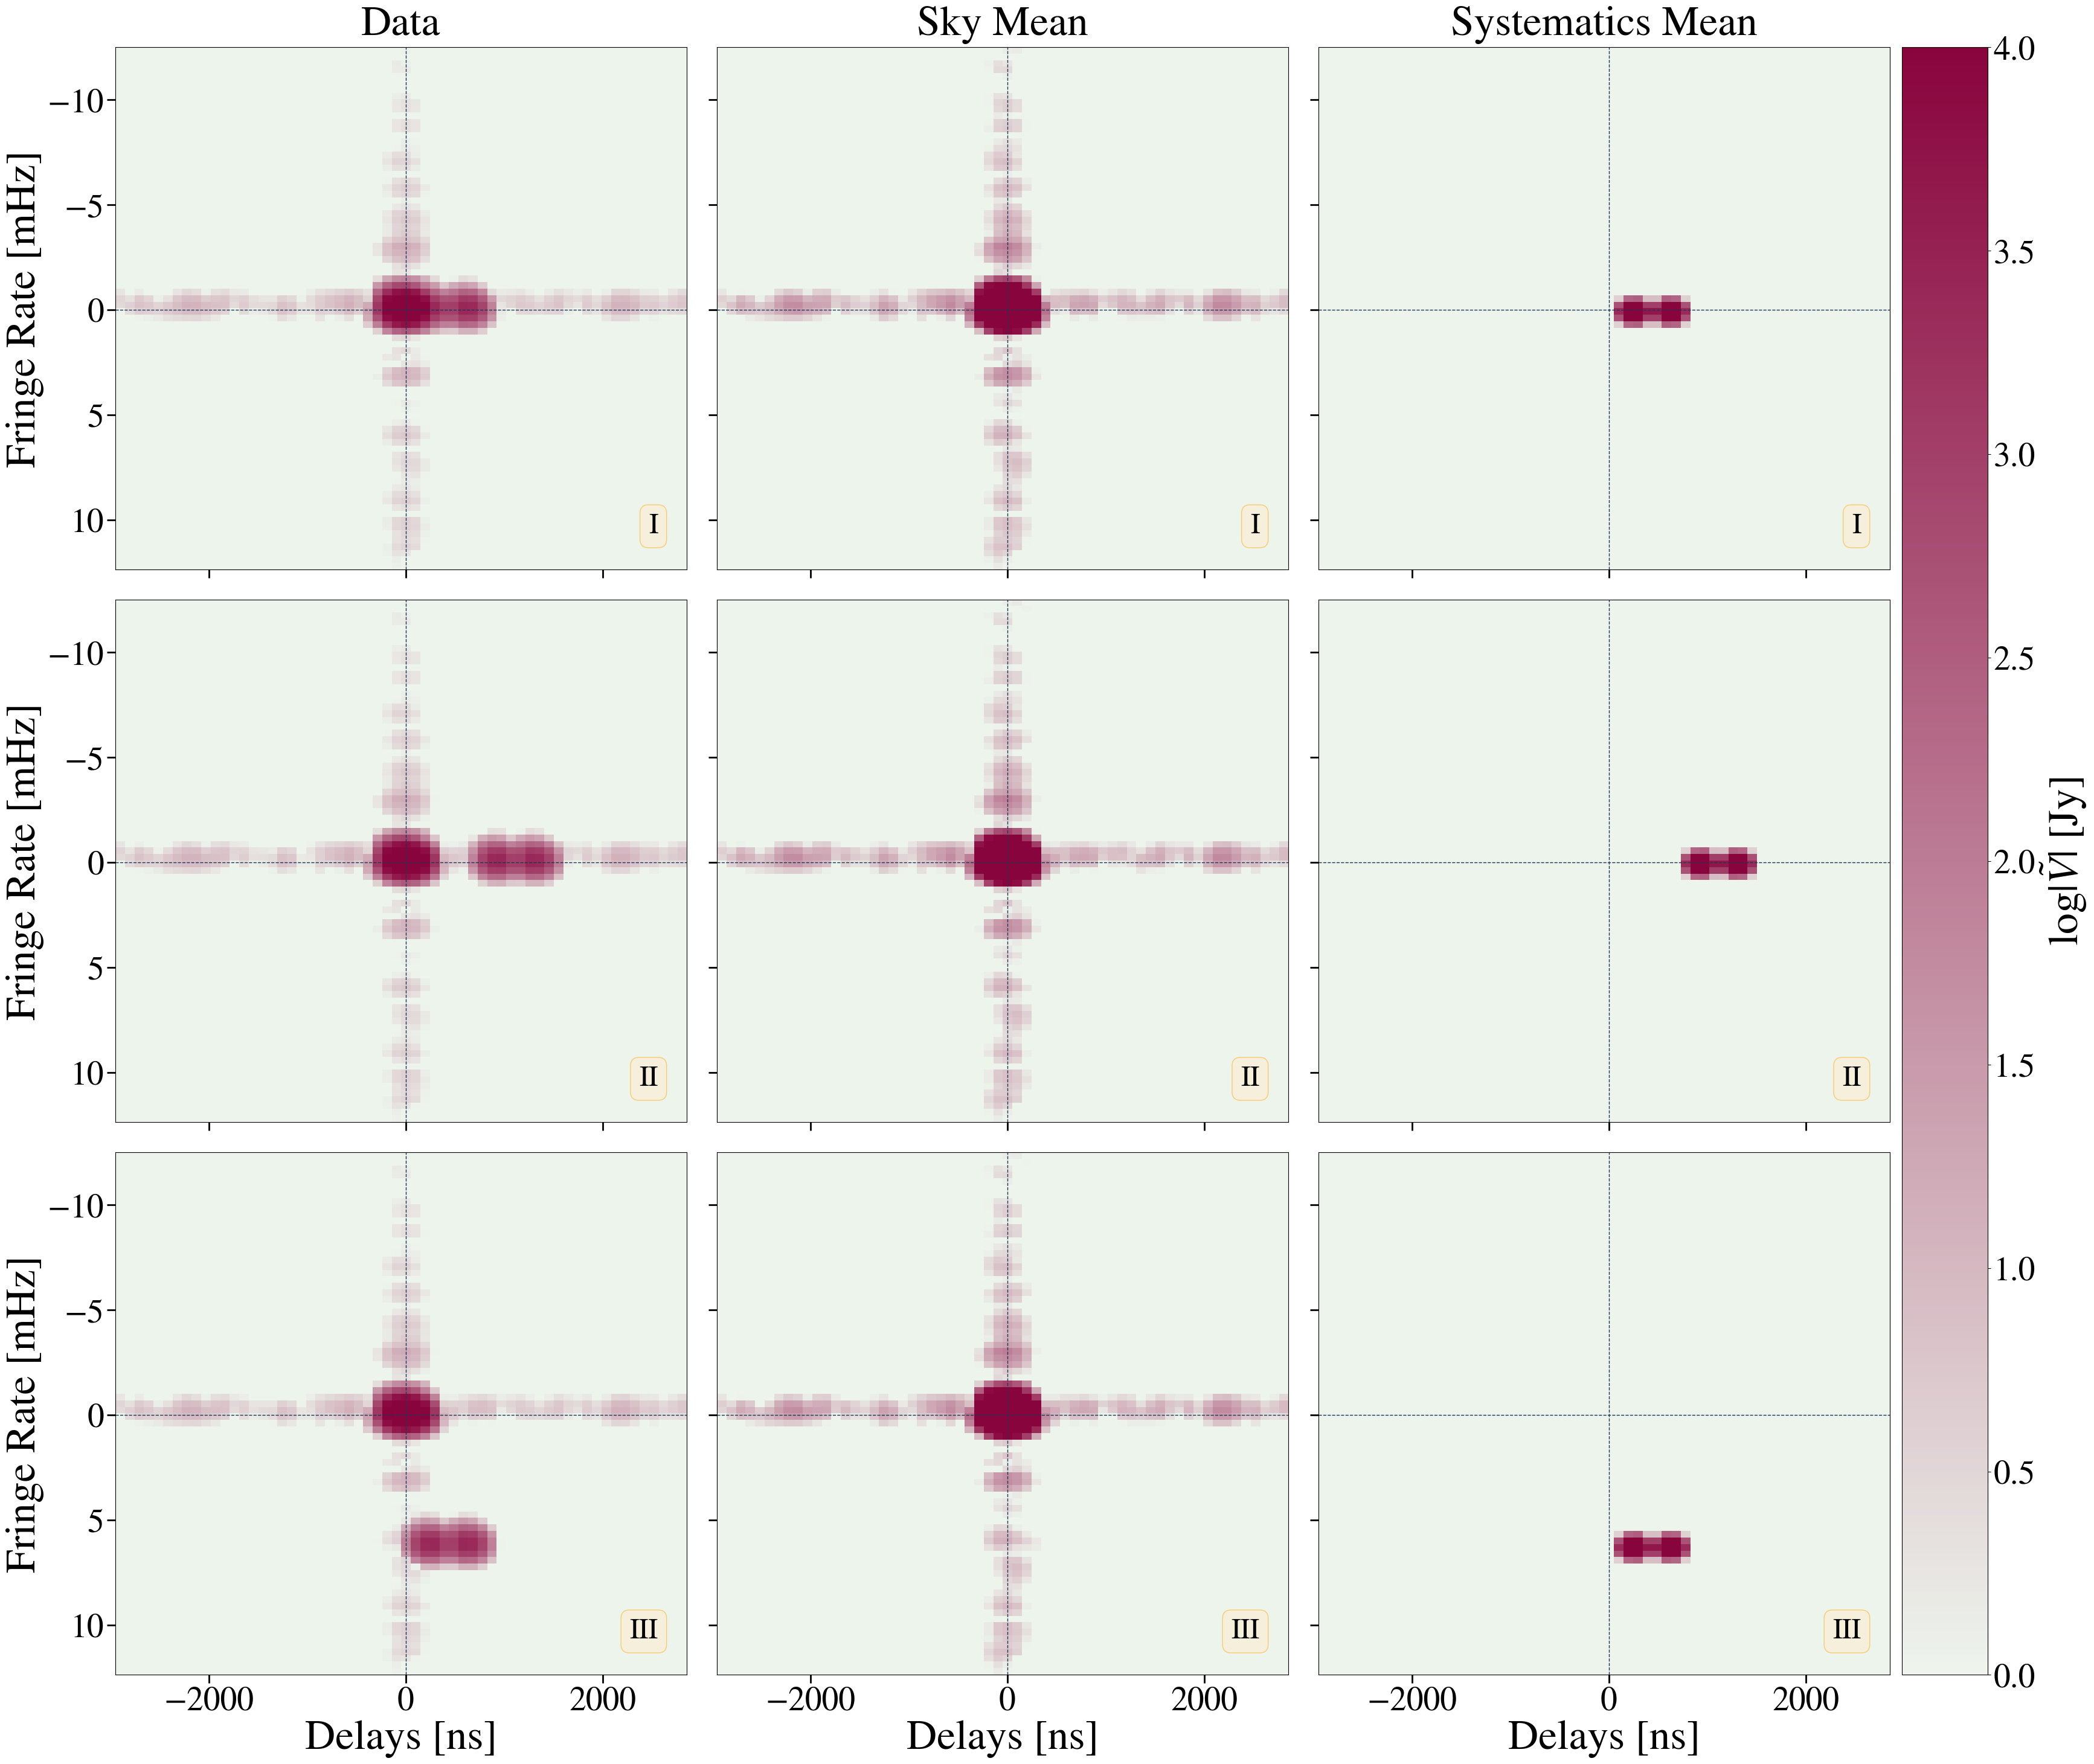

In [128]:
fig = plt.figure(figsize=(40, 35))
ax = ImageGrid(
    fig, 111,
    nrows_ncols=(3, 3),
    axes_pad=0.5,
    share_all=True,
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

c = 0
for a in range(3):
    im0 = plot_waterfalls_from_dlfr(
        data_true_dlfr_all[a], freqs * 1e6, times_jd, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=4, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1
    im1 = plot_waterfalls_from_dlfr(
        mean_sky_dlfr_all[a], freqs * 1e6, times_jd, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=2.5, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1
    im2 = plot_waterfalls_from_dlfr(
        delta_g_dlfr_mean_all[a], freqs * 1e6, times_jd, fig=fig, ax=ax[c], mode='log',
        vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=dynamic_range,
        limit_drng='all', colorbar_flag=False, baseline=None, horizon_color='magenta',
    )
    c += 1

fig_labels_all = ['I'] * 3 + ['II'] * 3 + ['III'] * 3
fig_titles     = ['Data', 'Sky Mean', 'Systematics Mean']
for i, a in enumerate(ax):
    a.tick_params(direction='out', length=6, width=2, colors='black', size=10, labelsize=40)
    a.set_xlabel('Delays [ns]', fontsize=50)
    a.set_ylabel('Fringe Rate [mHz]', fontsize=50)
    a.text(0.95, 0.07, fig_labels_all[i], bbox=bbox, transform=a.transAxes, horizontalalignment='right')
for i, a in enumerate(ax[:3]):
    a.set_title(fig_titles[i], fontsize=50, pad=15)

for a in ax:
    a.axvline(0, color=colors[0], linestyle='--', linewidth=1)
    a.axhline(0, color=colors[0], linestyle='--', linewidth=1)
    
cbar = ax.cbar_axes[0].colorbar(im0)
cbar.set_label(r'$\log|\tilde{V}|$ [Jy]', size=50)
cbar.ax.tick_params(labelsize=40)
plt.savefig(fig_dir + '/data_vs_sky_2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 5: Result waterfalls (single case)

Text(0.95, 0.07, 'Residuals (True-$\\mu$)')

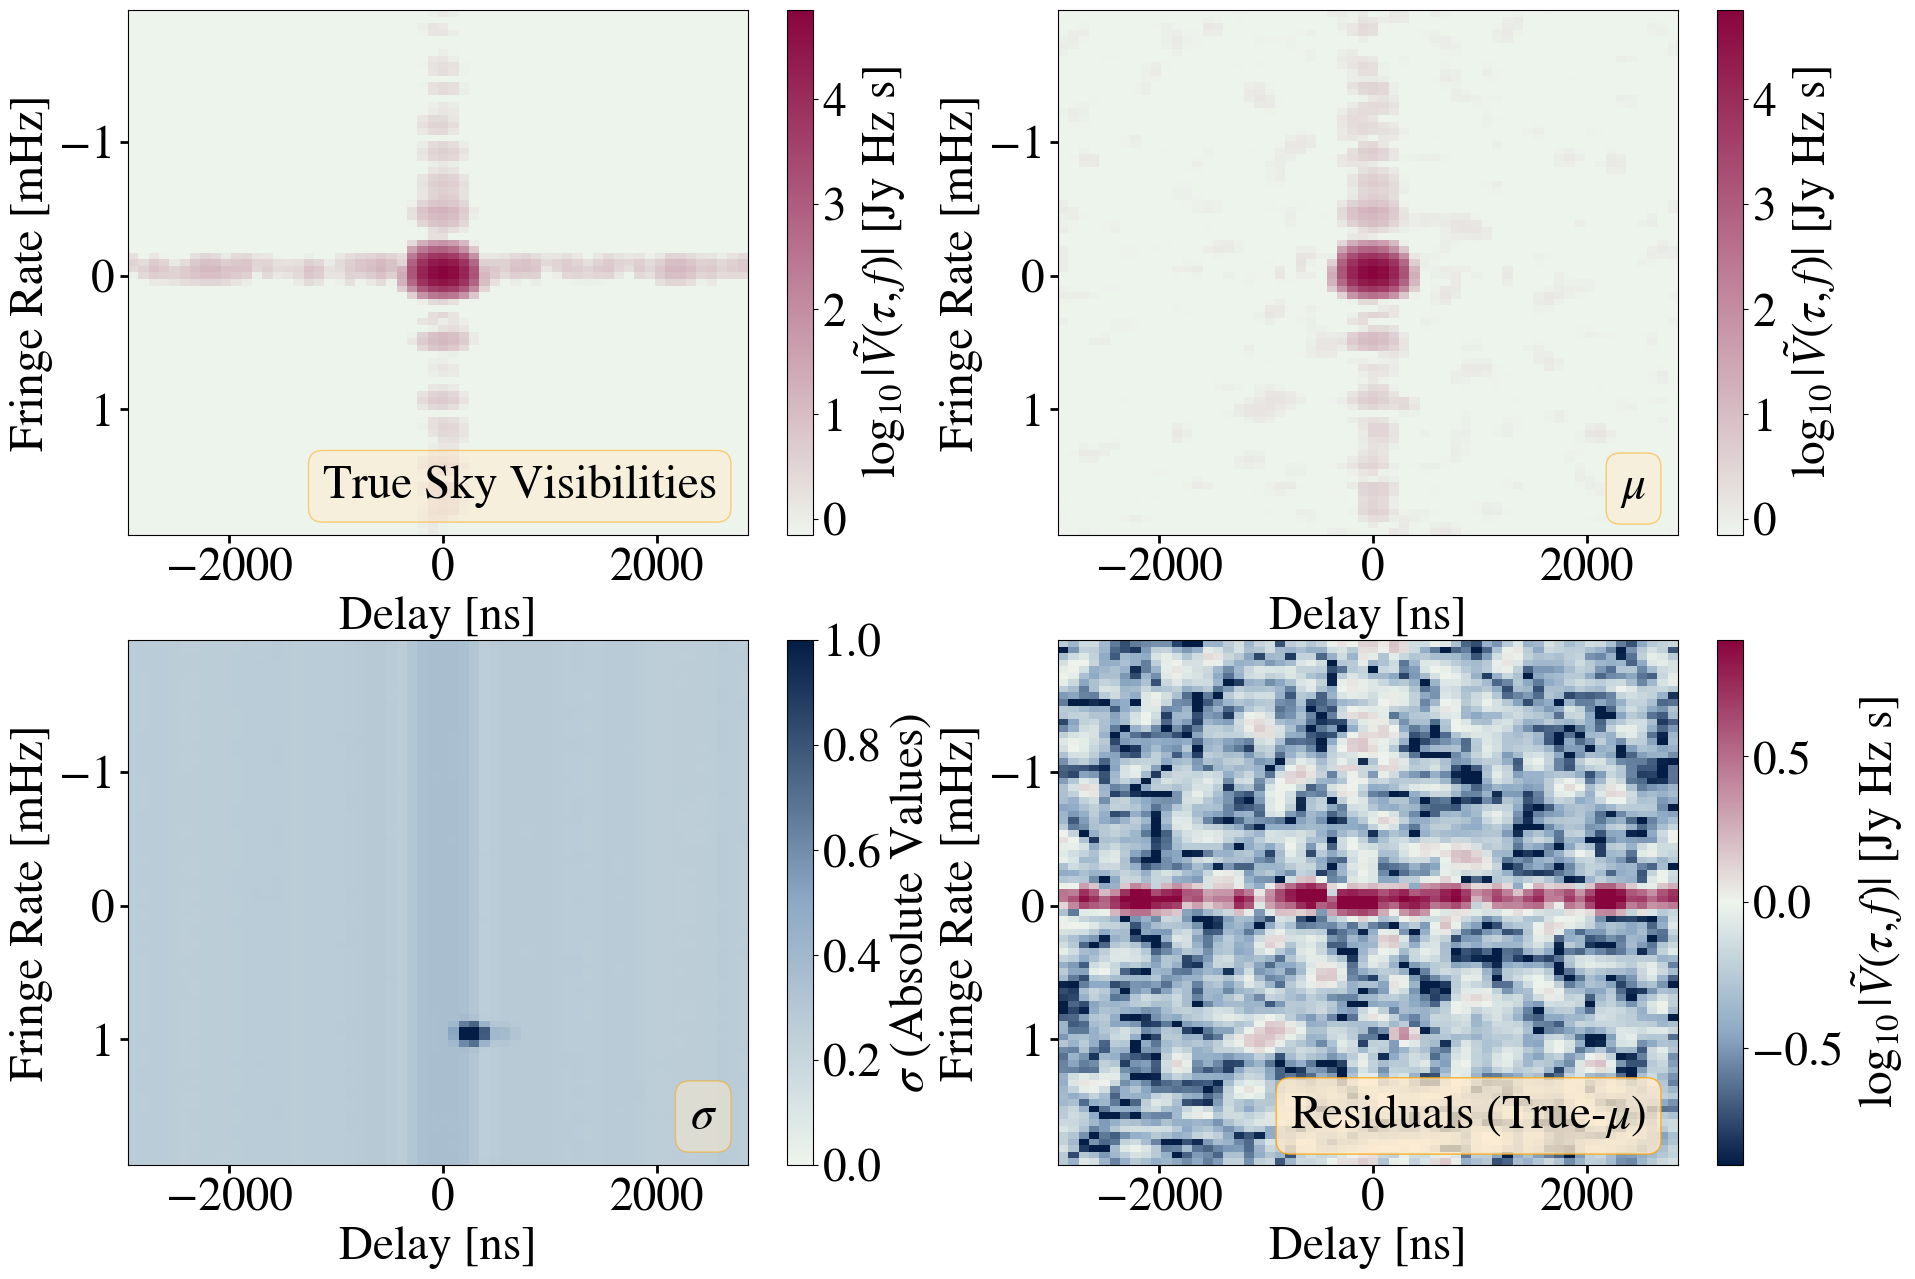

In [21]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    sky_true_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Sky Visibilities', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=None, vmax=None, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    np.std(sky_dlfr_arr, axis=0), freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=1, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sky_true_dlfr - mean_sky_dlfr, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[3], mode='log',
    vmin=-0.9, vmax=0.9, cmap=paper_map, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
# plt.savefig(fig_dir + '/result_waterfalls.pdf', bbox_inches='tight', dpi=300)

---
# Figures 5 & 6 v2: All-cases result waterfalls

Versions of Figures 5 and 6 with all three cases shown simultaneously.
Columns = Case I / II / III; Rows = True / Mean / Std / Residuals.

In [129]:
# All-cases statistics for the v2 figures were computed in the "All-cases data" cell above.
# Lists are indexed 0/1/2 = Case I / II / III.
# Available: sky_true_dlfr_all, mean_sky_dlfr_all, std_sky_dlfr_all, res_sky_dlfr_all,
#            delta_g_dlfr_true_all, delta_g_dlfr_mean_all, delta_g_dlfr_std_all, res_sys_dlfr_all.

case_labels_v2 = ['Case I', 'Case II', 'Case III']
row_labels_v2  = ['True', r'$\mu$', r'$\sigma$', 'Residuals']

### Figure 5 v2: Sky result waterfalls (all cases)

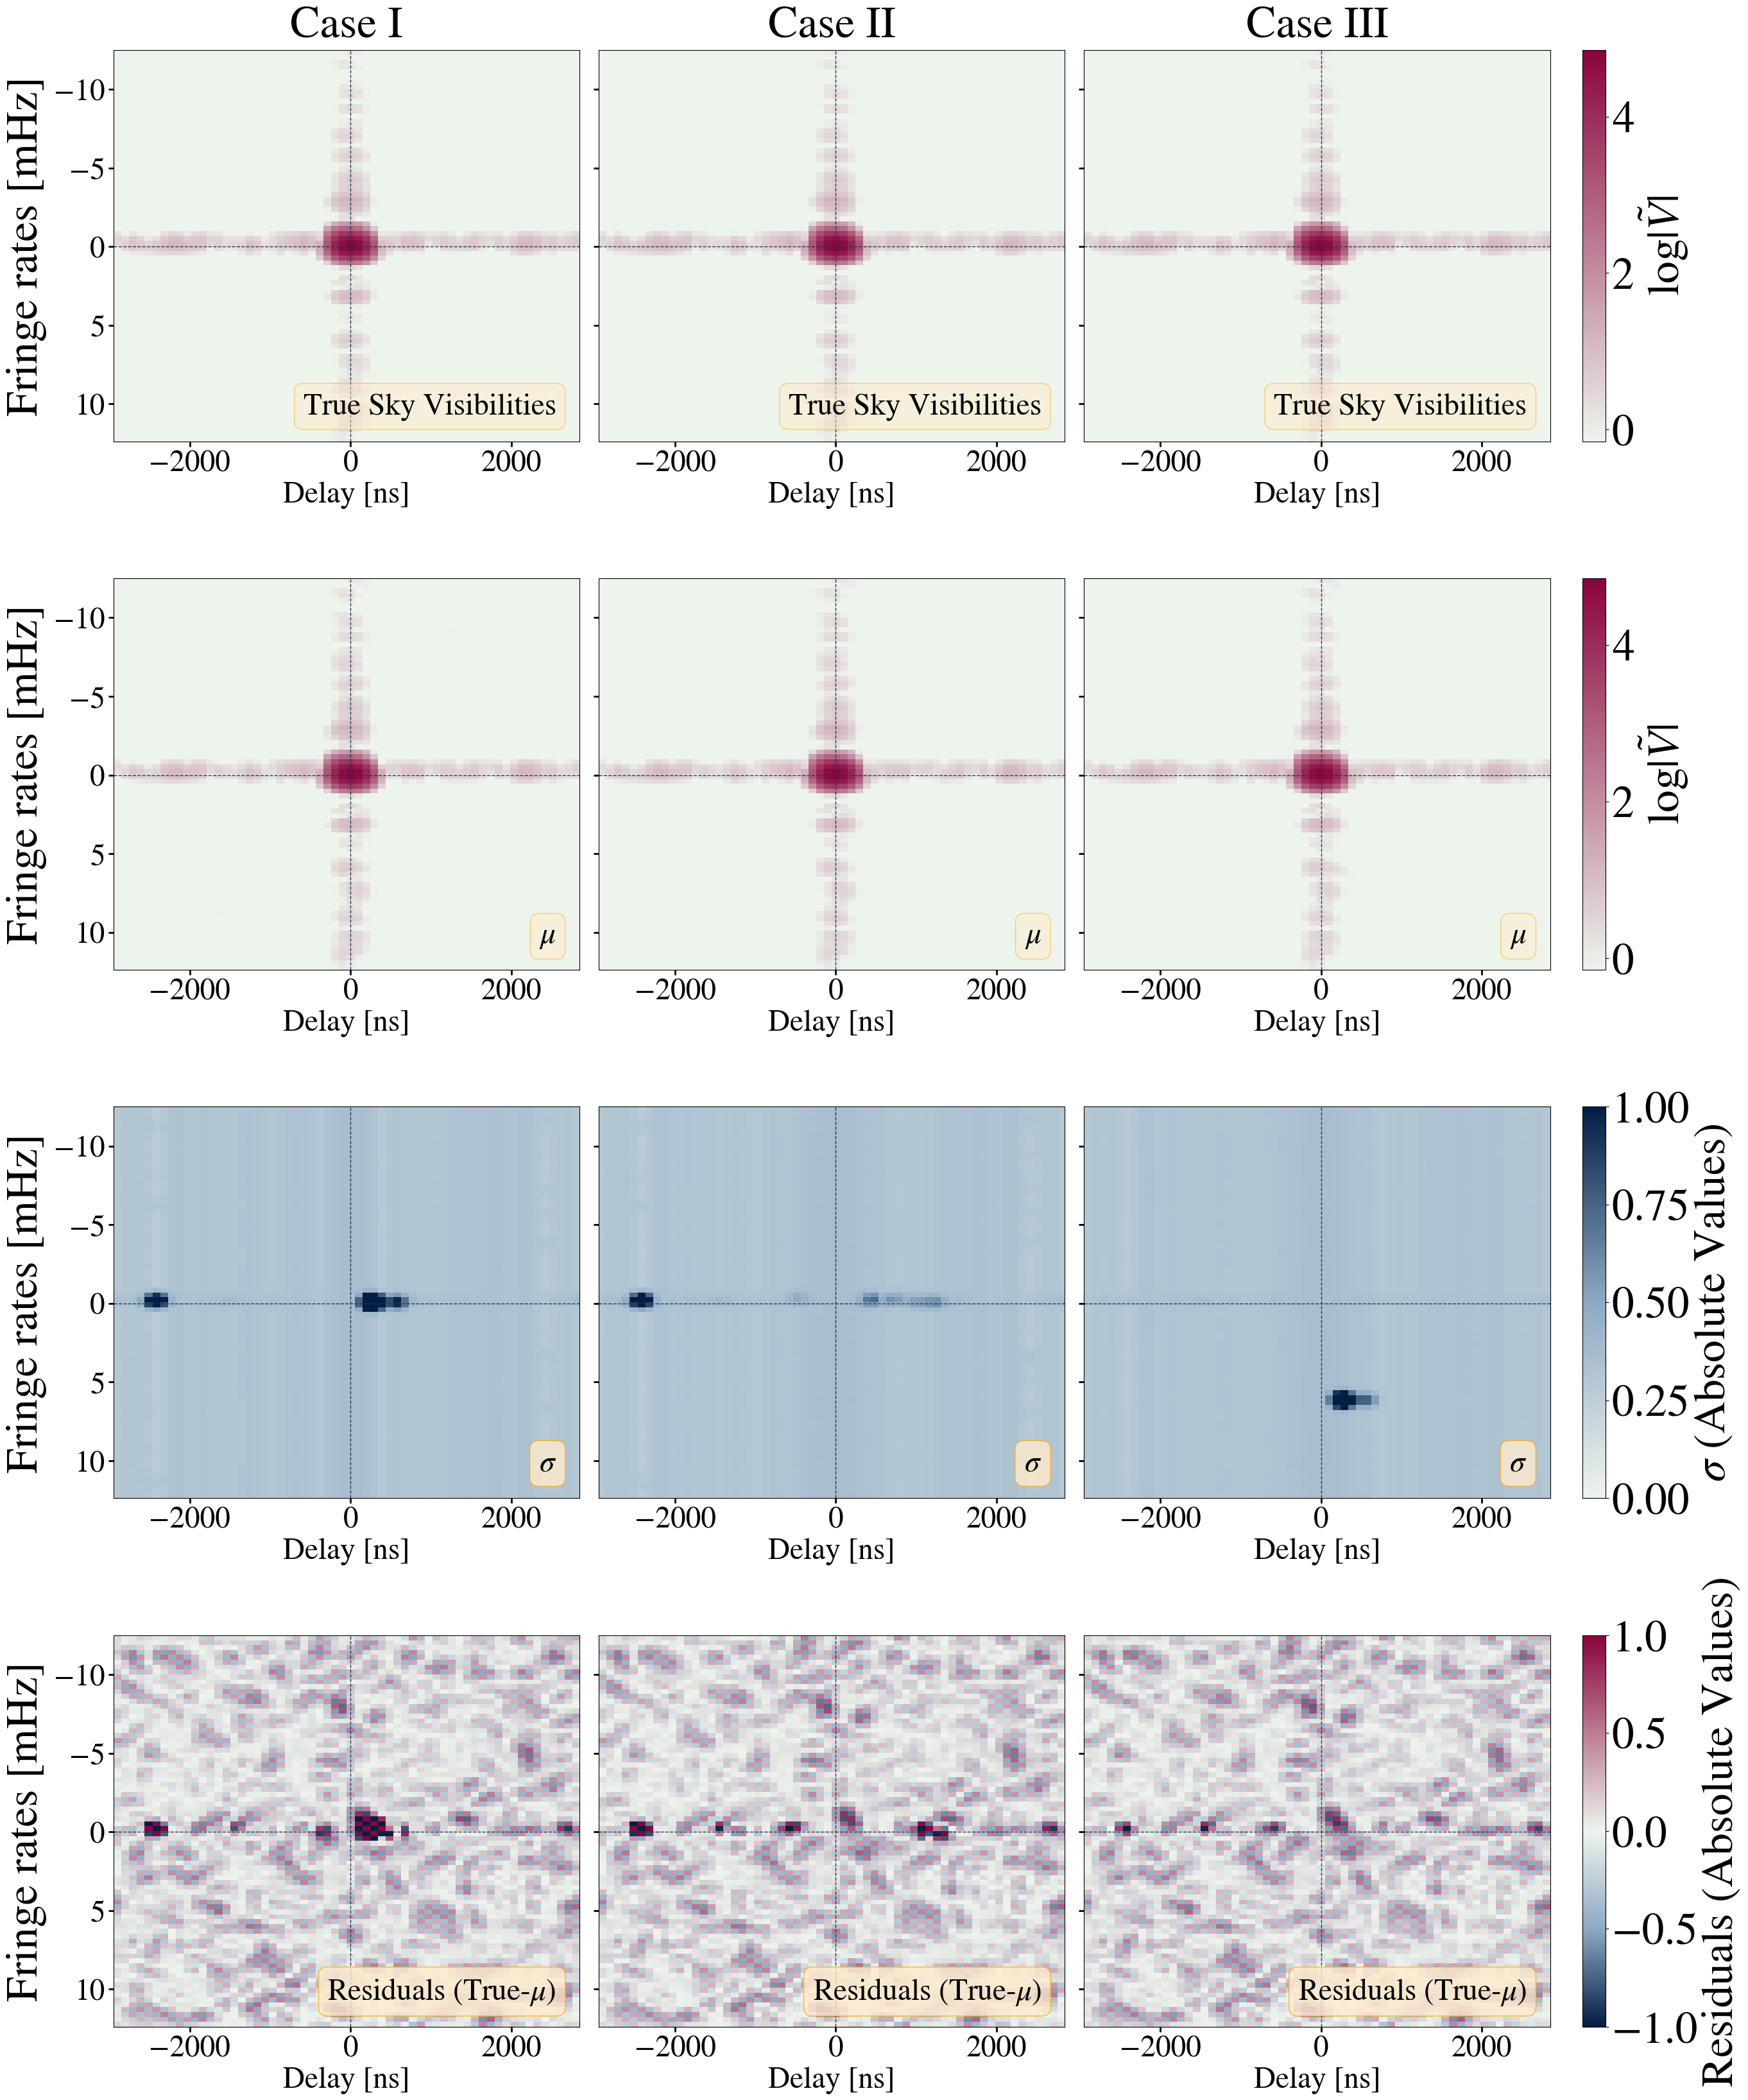

In [165]:
from mpl_toolkits.axes_grid1 import ImageGrid
import matplotlib.gridspec as gridspec

fig5v2 = plt.figure(figsize=(30, 40))

# Master gridspec: one row per image-grid
outer_gs = gridspec.GridSpec(4, 1, figure=fig5v2, hspace=0.35)

grids = []
for row in range(4):
    grid = ImageGrid(
        fig5v2, outer_gs[row],
        nrows_ncols=(1, 3),
        axes_pad=0.3,
        share_all=True,
        cbar_location='right',
        cbar_mode='single',
        cbar_size='5%',
        cbar_pad=0.5,
        aspect=False,   # <-- add this
    )
    grids.append(grid)

# --- Plotting ---
cmap_list  = [paper_map_pink, paper_map_pink, paper_map_blue, paper_map]
mode_list  = ['log', 'log', 'real', 'real']
vmin_list  = [None, None, 0, -1]
vmax_list  = [None, None, 1,  1]
cbar_labels = [
    r'$\log|\tilde{V}|$',
    r'$\log|\tilde{V}|$',
    r'$\sigma$ (Absolute Values)',
    'Residuals (Absolute Values)',
]
data_all = [
    sky_true_dlfr_all,
    mean_sky_dlfr_all,
    std_sky_dlfr_all,
    res_sky_dlfr_all,
]

for row, grid in enumerate(grids):
    im = None
    for col in range(3):
        im = plot_waterfalls_from_dlfr(
            data_all[row][col], freqs * 1e6, times_jd,
            fig=fig5v2, ax=grid[col],
            mode=mode_list[row],
            vmin=vmin_list[row], vmax=vmax_list[row],
            cmap=cmap_list[row], dynamic_range=5 if row < 2 else None,
            limit_drng='all', colorbar_flag=False,
            baseline=None, horizon_color='magenta',
        )
        # Crosshairs
        grid[col].axvline(0, color=colors[0], linestyle='--', linewidth=1)
        grid[col].axhline(0, color=colors[0], linestyle='--', linewidth=1)

        # Annotations
        bbox_use = bbox_res if row >= 2 else bbox
        grid[col].text(
            0.95, 0.07, annots_sky_v2[row], bbox=bbox_use,
            transform=grid[col].transAxes, ha='right',
        )

        # Column titles (top row only)
        if row == 0:
            grid[col].set_title(case_labels_v2[col], fontsize=50, pad=15)

    # Shared colorbar for this row
    cbar = grid.cbar_axes[0].colorbar(im, pad=15)
    cbar.set_label(cbar_labels[row], fontsize=50)
    grid.cbar_axes[0].tick_params(labelsize=50)

    # Y-axis label on leftmost panel
    grid[0].set_ylabel(row_labels_v2[row], fontsize=50, labelpad=8)

plt.savefig(fig_dir + '/result_waterfalls_v2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 6: Systematics result waterfalls (single case)

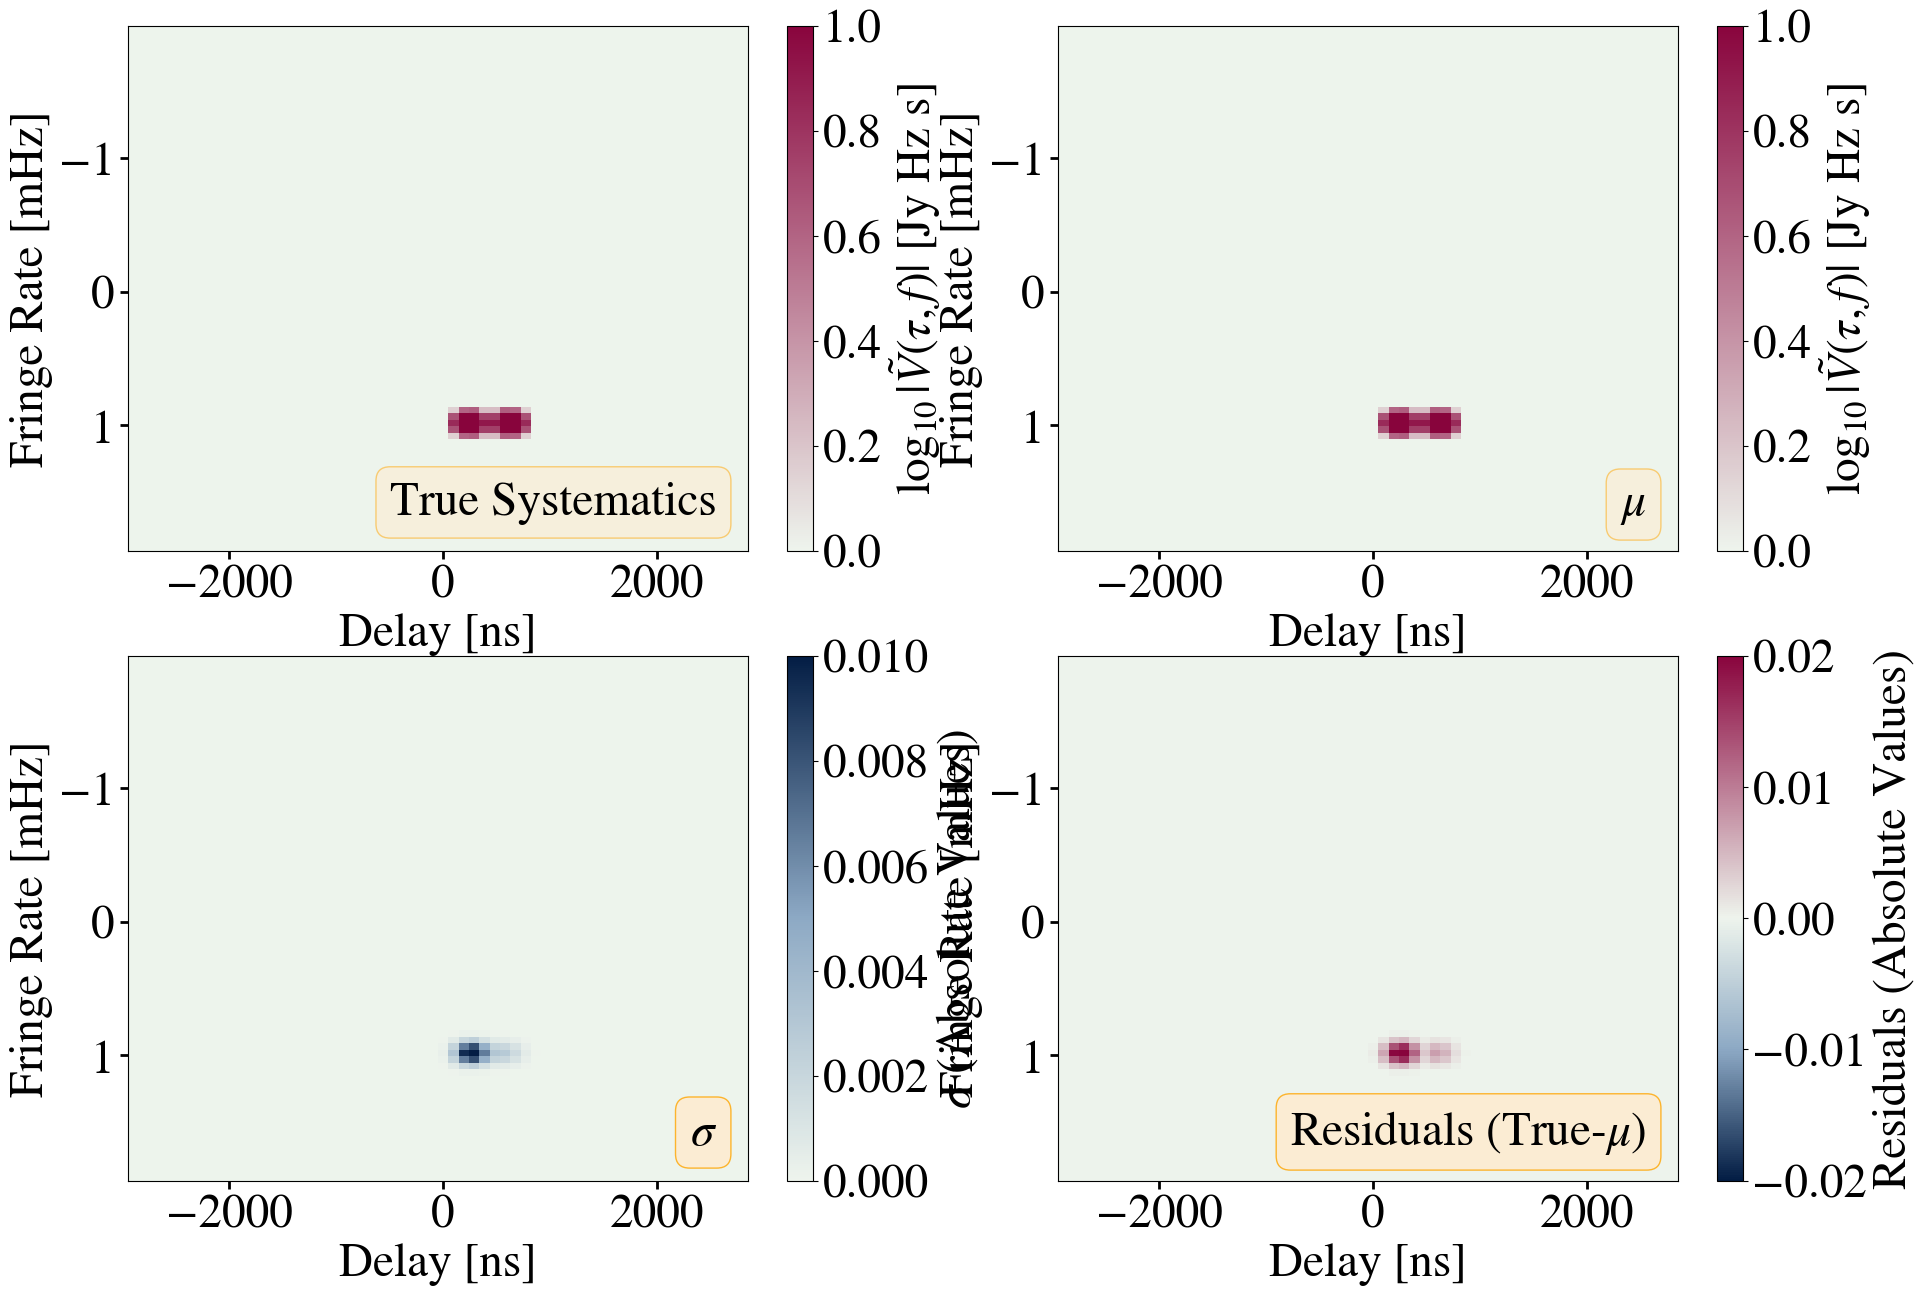

In [16]:
fig, axs = plt.subplots(2, 2, figsize=(22, 15))

plot_waterfalls_from_dlfr(
    delta_g_dlfr_true, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[0], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[0].text(0.95, 0.07, 'True Systematics', bbox=bbox,
                      transform=axs.flatten()[0].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_mean, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[1], mode='log',
    vmin=0, vmax=1, cmap=paper_map_pink, dynamic_range=5, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta',
)
axs.flatten()[1].text(0.95, 0.07, r'$\mu$', bbox=bbox,
                      transform=axs.flatten()[1].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    delta_g_dlfr_std, freqs * 1e6, lsts, fig=fig, ax=axs.flatten()[2], mode='abs',
    vmin=0, vmax=0.01, cmap=paper_map_blue, dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label=r'$\sigma$ (Absolute Values)',
)
axs.flatten()[2].text(0.95, 0.07, r'$\sigma$', bbox=bbox_res,
                      transform=axs.flatten()[2].transAxes, horizontalalignment='right')

plot_waterfalls_from_dlfr(
    sys_model_true_dlfr - sys_model_dlfr_mean, freqs * 1e6, lsts,
    fig=fig, ax=axs.flatten()[3], mode='abs', vmin=-0.02, vmax=0.02, cmap=paper_map,
    dynamic_range=None, limit_drng='all', colorbar_flag=True,
    baseline=None, horizon_color='magenta', cbar_label='Residuals (Absolute Values)',
)
axs.flatten()[3].text(0.95, 0.07, 'Residuals (True-' + r'$\mu$' + ')', bbox=bbox_res,
                      transform=axs.flatten()[3].transAxes, horizontalalignment='right')
plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls.pdf', bbox_inches='tight', dpi=300)

### Figure 6 v2: Systematics result waterfalls (all cases)

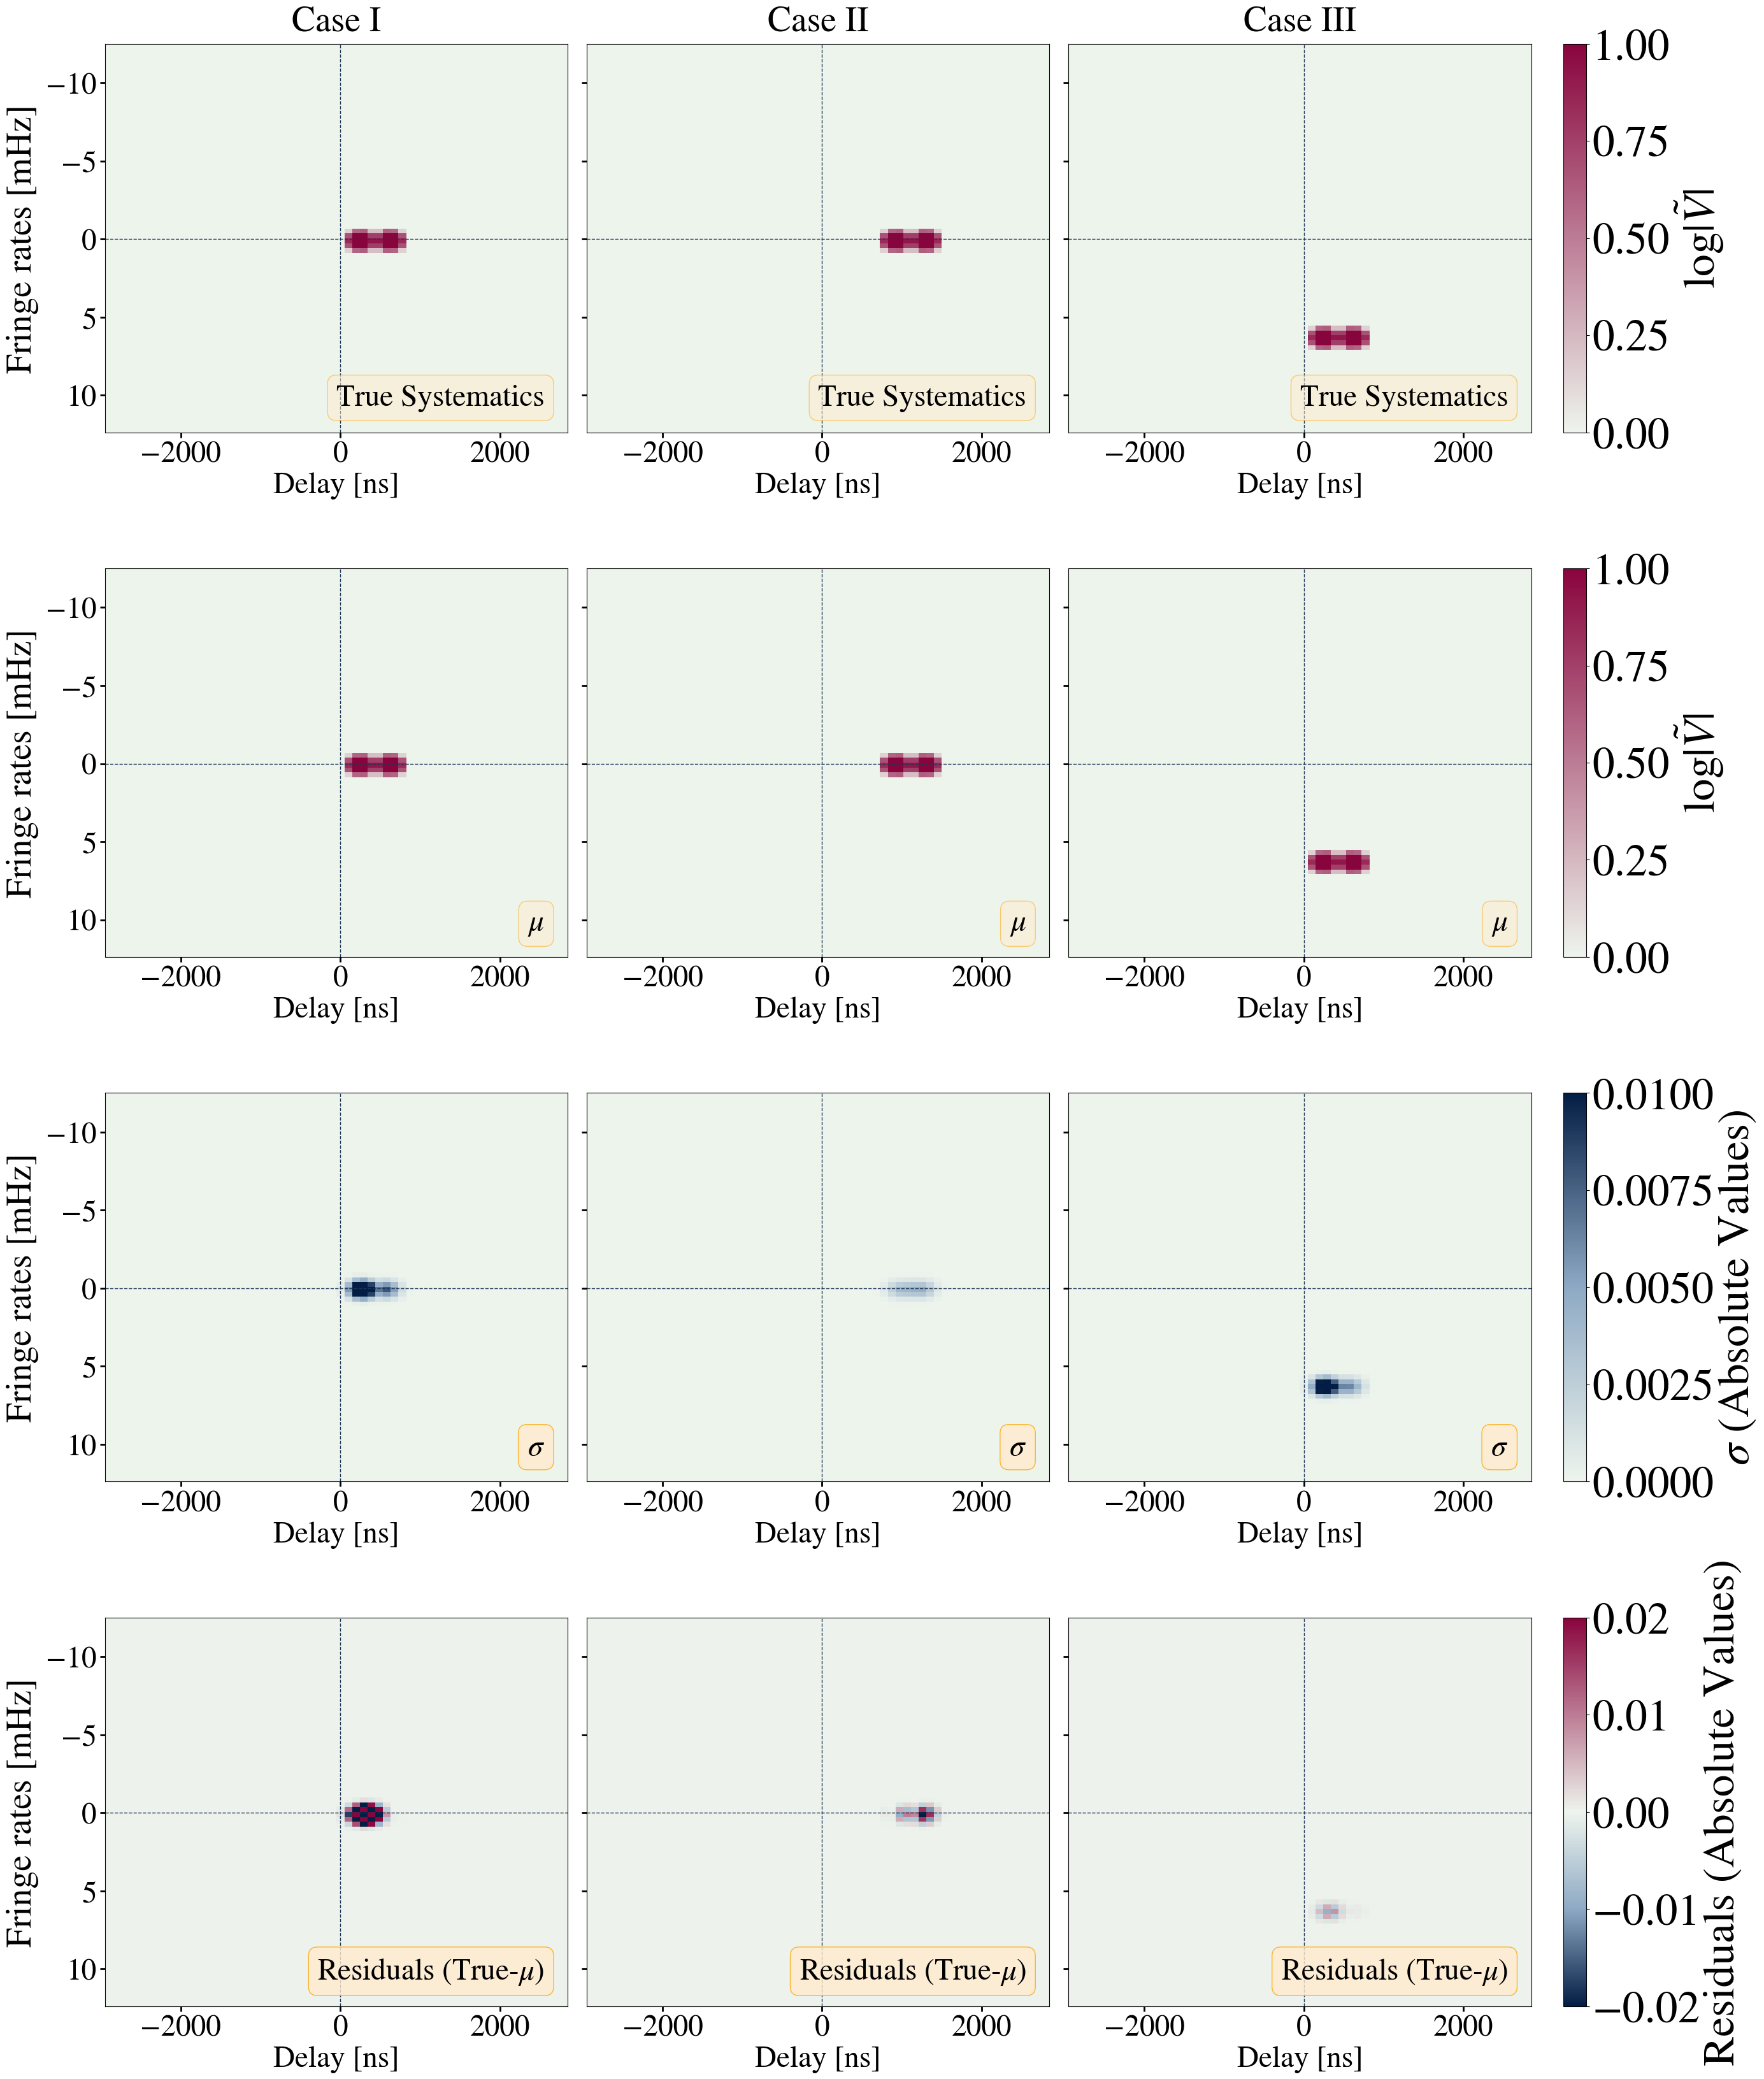

In [ ]:
from mpl_toolkits.axes_grid1 import ImageGrid
import matplotlib.gridspec as gridspec

annots_sys_v2 = [
    'True Systematics',
    r'$\mu$',
    r'$\sigma$',
    'Residuals (True-' + r'$\mu$' + ')',
]

fig6v2 = plt.figure(figsize=(30, 40))
outer_gs = gridspec.GridSpec(4, 1, figure=fig6v2, hspace=0.35)

grids = []
for row in range(4):
    grid = ImageGrid(
        fig6v2, outer_gs[row],
        nrows_ncols=(1, 3),
        axes_pad=0.3,
        share_all=True,
        cbar_location='right',
        cbar_mode='single',
        cbar_size='5%',
        cbar_pad=0.5,
        aspect=False,
    )
    grids.append(grid)

cmap_list  = [paper_map_pink, paper_map_pink, paper_map_blue, paper_map]
mode_list  = ['log', 'log', 'real', 'real']
vmin_list  = [0,    0,    0,     -0.02]
vmax_list  = [1,    1,    0.01,   0.02]
cbar_labels = [
    r'$\log|\tilde{V}|$',
    r'$\log|\tilde{V}|$',
    r'$\sigma$ (Absolute Values)',
    'Residuals (Absolute Values)',
]
data_all = [
    delta_g_dlfr_true_all,
    delta_g_dlfr_mean_all,
    delta_g_dlfr_std_all,
    res_sys_dlfr_all,
]

for row, grid in enumerate(grids):
    im = None
    for col in range(3):
        im = plot_waterfalls_from_dlfr(
            data_all[row][col], freqs * 1e6, times_jd,
            fig=fig6v2, ax=grid[col],
            mode=mode_list[row],
            vmin=vmin_list[row], vmax=vmax_list[row],
            cmap=cmap_list[row], dynamic_range=5 if row < 2 else None,
            limit_drng='all', colorbar_flag=False,
            baseline=None, horizon_color='magenta',
        )
        grid[col].axvline(0, color=colors[0], linestyle='--', linewidth=1)
        grid[col].axhline(0, color=colors[0], linestyle='--', linewidth=1)

        bbox_use = bbox_res if row >= 2 else bbox
        grid[col].text(
            0.95, 0.07, annots_sys_v2[row], bbox=bbox_use,
            transform=grid[col].transAxes, ha='right',
        )

        if row == 0:
            grid[col].set_title(case_labels_v2[col], fontsize=40, pad=15)

    cbar = grid.cbar_axes[0].colorbar(im,pad =15)
    cbar.set_label(cbar_labels[row], fontsize=50)
    grid.cbar_axes[0].tick_params(labelsize=50)
    grid[0].set_ylabel(row_labels_v2[row], fontsize=40, labelpad=8)

plt.savefig(fig_dir + '/sys_result_dlfr_waterfalls_v2.pdf', bbox_inches='tight', dpi=300)

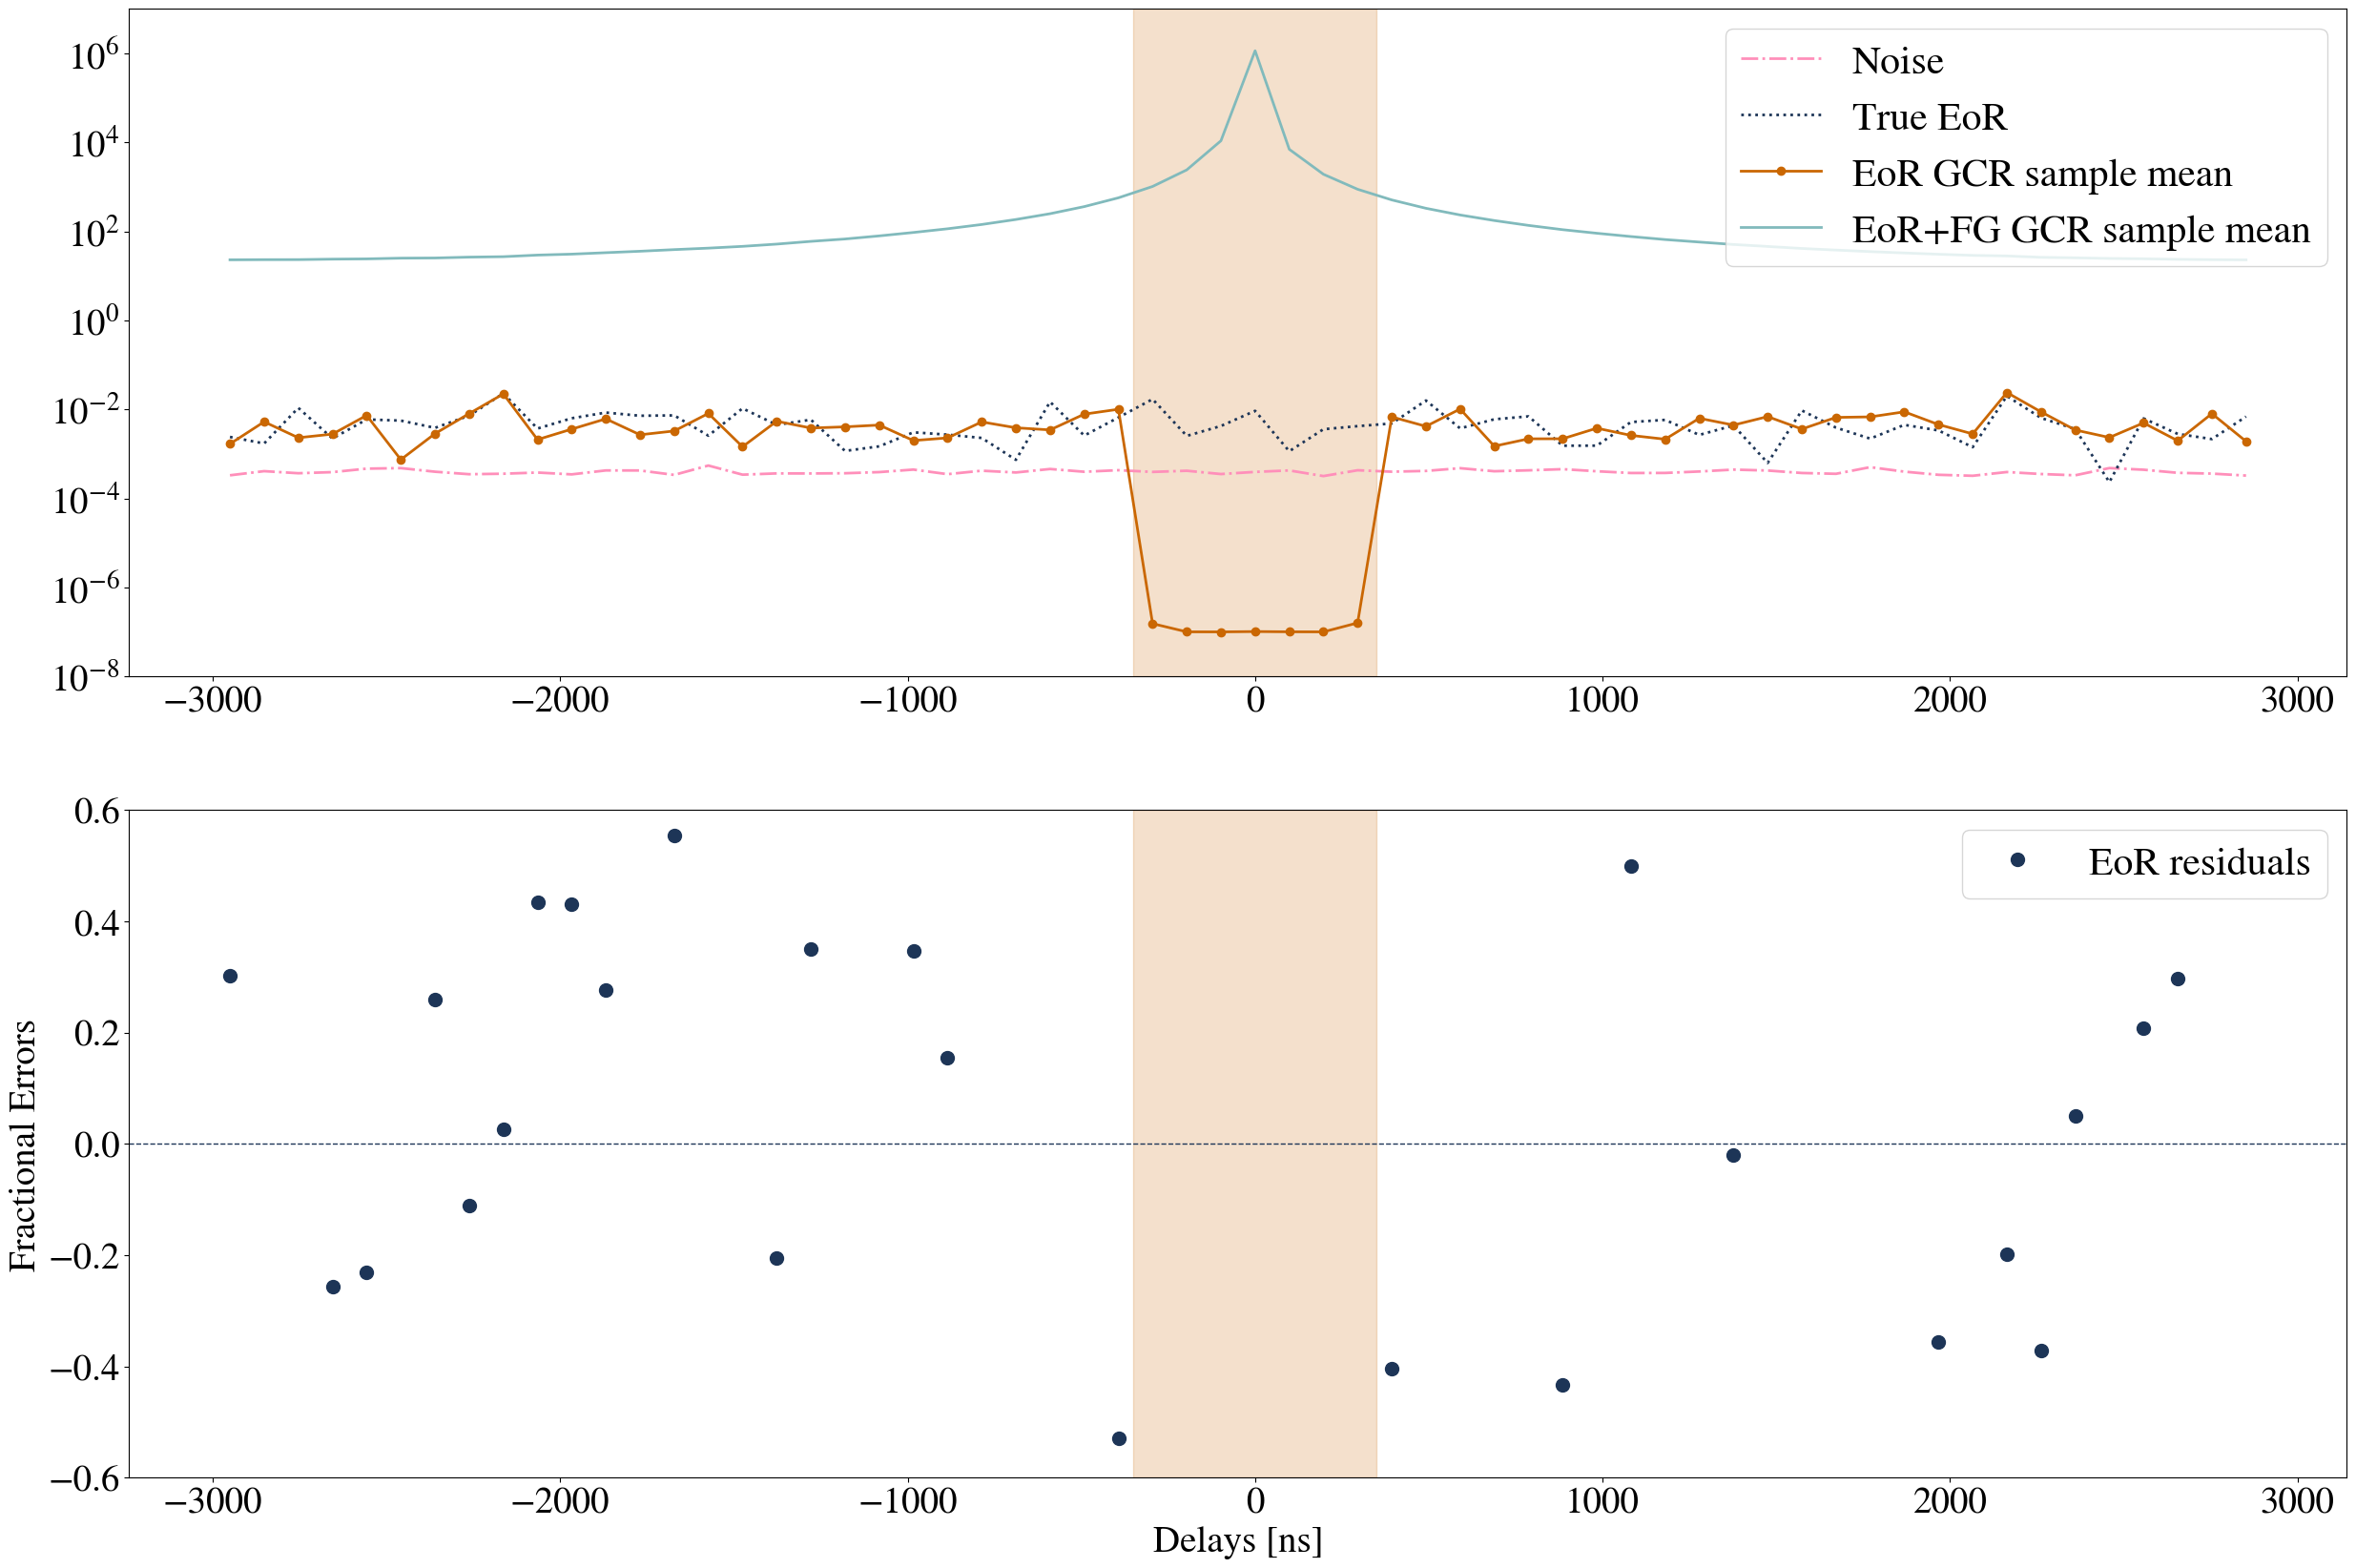

In [205]:
fig, axs = plt.subplots(2, 1, figsize=(30, 20))

data_arr_errs = [
    (eor_pspec_true - ps_sample) / eor_pspec_true,
]
plot_arr = [d.mean(axis=0) for d in data_arr_errs]
fig_labels_err = ['True EoR','EoR GCR sample mean', 'EoR+FG GCR sample mean', 'Noise']

rm   = np.arange(27, 34)
keep = np.ones(len(plot_arr[0]), dtype=bool)
keep[rm] = False

#  --------------- top plot ----------------
axs[0].semilogy(delays, n_pspec, ls='-.', c=colors[-1], label=fig_labels_err[-1], lw=2)
axs[0].semilogy(delays, eor_pspec_true, ls='dotted',  c=colors[0], label=fig_labels_err[0], lw=2)
axs[0].semilogy(delays, ps_sample.mean(axis=0), marker='o', c=colors[1], label=fig_labels_err[1], lw=2)
axs[0].semilogy(delays, sky_pspec_avg, c=colors[2], label=fig_labels_err[2], lw=2)
axs[0].legend(fontsize=30)
axs[0].set_ylim(1e-8, 1e7)
axs[0].axvspan(-350, 350, facecolor=colors[1], ec=colors[1],alpha=0.2, zorder=0.1)


# --------------------- bottom plot ----------------------
pa = plot_arr[0][keep]
da = data_arr_errs[0][:, keep]
std  = np.std(np.abs(da), axis=0)
axs[1].plot(
    delays[keep].value + (0 * 15), pa, 'o', color=colors[0], label='EoR residuals', markersize=10,
)
axs[1].legend(fontsize=30)

axs[1].axhline(0, color=colors[0], linestyle='--', linewidth=1)
axs[1].axvspan(-350, 350, facecolor=colors[1], ec=colors[1],alpha=0.2, zorder=0.1)
# axs.set_yscale('log')
axs[1].set_ylim(-0.6,0.6)
axs[1].set_xlabel('Delays [ns]')
axs[1].set_ylabel('Fractional Errors')
# axs.yaxis.set_major_formatter(LogFormatterSciNotation())
plt.savefig(fig_dir + '/errors_components.pdf', bbox_inches='tight', dpi=300)

## Figure 7 v2: Fractional errors by component – all cases

3 0
4 0
5 0
6 0


100%|██████████| 70000/70000 [00:43<00:00, 1605.37it/s]


10 0
11 0
12 0
13 0


100%|██████████| 70000/70000 [00:20<00:00, 3497.88it/s]


3 20
4 20
5 20
6 20


100%|██████████| 70000/70000 [00:27<00:00, 2532.73it/s]


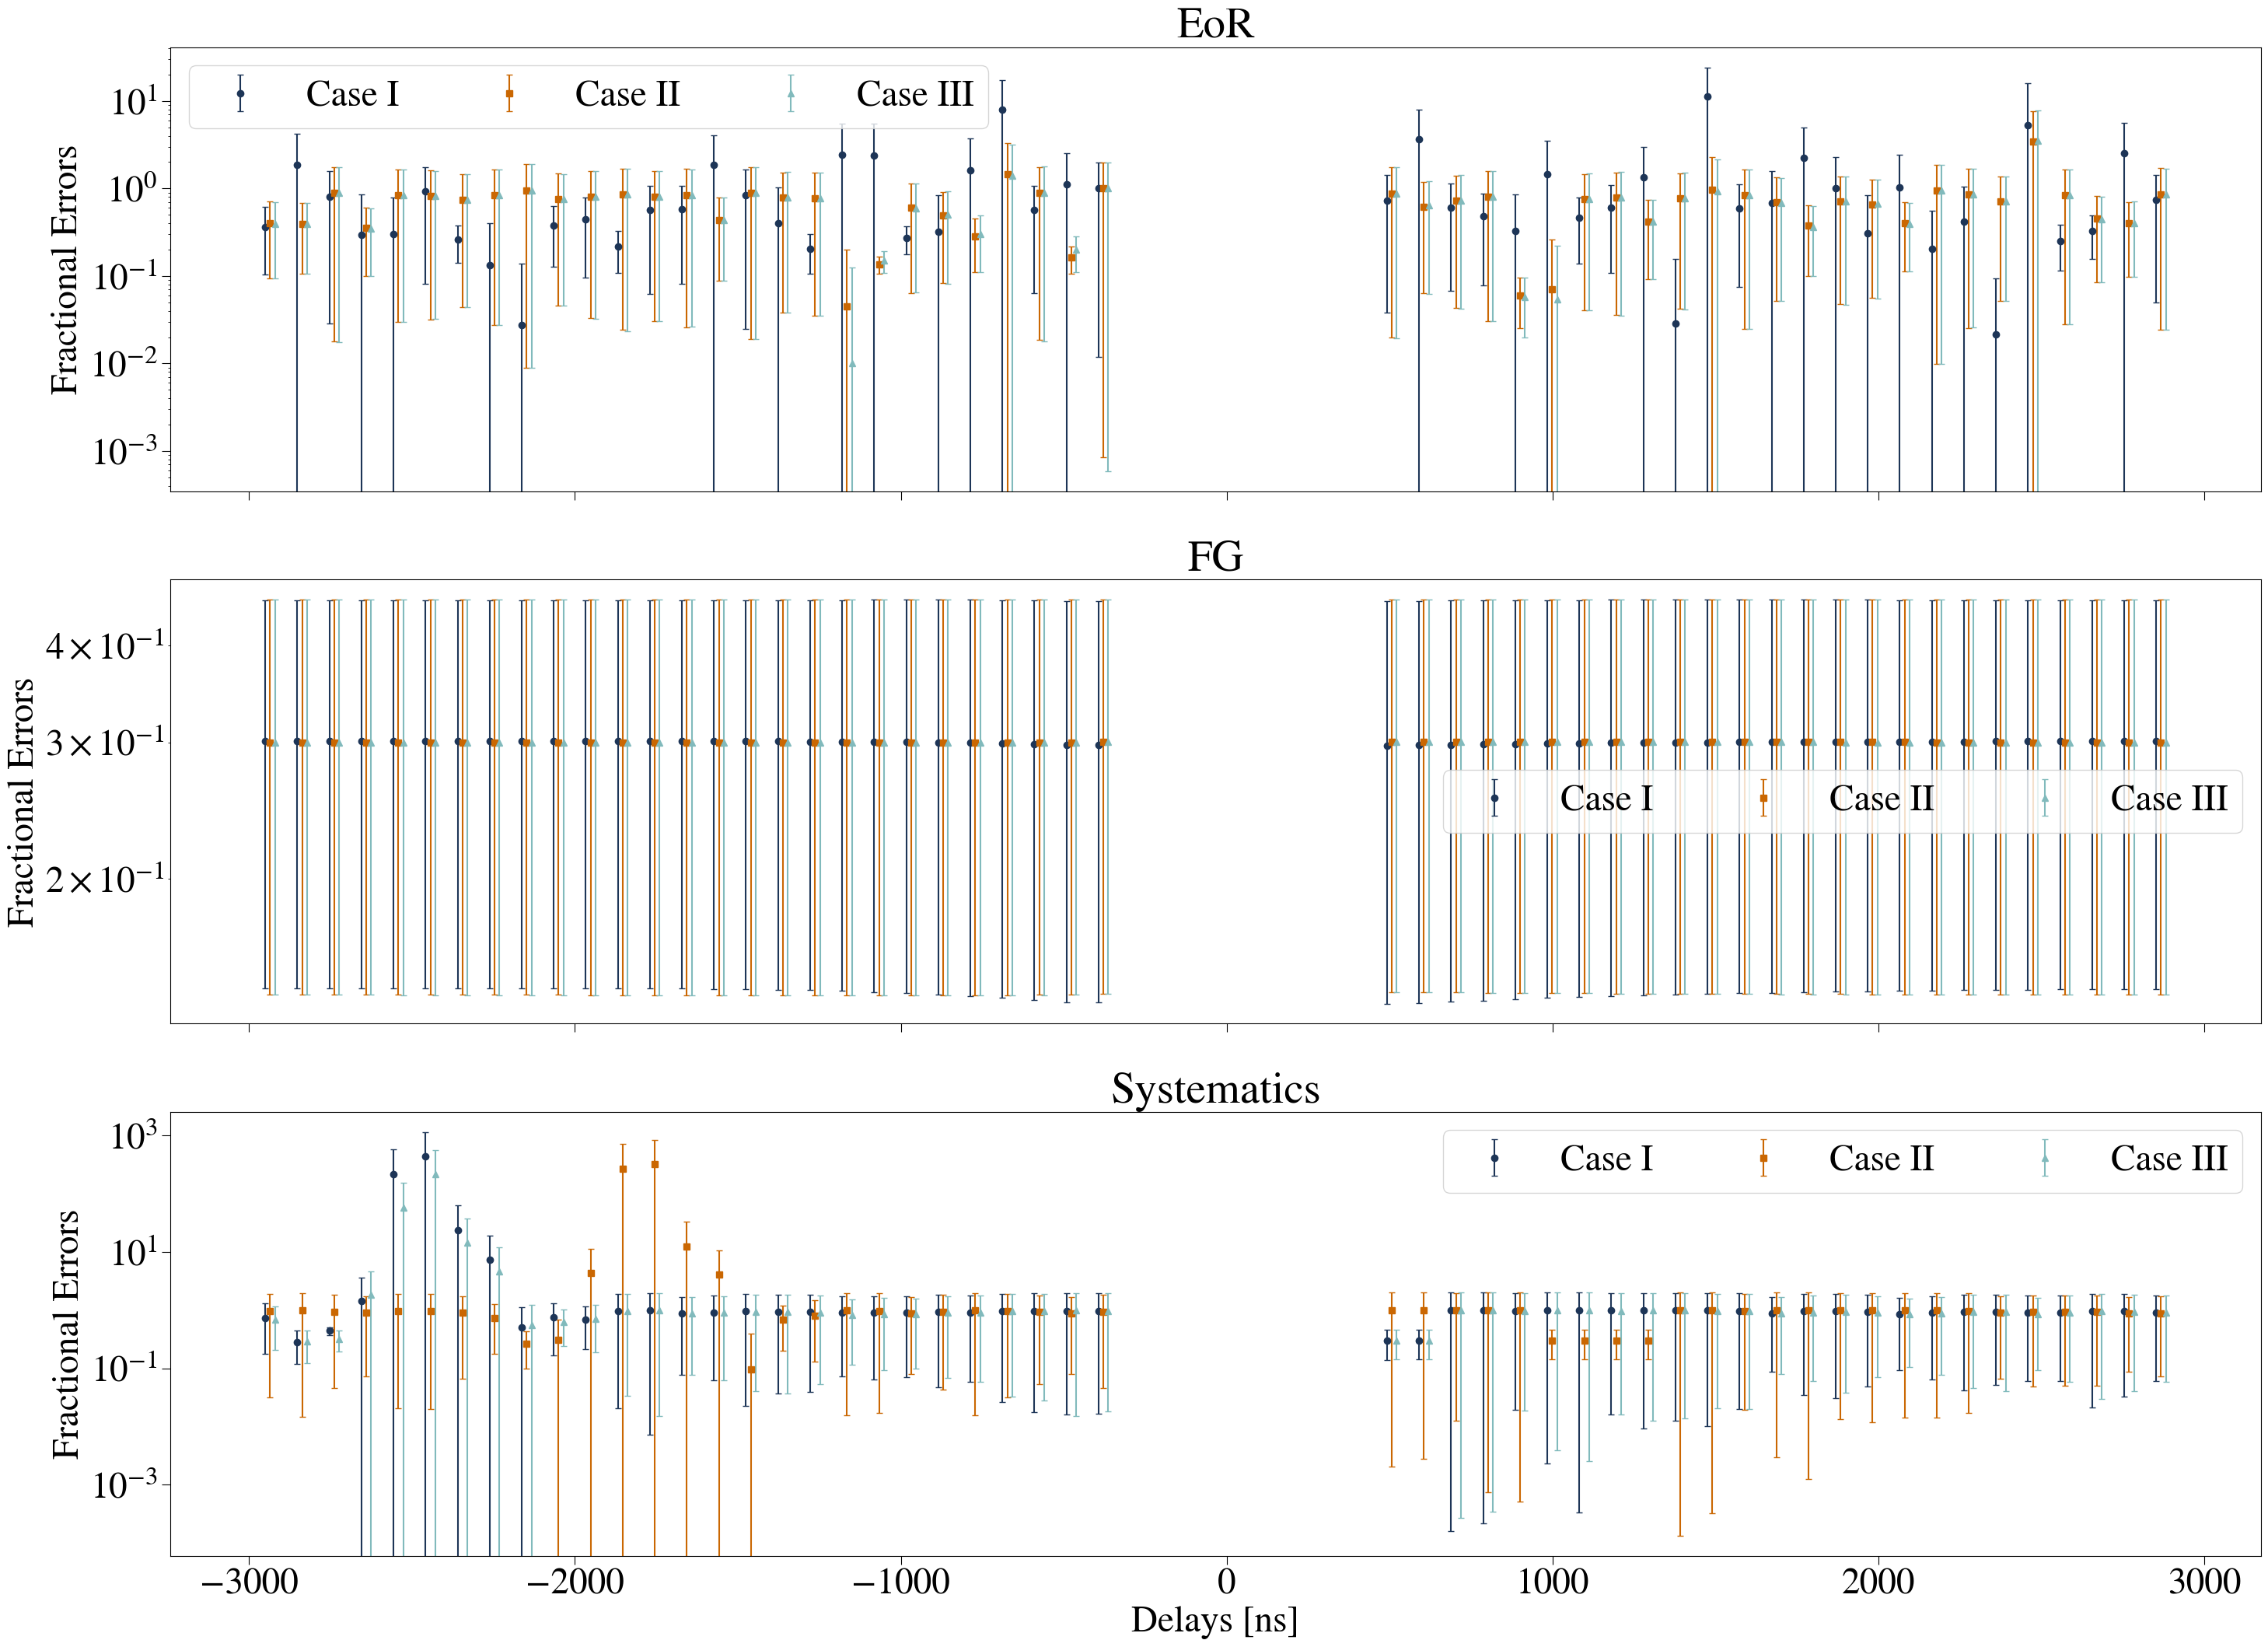

In [20]:
# Rows: EoR  |  Foregrounds  |  Systematics
# Each row shows all three cases on the same axes.

component_labels = ['EoR', 'FG', 'Systematics']
case_labels_err  = ['Case I', 'Case II', 'Case III']
markers          = ['o', 's', '^']

rm   = np.arange(27, 35)
keep = np.ones(Nfreqs, dtype=bool)
keep[rm] = False

# ── Load per-case DPS data ────────────────────────────────────────────────────
ps_sample_all      = []
ps_fg_all          = []
ps_sys_all         = []
eor_pspec_true_all = []
fg_pspec_true_all  = []
sys_pspec_true_all = []

for case_i, run_ver in enumerate(run_version_arr):
    op_i             = sys_modes(freqs_Hz=freqs * 1e6, times_sec=lsts * 24. / (2. * np.pi) * 3600., modes=nm_list_arr[case_i])
    fg_true_i        = np.load(result_dir + run_ver + '/fg_true.npy')
    fgmodes_i        = np.load(result_dir + run_ver + '/fgmodes.npy')
    fg_amps_i        = np.load(result_dir + run_ver + '/fg-amps.npy')
    eor_true_i       = np.load(result_dir + run_ver + '/eor_true.npy')
    b_sys_i          = np.load(result_dir + run_ver + '/b-sys.npy')
    sys_model_true_i = np.load(result_dir + run_ver + '/gain_true.npy')
    ps_sample_i      = np.load(result_dir + run_ver + '/dps-eor.npy')

    ps_fg_i  = np.empty(ps_sample_i.shape)
    ps_sys_i = np.empty(ps_sample_i.shape)
    for j in tqdm(range(Niter)):
        sys_model_j = (op_i @ b_sys_i[j]).reshape([Nfreqs, Ntimes]).T
        ps_fg_i[j]  = calc_ps((fgmodes_i[:, :Nfgmodes] @ fg_amps_i[j].T).T)
        ps_sys_i[j] = calc_ps(1 + sys_model_j)

    ps_sample_all.append(ps_sample_i)
    ps_fg_all.append(ps_fg_i)
    ps_sys_all.append(ps_sys_i)
    eor_pspec_true_all.append(calc_ps(eor_true_i[:Ntimes, :Nfreqs]))
    fg_pspec_true_all.append(calc_ps(fg_true_i[:Ntimes, :Nfreqs]))
    sys_pspec_true_all.append(calc_ps(sys_model_true_i))

# ── Plot ──────────────────────────────────────────────────────────────────────
ps_all_by_comp = [ps_sample_all, ps_fg_all, ps_sys_all]
ps_true_by_comp = [eor_pspec_true_all, fg_pspec_true_all, sys_pspec_true_all]

fig7v2, axs7v2 = plt.subplots(3, 1, figsize=(30, 22), sharex=True)

for row, comp in enumerate(component_labels):
    ax = axs7v2[row]
    # ax.plot(delays, np.abs(n_pspec), ls='-.', c=colors[-1], lw=2, label='Noise')

    for case_i in range(3):
        pspec_true_c = ps_true_by_comp[row][case_i]
        ps_samples_c = ps_all_by_comp[row][case_i]
        errs_c = (pspec_true_c - ps_samples_c) / pspec_true_c
        pa     = errs_c.mean(axis=0)[keep]
        std    = np.std(np.abs(errs_c), axis=0)[keep]
        errs   = np.vstack((pa - std, std - pa))
        ax.errorbar(
            delays[keep].value + (case_i * 15), np.abs(pa), yerr=np.abs(errs),
            fmt=markers[case_i], color=colors[case_i], label=case_labels_err[case_i],
            capsize=3, elinewidth=1.5,
        )

    ax.set_yscale('log')
    ax.set_ylabel('Fractional Errors')
    # ax.yaxis.set_major_formatter(FormatStrFormatter('%.1e'))
    ax.set_title(comp)
    ax.legend(ncol=4)
    ax.tick_params(length=8)

axs7v2[-1].set_xlabel('Delays [ns]')
fig7v2.tight_layout()
# plt.savefig(fig_dir + '/errors_components_v2.pdf', bbox_inches='tight', dpi=300)

---
# Figure 8: Corner plot of b_sys (single case)

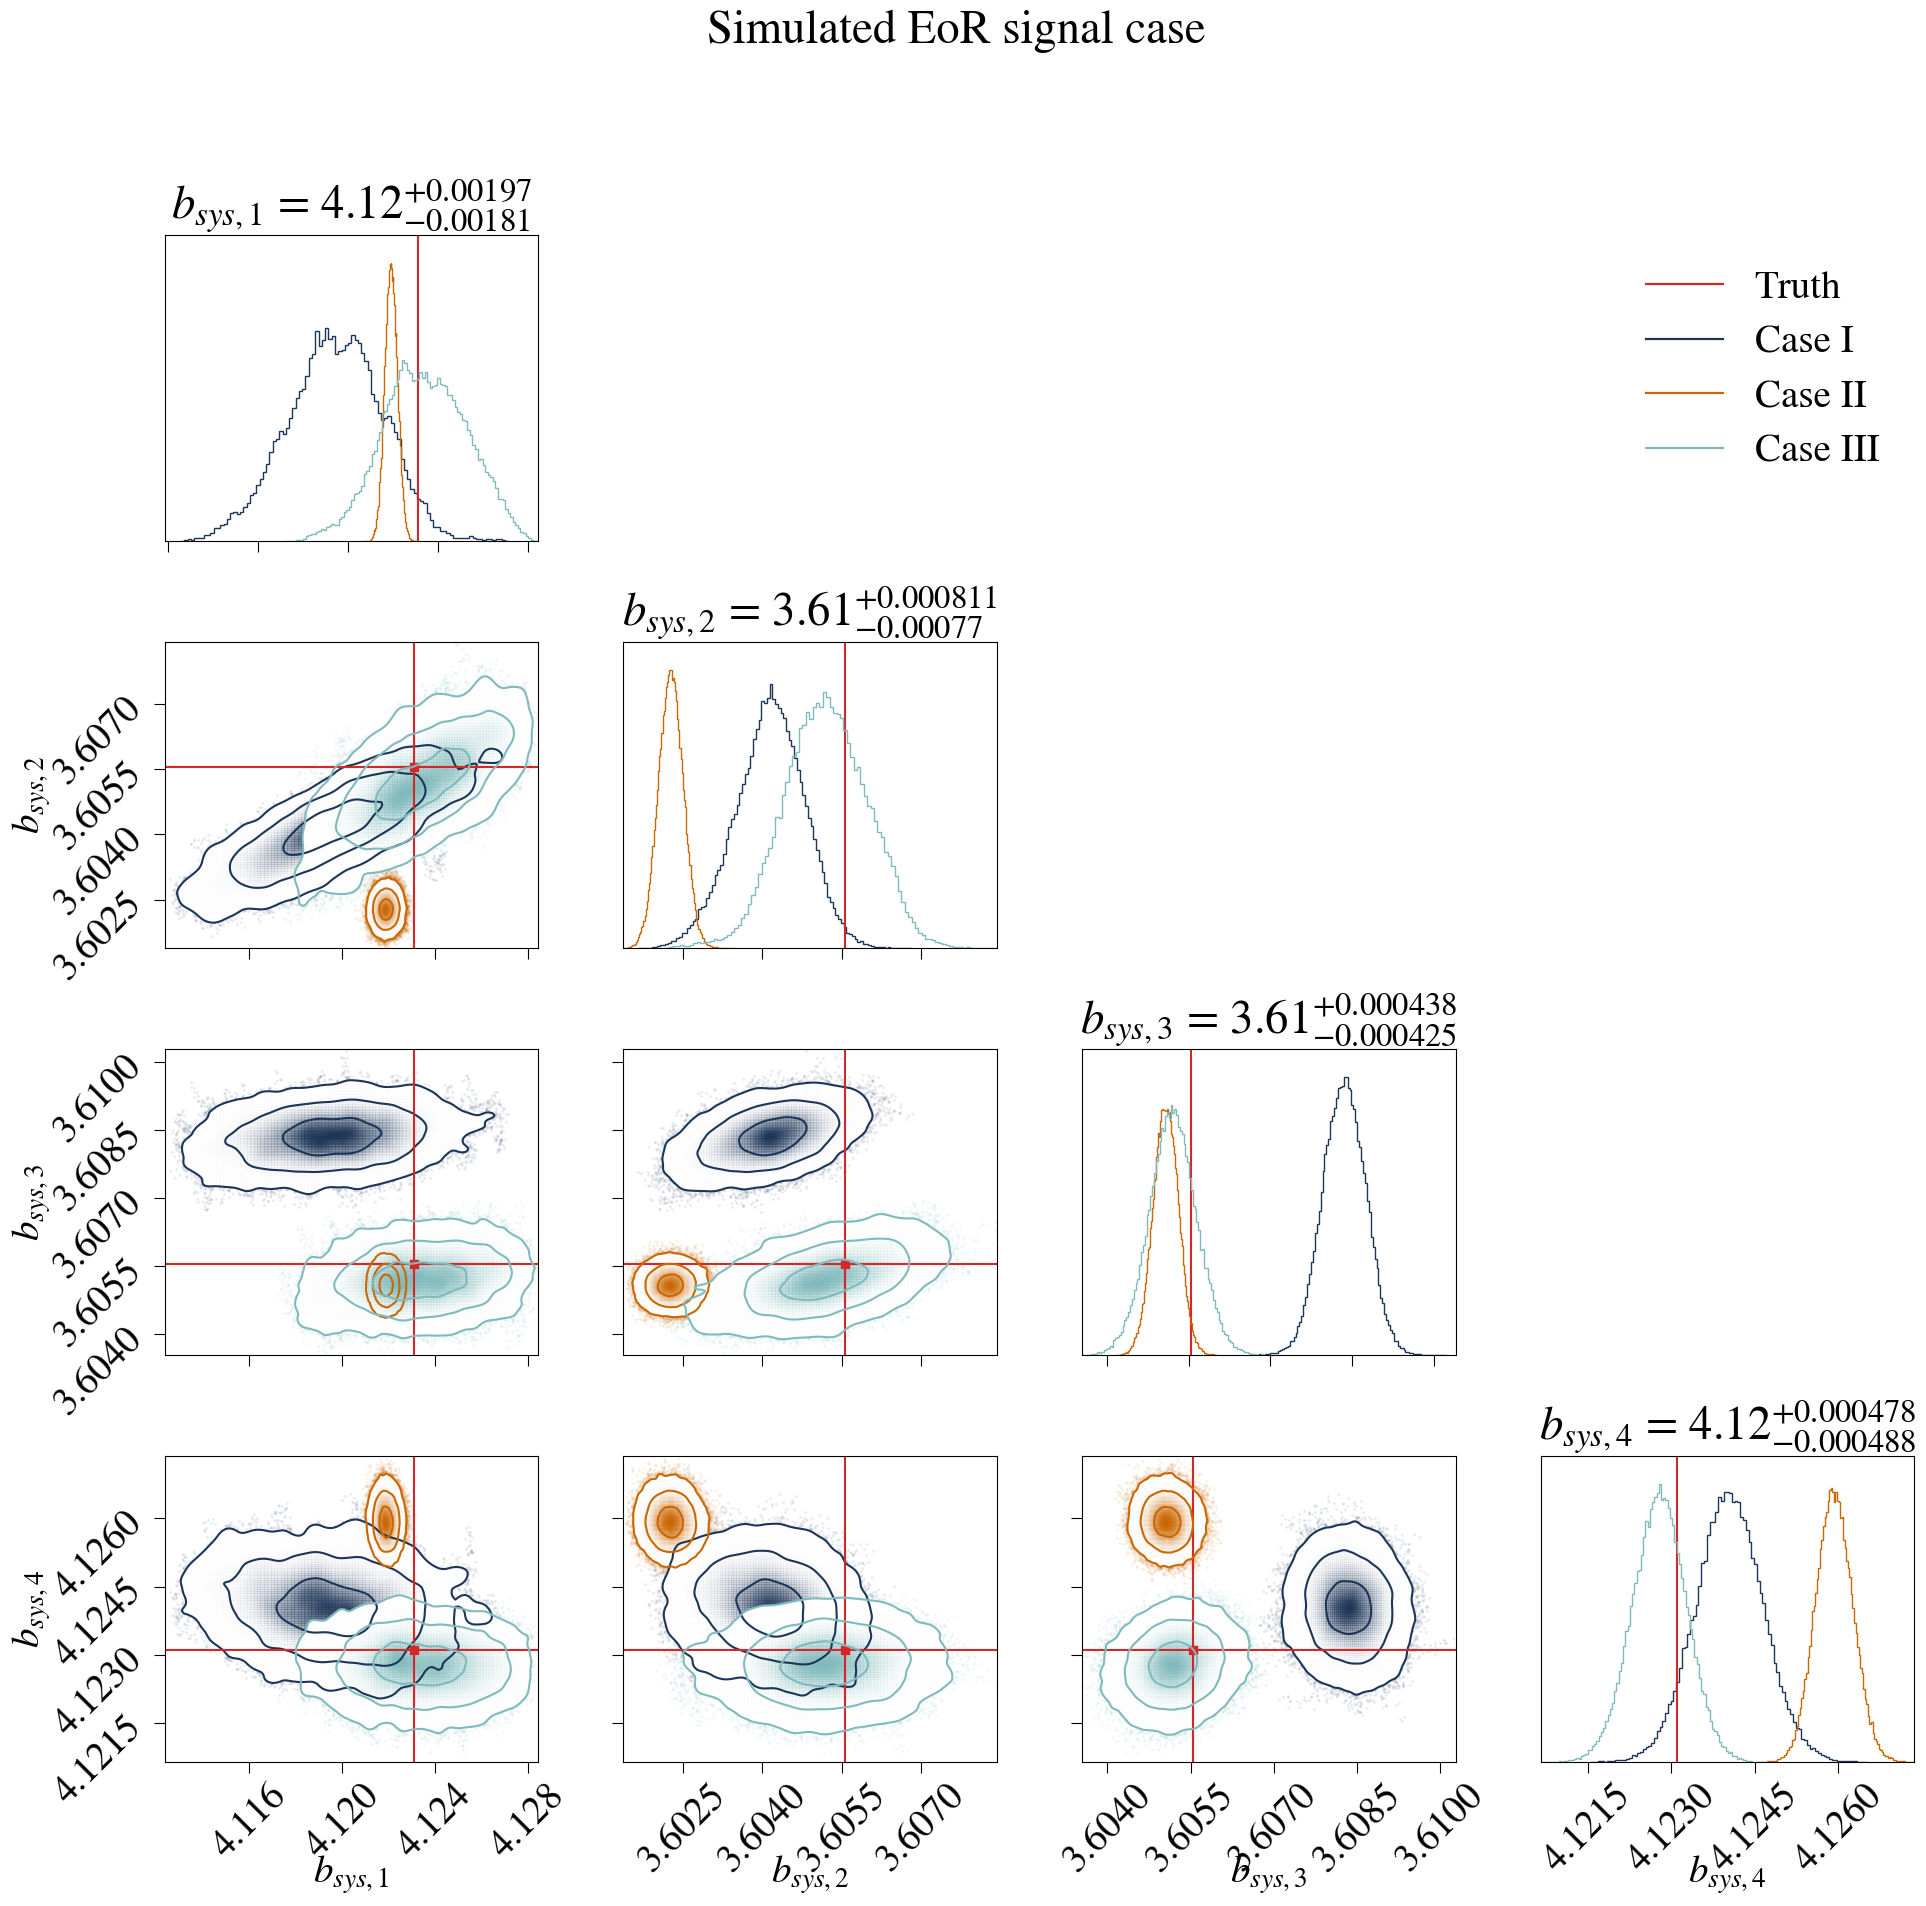

In [43]:
fig, ax = plt.subplots(4, 4, figsize=(20, 20))
plt.rcParams['font.size']=28

for a in ax.flatten():
    a.tick_params(length=8)

i=0
case_labels = ['Case I', 'Case II', 'Case III']
for run_ver in run_version_arr:
    b_sys_i = np.load(result_dir + run_ver + '/b-sys.npy')
    corner_plot(
        np.abs(b_sys_i),
        truths=np.abs(sys_amps_true) if i==0 else None,
        labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'],
        color=colors[i],
        fig=fig,
        nsigma=3,
        title = 'Simulated EoR signal case',
        case_label=case_labels[i]
    )
    i=i+1
plt.savefig(fig_dir + '/bsys_corner_plot.pdf', bbox_inches='tight', dpi=300)

---
# Figure 9: Systematics fractional error (single case)

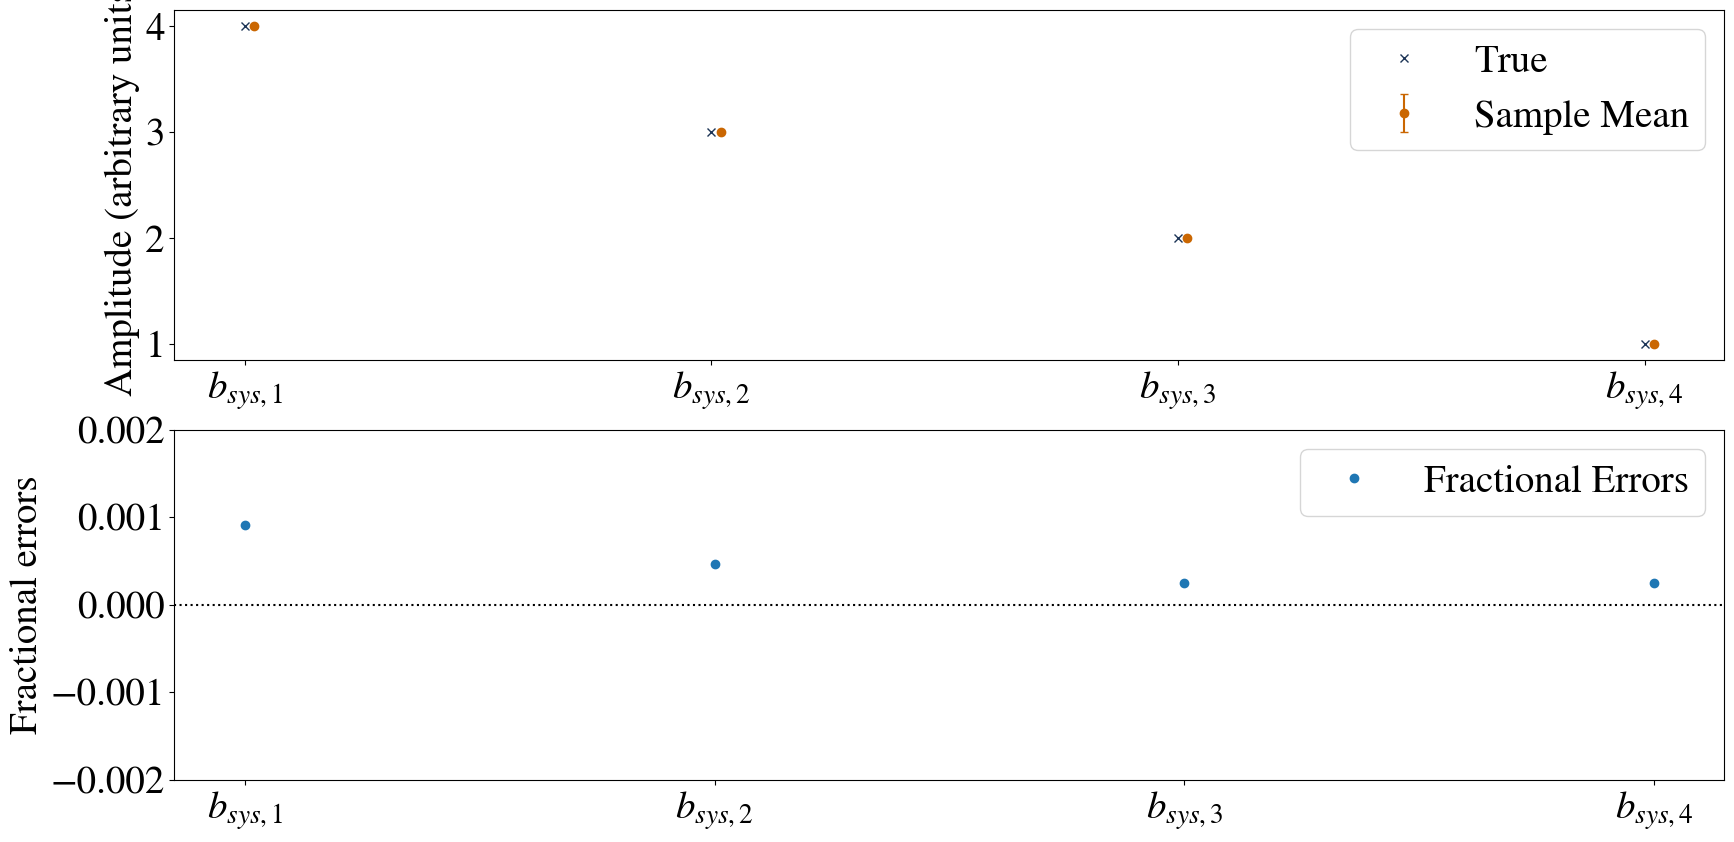

In [22]:
fig, ax = plt.subplots(2, 1, figsize=(20, 10))

errs = np.vstack((
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
    np.imag(3 * np.std(b_sys_gcr, axis=0)),
))

ax[0].plot(np.imag(sys_amps_true), 'x', c=colors[0], label='True')
ax[0].errorbar(
    [0.02, 1.02, 2.02, 3.02], np.imag(b_sys_gcr.mean(axis=0)),
    fmt='o', yerr=errs, label='Sample Mean', capsize=3, c=colors[1],
)
ax[0].set_ylabel('Amplitude (arbitrary units)')
ax[0].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[0].legend()

res_mean = np.abs(sys_amps_true - b_sys_gcr.mean(axis=0)) / np.abs(sys_amps_true)
ax[1].plot([0, 1, 2, 3], res_mean, 'o', label='Fractional Errors')
ax[1].set_xticks([0, 1, 2, 3], labels=[r'$b_{sys,1}$', r'$b_{sys,2}$', r'$b_{sys,3}$', r'$b_{sys,4}$'])
ax[1].axhline(0, c='k', ls='dotted')
ax[1].set_ylabel('Fractional errors')
ax[1].set_ylim(-0.002, 0.002)
ax[1].legend()
# plt.savefig(fig_dir + '/sys_frac_error.pdf', bbox_inches='tight', dpi=300)

---
# Figure 10: Delay power spectra (all cases)

0.5273862549695149
0.5067869337730068
0.5205466597591769


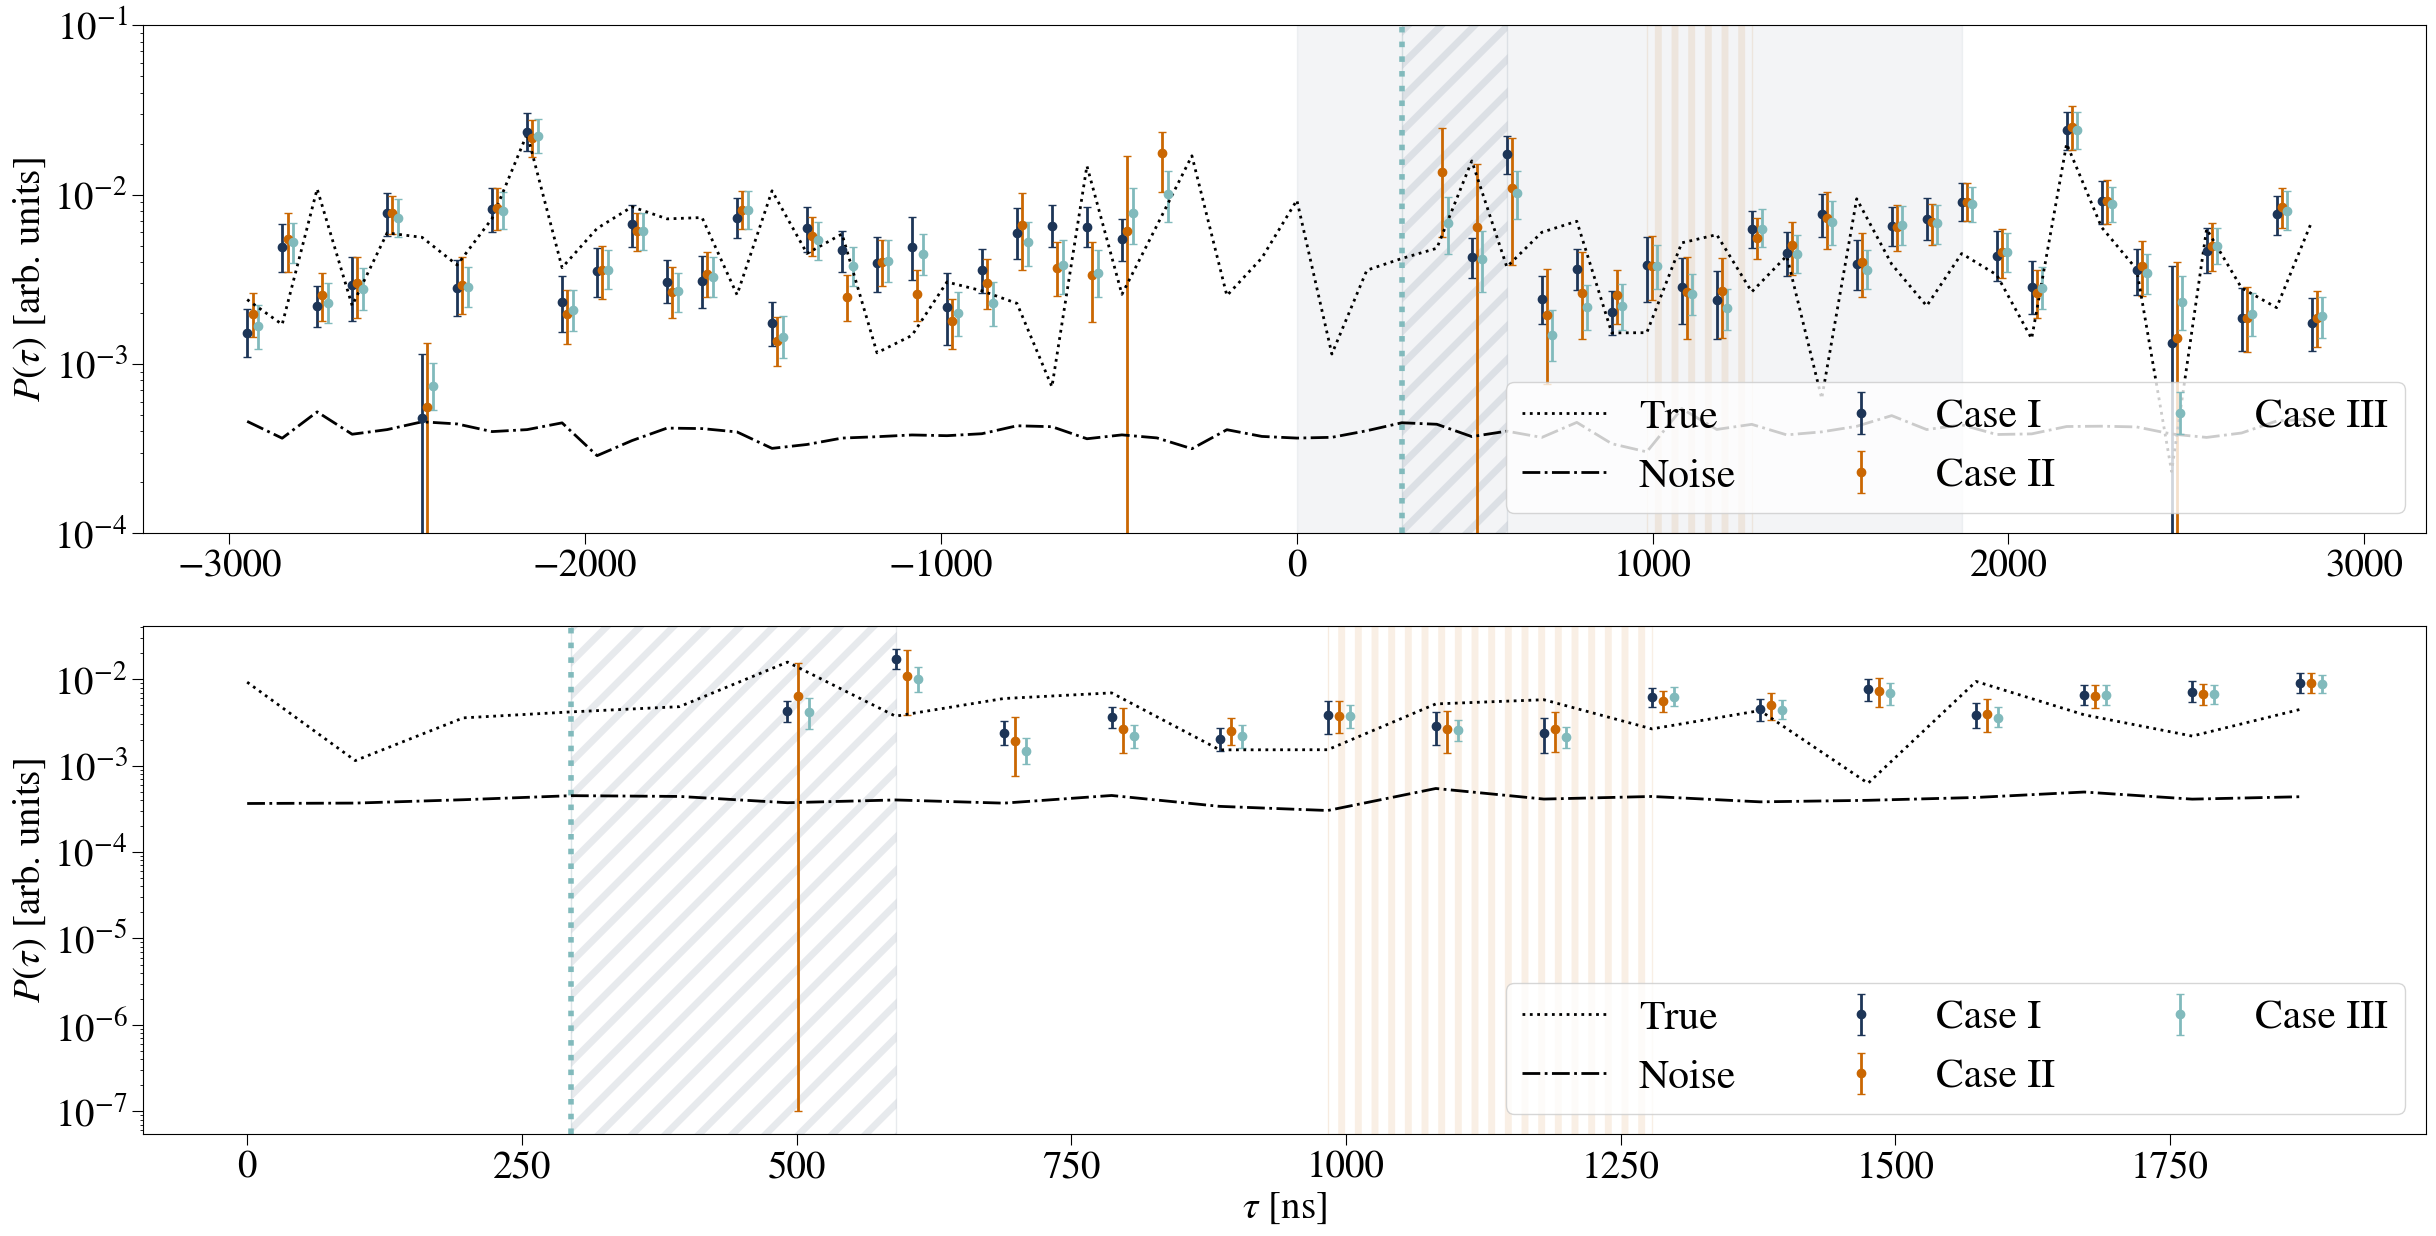

In [48]:
fig, ax = plt.subplots(2, 1, figsize=(25, 13))

fig_labels_dps = ['I', 'II', 'III']
hatches = ['/', '|', '.']

for i, run_version in enumerate(run_version_arr):
    eor_true_i = np.load(result_dir + run_version + '/eor_true.npy')
    ps_sample_i = np.load(result_dir + run_version + '/dps-eor.npy')
    ln_post_i   = np.load(result_dir + run_version + '/ln-post.npy')
    ps_true_i   = calc_ps(eor_true_i[:Ntimes, :Nfreqs])

    sys_delays = delays[np.unique(dl_inds[i]) + int(Nfreqs / 2)].value

    if Nburn > 0:
        ps_sample_i = ps_sample_i[Nburn:]
        ln_post_i   = ln_post_i[Nburn:]

    dps_pwm    = np.average(ps_sample_i, weights=ln_post_i, axis=0)
    percentile = conf_interval / 2 + 50
    dps_ubound = np.percentile(ps_sample_i, percentile,       axis=0)
    dps_lbound = np.percentile(ps_sample_i, 100 - percentile, axis=0)
    dps_err    = np.vstack((dps_pwm - dps_lbound, dps_ubound - dps_pwm))

    ax[0].errorbar(
        delays.value + i * 15, dps_pwm, yerr=np.abs(dps_err),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )

    x0, x1 = np.min(sys_delays), np.max(sys_delays)
    ax[0].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)
    ax[1].axvspan(x0, x1, facecolor='none', ec=colors[i], hatch=hatches[i], hatch_linewidth=5, alpha=0.1, zorder=0.1)

    if i == 2:
        for dl in sys_delays:
            ax[0].axvline(dl, ls='dotted', c=colors[i], lw=4)
            ax[1].axvline(dl, ls='dotted', c=colors[i], lw=4)

    ax[1].errorbar(
        delays[35:50].value + i * 10, dps_pwm[35:50], yerr=np.abs(dps_err[:, 35:50]),
        color=colors[i], ls='', marker='o', elinewidth=2, capsize=3, label='Case ' + fig_labels_dps[i],
    )
    print(np.mean((dps_pwm - ps_true_i) / ps_true_i))

ps_true_ref = calc_ps(np.load(result_dir + run_version_arr[0] + '/eor_true.npy')[:Ntimes, :Nfreqs])

ax[1].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[1].set_xlabel(r'$\tau$ [ns]')
ax[1].axhline(0, ls='dotted')
ax[1].plot(delays[30:50], ps_true_ref[30:50], 'k:', label='True', lw=2)
ax[1].plot(delays[30:50], calc_ps(n.T)[30:50], 'k', ls='-.', label='Noise', lw=2)
ax[1].legend(loc='lower right', ncol=3, fontsize=30)
ax[1].set_yscale('log')

ax[0].plot(delays, ps_true_ref, 'k:', label='True', lw=2)
ax[0].plot(delays, calc_ps(n.T), 'k', ls='-.', label='Noise', lw=2)
ax[0].legend(loc='lower right', ncol=3, fontsize=30)
ax[0].set_ylabel(r'$P(\tau)$ [arb. units]')
ax[0].set_ylim(1e-4, 1e-1)
ax[0].set_yscale('log')
ax[0].axvspan(delays[30].value, delays[49].value, facecolor=colors[0], ec=colors[0],alpha=0.05, zorder=0.1)

for a in ax.flatten():
    a.tick_params(length=8)
fig.tight_layout()
# plt.savefig(fig_dir + '/delay_power_spectrum_combined.pdf', bbox_inches='tight', dpi=300)

---
# Table 1: ESS and autocorrelation time

In [209]:
for run_version in run_version_arr:
    print('Case:', run_version)
    b_sys = np.load(result_dir + run_version + '/b-sys.npy')
    taus  = emcee.autocorr.integrated_time(b_sys, c=5, tol=50, quiet=True, has_walkers=False)
    ess   = Niter / taus
    print('\n Taus: {}\nEss:{}\n'.format(taus, ess))

Case: low_dl_fr_0

 Taus: [1361.51841081 1249.19769461  134.56632369  135.65157452]
Ess:[ 73.44740931  80.05138052 743.12797777 737.18274451]

Case: high_dl_fr_0

 Taus: [22.32236011 15.9370257  14.24851621 28.16567808]
Ess:[4479.81304331 6274.69653743 7018.27464424 3550.42046914]

Case: low_dl_fr_20

 Taus: [1145.53698538  850.8362266   300.8949841    74.16686239]
Ess:[  87.29530454  117.53143187  332.34186438 1348.31104861]



---
# Figure 11: FG–systematics correlation (all cases)

In [220]:
yticklocs_fr

[np.int64(20), np.int64(61), np.int64(102), np.int64(142), np.int64(183)]

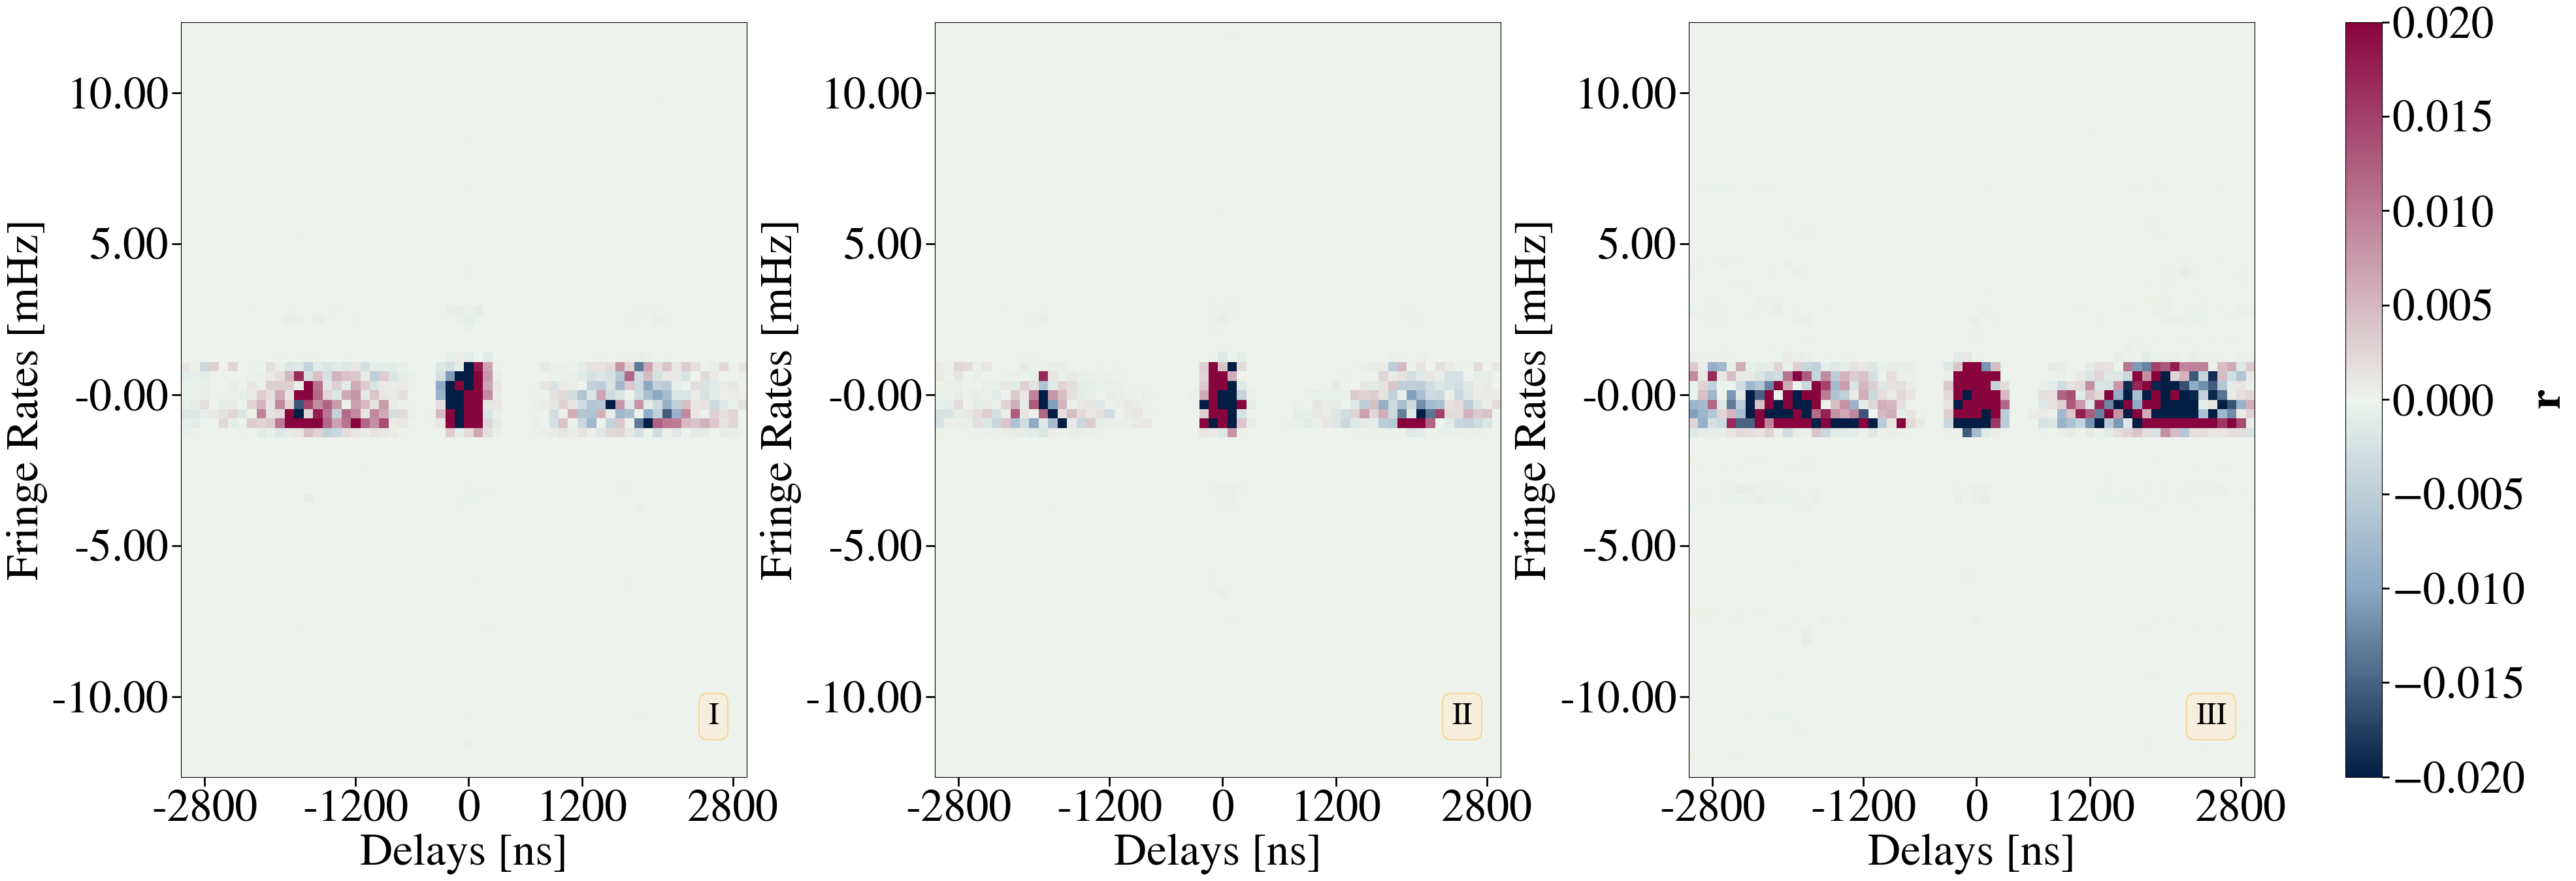

In [224]:
fig = plt.figure(figsize=(45, 15))
axs = ImageGrid(
    fig, 111,
    nrows_ncols=(1, 3),
    axes_pad=0.5,
    share_all=True,
    label_mode='all',
    cbar_location='right',
    cbar_mode='single',
    cbar_size='5%',
    cbar_pad=0.2,
    aspect=False,
)

fig_labels_corr = ['I', 'II', 'III']
for i in range(3):
    im = axs[i].imshow(corr_maps[i][::-1, :].real, cmap=paper_map, origin='lower', vmin=-0.02, vmax=0.02)
    axs[i].text(0.95, 0.07, fig_labels_corr[i], bbox=bbox,
                transform=axs[i].transAxes, horizontalalignment='right')

cbar = axs.cbar_axes[0].colorbar(im)
cbar.set_label(r'$\mathbf{r}$', size=50)
cbar.ax.tick_params(labelsize=50, length=8, width=2, colors='black')

for ax in axs:
    ax.set_xlabel('Delays [ns]', fontsize=50)
    ax.set_ylabel('Fringe Rates [mHz]', fontsize=50)
    ax.tick_params(direction='out', length=8, width=2, colors='black', size=10, labelsize=50)
    ax.set_xticks(xticklocs_dl, labels=xticklabels_dl)
    ax.set_yticks(yticklocs_fr, labels=yticklabels_fr)

plt.savefig(fig_dir + '/fg_sys_corr.pdf', bbox_inches='tight', dpi=300)

# Correlation matrix

In [225]:
eor_gcr_flat = np.abs(eor_gcr[:Niter,-3,:]).reshape(Niter, -1)  # (10000, 4800)
fg_gcr_flat = np.abs(fg_amps_gcr[:Niter,-3,:]).reshape(Niter, -1)  # (10000, 4800)
samples_all = np.concatenate([eor_gcr_flat,fg_gcr_flat, np.abs(b_sys_gcr)], axis=1)  # (10000, 4816)

In [226]:
cov_samples = np.cov(samples_all, rowvar=False)  # (4816, 4816)
corr_samples = np.corrcoef(samples_all, rowvar=False)  # (4816

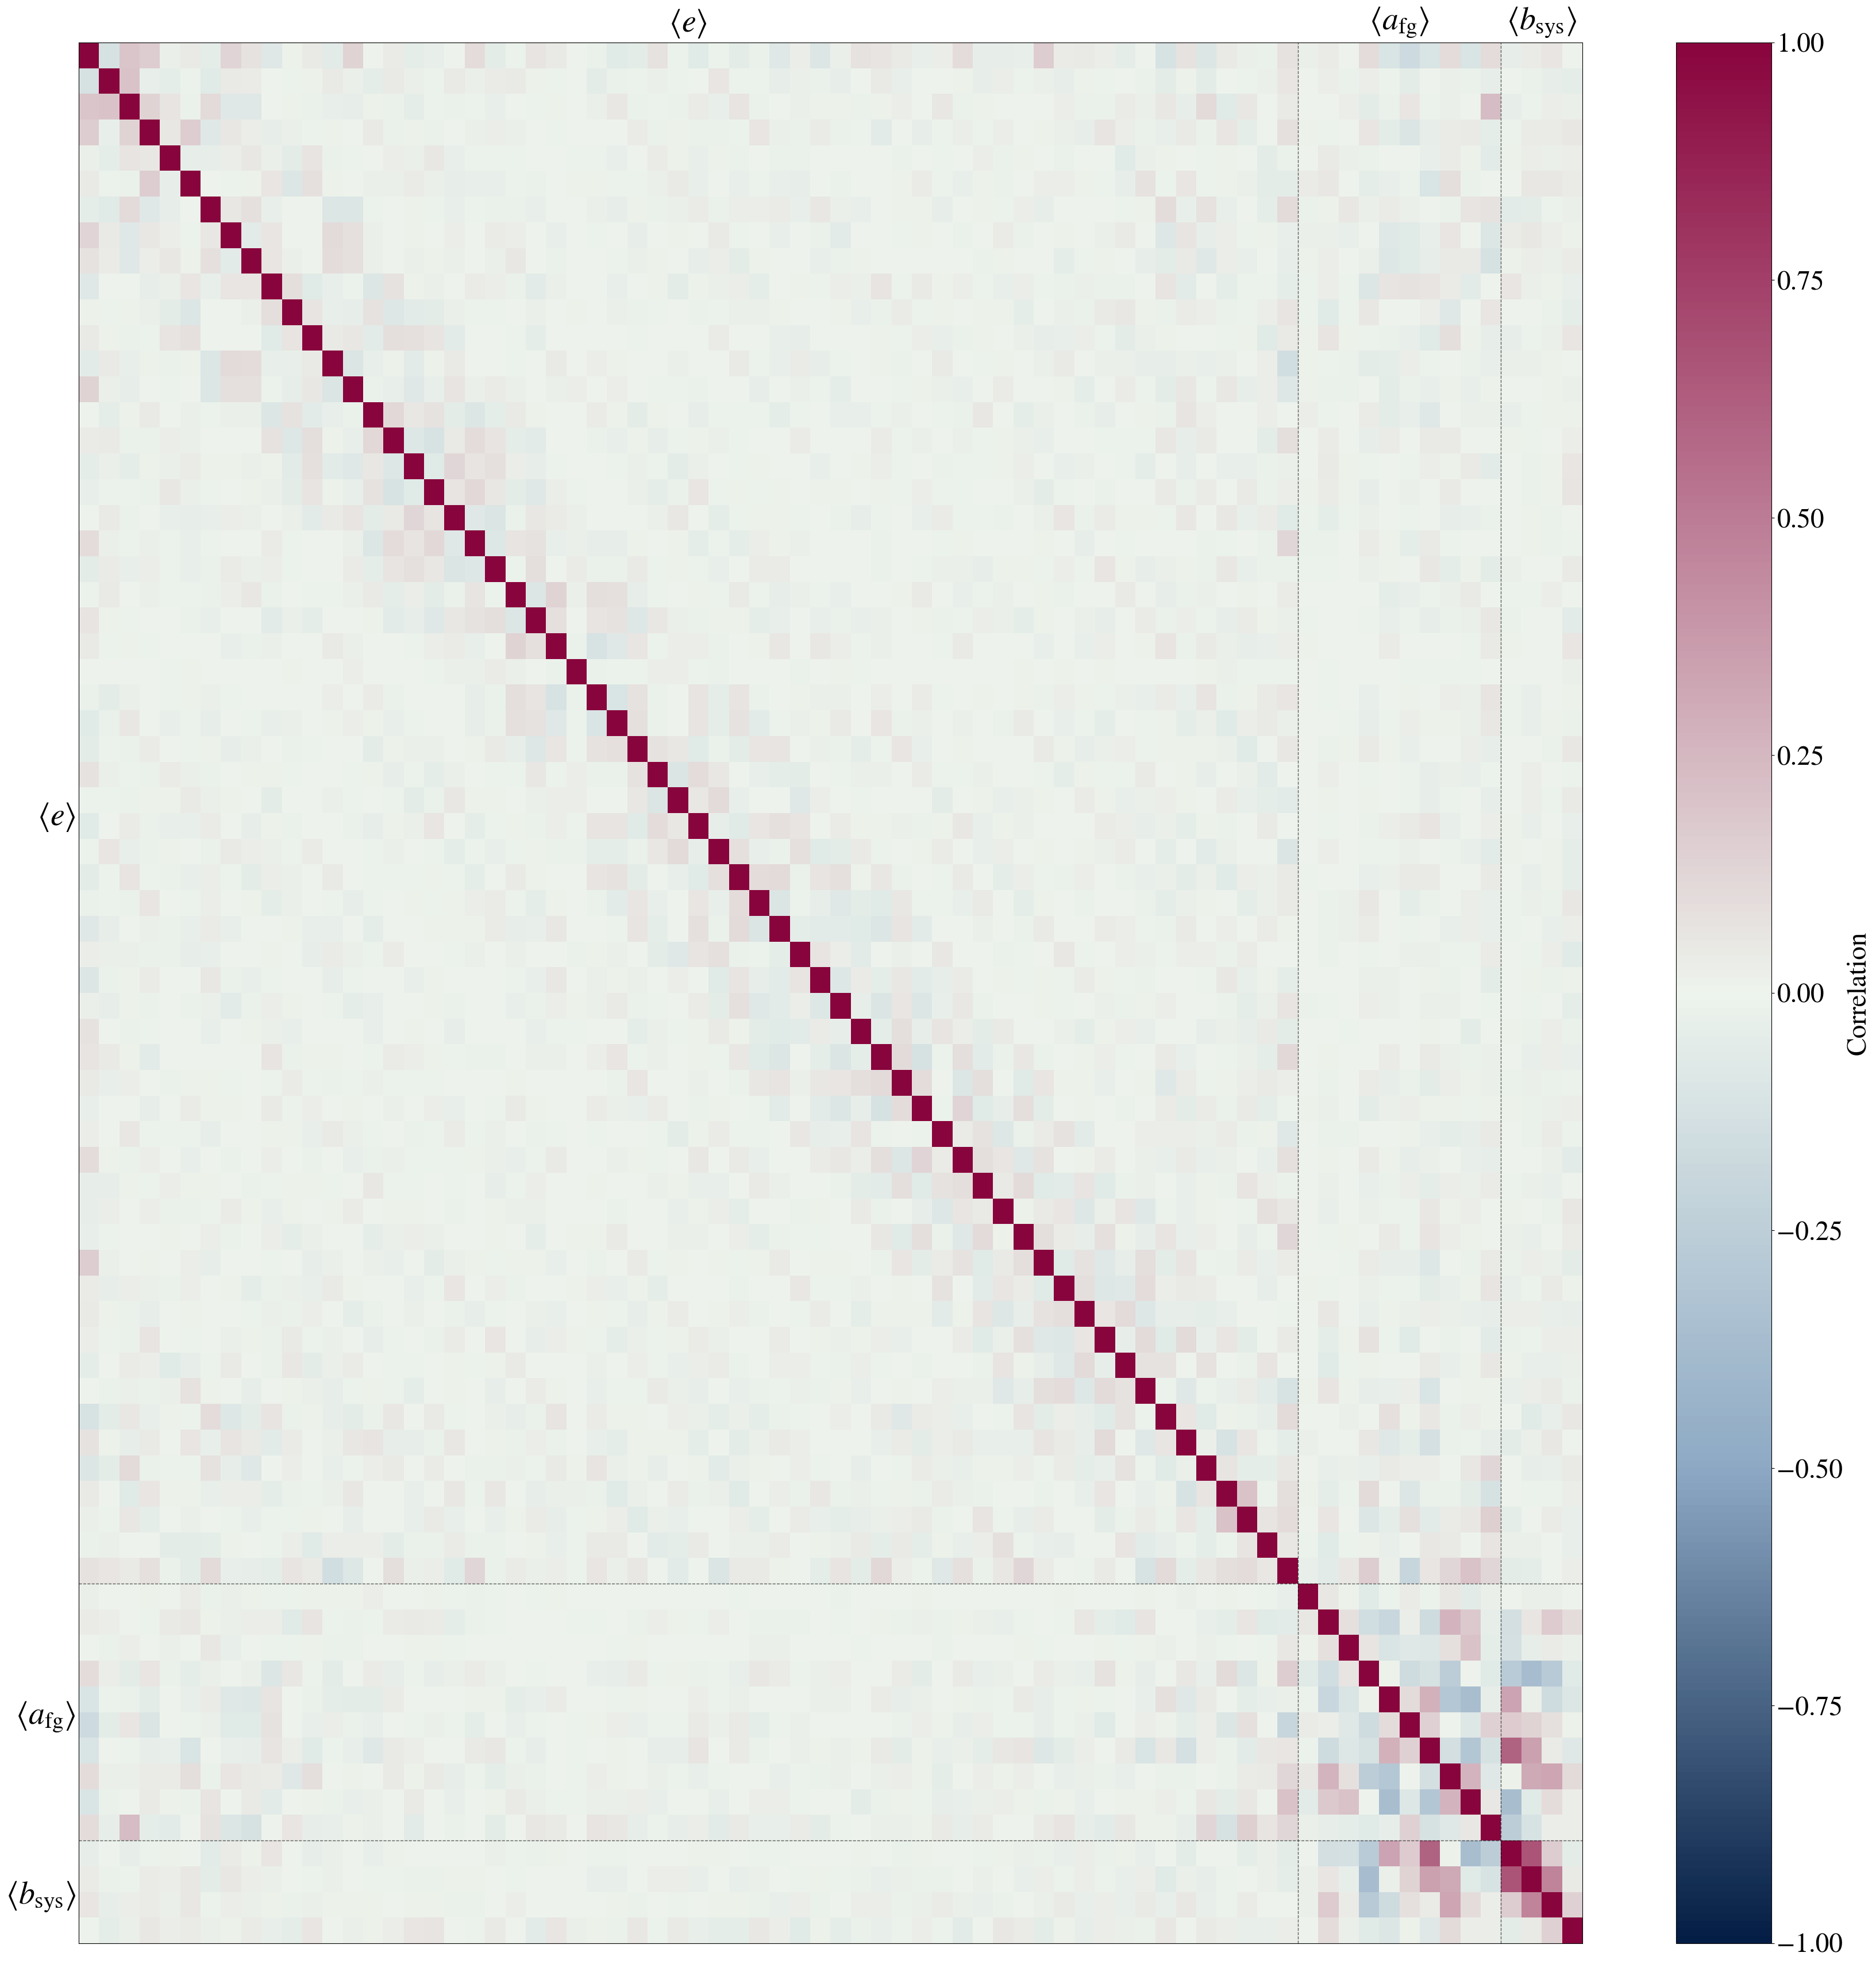

In [ ]:
import matplotlib.ticker as ticker
from matplotlib.patches import ConnectionPatch

def plot_correlation_matrix(corr, param_names, param_sizes, fontsize=40, cmap="RdBu", figsize=(8, 7)):
    """
    Plot a formatted correlation matrix with block labels and dividing lines.

    Parameters
    ----------
    corr : np.ndarray, shape (N, N)
        Correlation matrix.
    param_names : list of str
        Parameter block names, e.g. ['EoR', 'Foregrounds', 'Systematics'].
    param_sizes : list of int
        Number of elements per parameter block, e.g. [4800, 12, 4].
    cmap : str
        Colormap. Default 'RdBu_r'.
    figsize : tuple
        Figure size.
    """
    fig, ax = plt.subplots(figsize=figsize)

    im = ax.matshow(corr, cmap=cmap, vmin=-1, vmax=1, aspect="auto", interpolation="none")
    plt.colorbar(im, ax=ax, label="Correlation")

    # --- Block dividing lines ---
    boundaries = np.cumsum(param_sizes)[:-1] - 0.5
    for b in boundaries:
        ax.axhline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)
        ax.axvline(b, color="k", linewidth=1.0, linestyle="--", alpha=0.6)

    # --- Block centre positions for labels ---
    centres = []
    start = 0
    for size in param_sizes:
        centres.append(start + size / 2 - 0.5)
        start += size

    # --- Bracket-style axis labels ---
    ax.set_xticks(centres)
    ax.set_yticks(centres)
    ax.set_xticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.set_yticklabels(
        [rf"$\langle {n} \rangle$" for n in param_names],
        fontsize=fontsize,
    )
    ax.tick_params(length=0)  # hide tick marks, keep labels

    # # --- Bracket lines on x-axis ---
    # for i, (centre, size) in enumerate(zip(centres, param_sizes)):
    #     lo = centre - size / 2 + 0.5
    #     hi = centre + size / 2 - 0.5
    #     # bottom bracket
    #     ax.annotate("", xy=(lo, 1.02), xycoords=("data", "axes fraction"),
    #                 xytext=(hi, 1.02), textcoords=("data", "axes fraction"),
    #                 arrowprops=dict(arrowstyle="-", color="k", lw=1.2,
    #                                connectionstyle="bar,fraction=0.15"))
    # --- Bracket lines on y-axis ---
    # for i, (centre, size) in enumerate(zip(centres, param_sizes)):
    #     lo = centre - size / 2 + 0.5
    #     hi = centre + size / 2 - 0.5
        # ax.annotate("", xy=(-0.02, lo), xycoords=("axes fraction", "data"),
        #             xytext=(-0.02, hi), textcoords=("axes fraction", "data"),
        #             arrowprops=dict(arrowstyle="-", color="k", lw=1.2,
        #                            connectionstyle="bar,fraction=0.15"))

    # ax.set_title("Parameter Correlation Matrix", fontsize=13, pad=14)
    fig.tight_layout()
    return fig, ax


# --- Usage ---
param_names = [r"e", r'a_\text{fg}', r'b_\text{sys}']
param_sizes = [60,10, 4]

fig, ax = plot_correlation_matrix(
    corr        = corr_samples.real,           # your (4816, 4816) correlation matrix
    param_names = param_names,
    param_sizes = param_sizes,
    cmap        = paper_map,       # see note below
    fontsize = 40,
    figsize     = (35, 35),
)
plt.savefig(fig_dir + '/correlation_matrix.pdf', bbox_inches='tight', dpi=300)

In [232]:
eor_gcr_flat = np.abs(eor_gcr[:Niter,:,20]).reshape(Niter, -1)  # (10000, 4800)
samples_all = np.concatenate([eor_gcr_flat,eor_gcr_flat], axis=1)  # (10000, 4816)
cov_samples = np.cov(samples_all, rowvar=False)  # (4816, 4816)
corr_samples = np.corrcoef(samples_all, rowvar=False)  # (4816

In [ ]:
freq_idx = 42  # pick your frequency channel

# Extract samples at that frequency: shape (Niter, Ntimes)
samples_f0 = eor_gcr[98000, 0, :]  # (Niter, Ntimes)
samples_f1 = eor_gcr[98000, 1, :]  # (Niter, Ntimes)

# Compute correlation matrix: (Ntimes, Ntimes)
# np.corrcoef expects shape (variables, observations) so transpose
corr = np.corrcoef(samples_f0, samples_f1)  # (Ntimes, Ntimes)

fig, ax = plt.subplots(figsize=(40, 40))
im = ax.imshow(corr.real, vmin=-1, vmax=1, cmap='RdBu_r', origin='upper')
fig.colorbar(im, ax=ax, label='Pearson correlation')
ax.set_xlabel('Time index')
ax.set_ylabel('Time index')
ax.set_title(f'Time-time correlation at freq idx {freq_idx}')
plt.tight_layout()

# Log probability plot

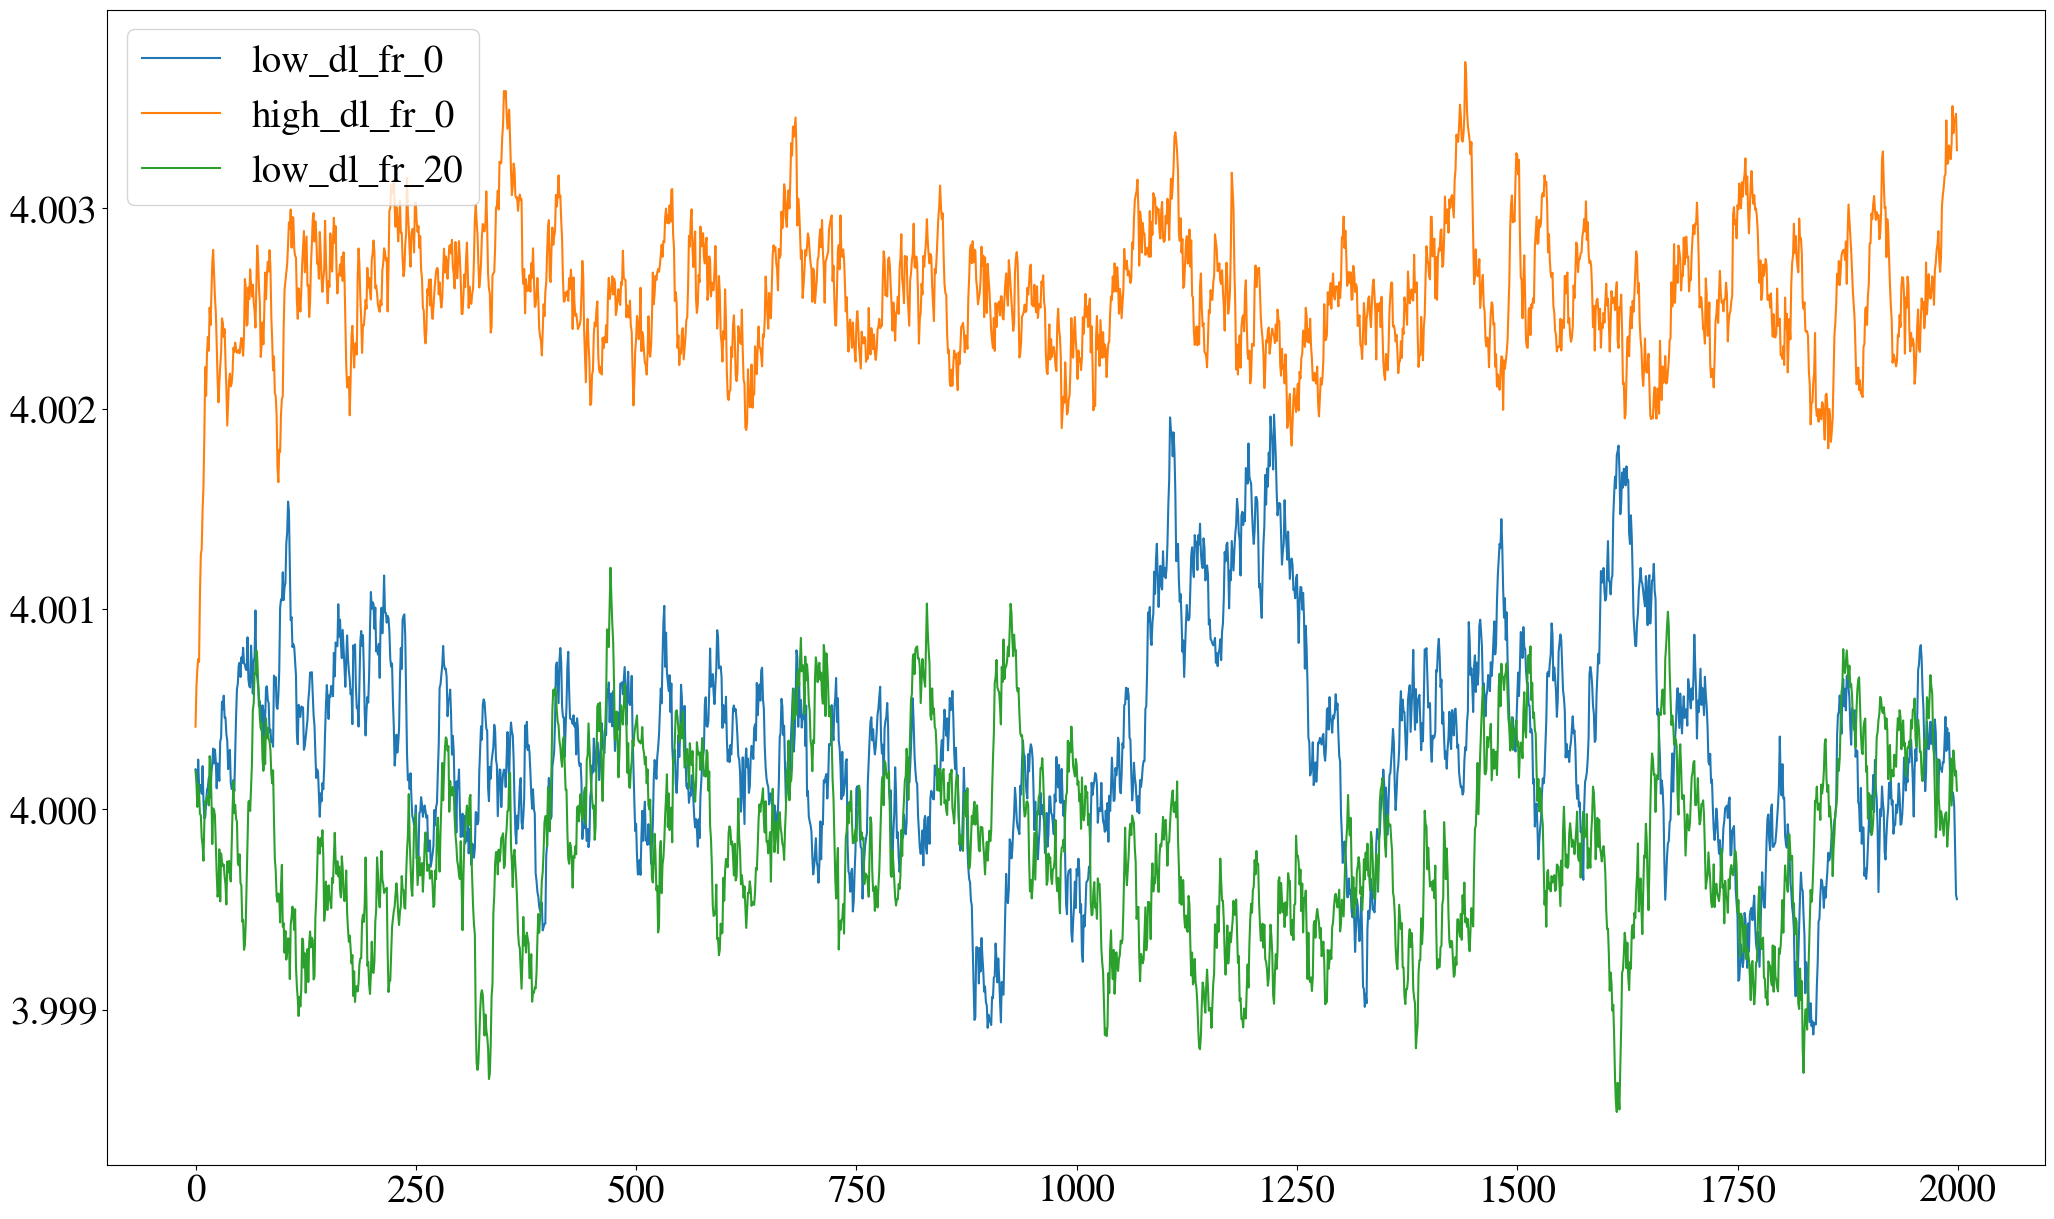

In [26]:
plt.figure(figsize=(25, 15))
for run_ver in run_version_arr:
    b_sys_i          = np.load(result_dir + run_ver + '/b-sys.npy')
    plt.plot(b_sys_i[:2000, 3].real, label=run_ver)
plt.legend()

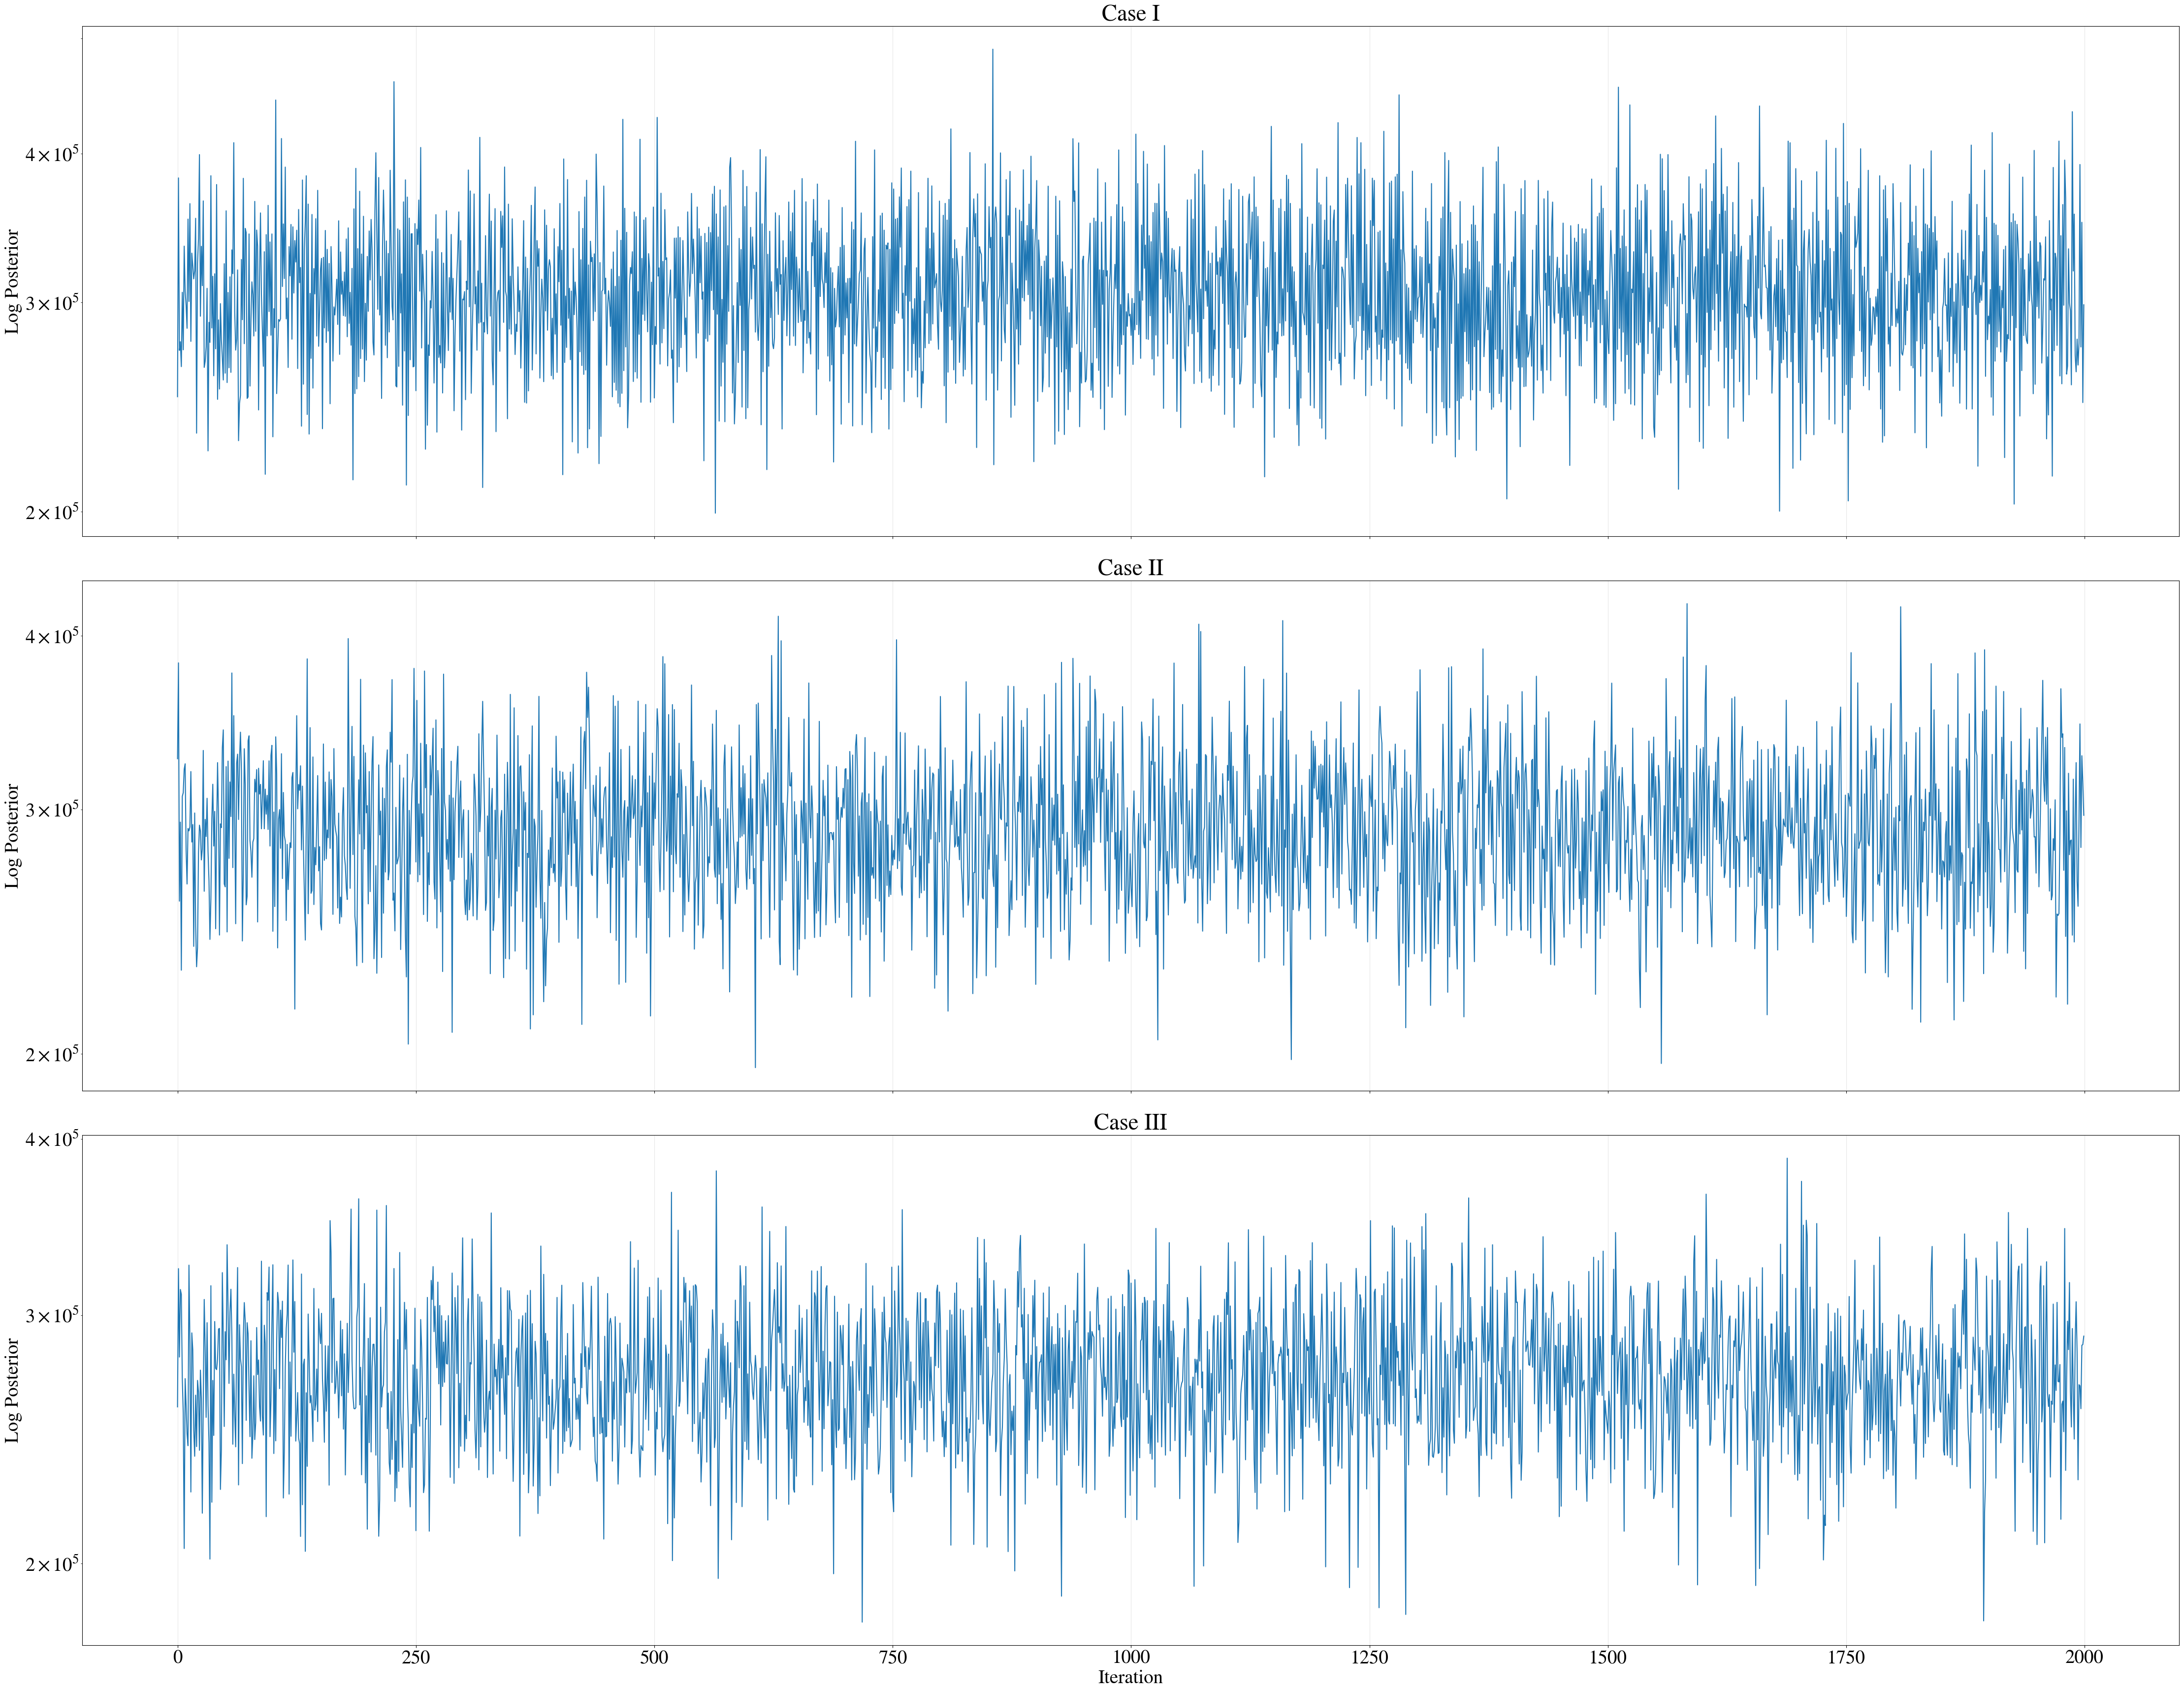

In [27]:
ln_1 = np.load(result_dir + run_version_arr[0] + '/ln-post.npy')[:2000]
ln_2 = np.load(result_dir + run_version_arr[1] + '/ln-post.npy')[:2000]
ln_3 = np.load(result_dir + run_version_arr[2] + '/ln-post.npy')[:2000]

data   = [ln_1, ln_2, ln_3]
labels = ['Case I', 'Case II', 'Case III']

fig, axes = plt.subplots(3, 1, figsize=(45, 35), sharex=True)

for ax, ln, label in zip(axes, data, labels):
    ax.semilogy(-1 * ln)
    ax.set_ylabel("Log Posterior")
    ax.set_title(label)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Iteration")
fig.tight_layout()
plt.show()

# Time elapsed

In [28]:
elapsed = time.time() - _notebook_start
hours, rem = divmod(elapsed, 3600)
mins, secs = divmod(rem, 60)
print(f"Total notebook runtime: {int(hours):02d}h {int(mins):02d}m {secs:.1f}s")

Total notebook runtime: 00h 08m 49.4s
